# Benchmark MLP — Spectrum-macro ROC-AUC por especie

## Objetivo

Reproducir la métrica del paper:

**Spectrum-macro ROC-AUC (per-patient AUC)**

## Idea de la métrica

No calculamos un único ROC-AUC global mezclando todos los antibióticos y todos los pacientes.

En su lugar:

1. Para cada paciente, recogemos todos los antibióticos disponibles para esa especie.
2. Para ese paciente tenemos:
   - un vector de etiquetas reales `y_true` (0 = sensible, 1 = resistente),
   - un vector de probabilidades predichas `y_prob`.
3. Con esos dos vectores calculamos un **ROC-AUC individual del paciente**.
4. Repetimos esto para todos los pacientes válidos.
5. Finalmente hacemos la media de los AUCs individuales.


## ¿Cuándo un paciente es válido para ROC-AUC?

Para que `roc_auc_score` pueda calcularse, en ese paciente debe haber al menos:

- un antibiótico con label `0`
- y un antibiótico con label `1`

Si todos los antibióticos de ese paciente son solo `0`, o todos son solo `1`, ese paciente se **omite**, porque ROC-AUC no está definido.


## Fórmula conceptual

Si un paciente \(i\) tiene:

- etiquetas reales: $(y_i = (y_{i1}, y_{i2}, ..., y_{im}))$
- probabilidades predichas: $(\hat p_i = (\hat p_{i1}, \hat p_{i2}, ..., \hat p_{im}))$

entonces calculamos:

$$
AUC_i = ROC\text{-}AUC(y_i, \hat p_i)
$$

y el spectrum-macro AUC final es:

$$
\text{SpectrumMacroAUC} = \frac{1}{N_{\text{válidos}}} \sum_{i \in \text{pacientes válidos}} AUC_i
$$


## Qué vamos a comparar

Compararemos tres enfoques:

- **Binary models**
- **Multilabel models**
- **LPS models**

y obtendremos el spectrum-macro ROC-AUC por especie.

## Imports and configuration

In [1]:
import json
import pickle
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

## Configuración de rutas

Aquí definimos:

- las carpetas con los resultados de los runs del benchmark,
- el fichero pickle con los datos completos,
- y los parámetros del split reproducible para LPS.

In [2]:
BASE_DIR = Path("/export/usuarios01/egarroyo/MALDI_for_AMR_prediction/src/benchmark study/benchmark_full/benchmark_outputs")

RUN_DIRS = [
    BASE_DIR / "benchmark_mlp_20260314_200946",
    BASE_DIR / "benchmark_mlp_20260316_112641",
]

PICKLE_PATH = Path("/export/usuarios01/egarroyo/MALDI_for_AMR_prediction/data/COMBINED_MARISMA_DRIAMS.pkl")

TEST_SIZE = 0.2
SEED = 42
MIN_PATTERN_COUNT = 10

print("Runs detectados:")
for run_dir in RUN_DIRS:
    print("-", run_dir)

print("\nPickle:")
print("-", PICKLE_PATH)

Runs detectados:
- /export/usuarios01/egarroyo/MALDI_for_AMR_prediction/src/benchmark study/benchmark_full/benchmark_outputs/benchmark_mlp_20260314_200946
- /export/usuarios01/egarroyo/MALDI_for_AMR_prediction/src/benchmark study/benchmark_full/benchmark_outputs/benchmark_mlp_20260316_112641

Pickle:
- /export/usuarios01/egarroyo/MALDI_for_AMR_prediction/data/COMBINED_MARISMA_DRIAMS.pkl


## Funciones generales para spectrum-macro ROC-AUC

Estas funciones son la parte central del análisis.

### Paso 1: construir la matriz paciente × antibiótico

A partir de un DataFrame en formato largo con columnas:

- `species`
- `sample_id`
- `antibiotic`
- `y_true`
- `y_prob`

construimos dos matrices:

- `y_true_mat`: filas = pacientes, columnas = antibióticos
- `y_prob_mat`: filas = pacientes, columnas = antibióticos

### Paso 2: calcular AUC por paciente

Para cada fila (paciente):

1. tomamos sus labels reales y sus probabilidades;
2. quitamos posiciones con `NaN`;
3. comprobamos si hay al menos dos clases distintas;
4. calculamos `roc_auc_score`;
5. guardamos ese AUC.

Finalmente hacemos la media.

Esto es exactamente lo que significa **per-patient AUC**.

In [3]:
def build_patient_matrix(df: pd.DataFrame):
    """
    Convierte un DataFrame largo en dos matrices:
    - y_true_mat: índice = (species, sample_id), columnas = antibiotic
    - y_prob_mat: índice = (species, sample_id), columnas = antibiotic
    """
    y_true_mat = df.pivot_table(
        index=["species", "sample_id"],
        columns="antibiotic",
        values="y_true",
        aggfunc="first"
    )

    y_prob_mat = df.pivot_table(
        index=["species", "sample_id"],
        columns="antibiotic",
        values="y_prob",
        aggfunc="first"
    )

    return y_true_mat, y_prob_mat


def spectrum_macro_from_matrix(y_true_mat: pd.DataFrame, y_prob_mat: pd.DataFrame, verbose: bool = False):
    """
    Calcula spectrum-macro ROC-AUC:
    - AUC individual por paciente
    - media de esos AUCs
    """
    aucs = []
    skipped = 0

    for i in range(len(y_true_mat)):
        y_true = y_true_mat.iloc[i].to_numpy(dtype=float)
        y_prob = y_prob_mat.iloc[i].to_numpy(dtype=float)

        mask = ~np.isnan(y_true) & ~np.isnan(y_prob)
        y_true = y_true[mask]
        y_prob = y_prob[mask]

        # ROC-AUC solo existe si hay al menos una clase 0 y una clase 1
        if len(np.unique(y_true)) < 2:
            skipped += 1
            continue

        aucs.append(roc_auc_score(y_true, y_prob))

    mean_auc = np.mean(aucs) if len(aucs) > 0 else np.nan

    if verbose:
        print(f"Pacientes válidos: {len(aucs)}")
        print(f"Pacientes omitidos: {skipped}")
        print(f"Spectrum-macro ROC-AUC: {mean_auc:.6f}" if not np.isnan(mean_auc) else "Spectrum-macro ROC-AUC: NaN")

    return mean_auc


def spectrum_macro_auc(Y_true: np.ndarray, Y_prob: np.ndarray, verbose: bool = False):
    """
    Misma idea que spectrum_macro_from_matrix, pero partiendo directamente
    de arrays (n_samples, n_antibiotics).
    """
    aucs = []
    skipped = 0

    for i in range(len(Y_true)):
        y_t = np.asarray(Y_true[i], dtype=float)
        y_p = np.asarray(Y_prob[i], dtype=float)

        mask = ~np.isnan(y_t) & ~np.isnan(y_p)
        y_t = y_t[mask]
        y_p = y_p[mask]

        if len(np.unique(y_t)) < 2:
            skipped += 1
            continue

        aucs.append(roc_auc_score(y_t, y_p))

    mean_auc = np.mean(aucs) if len(aucs) > 0 else np.nan

    if verbose:
        print(f"Pacientes válidos: {len(aucs)}")
        print(f"Pacientes omitidos: {skipped}")
        print(f"Spectrum-macro ROC-AUC: {mean_auc:.6f}" if not np.isnan(mean_auc) else "Spectrum-macro ROC-AUC: NaN")

    return mean_auc

## Carga de predicciones de modelos binary y multilabel

Vamos a convertir ambos tipos de resultados a un mismo formato largo:

| species | antibiotic | run | sample_id | y_true | y_prob |

Esto nos permite reutilizar exactamente la misma lógica de cálculo del AUC.

In [4]:
def load_binary_predictions(file_path: Path, species: str, antibiotic: str, run_name: str) -> pd.DataFrame:
    df = pd.read_csv(file_path).copy()
    required_cols = {"y_true", "y_prob"}

    if not required_cols.issubset(df.columns):
        raise ValueError(f"Faltan columnas en {file_path}. Se esperaban: {required_cols}")

    df["sample_id"] = np.arange(len(df))
    df["species"] = species
    df["antibiotic"] = antibiotic
    df["run"] = run_name

    return df[["species", "antibiotic", "run", "sample_id", "y_true", "y_prob"]]


def load_multilabel_predictions(file_path: Path, species: str, run_name: str) -> pd.DataFrame:
    df = pd.read_csv(file_path).copy()
    df["sample_id"] = np.arange(len(df))

    prob_cols = [c for c in df.columns if c.endswith("_prob")]
    antibiotics = [c.replace("_prob", "") for c in prob_cols]

    rows = []
    for ab in antibiotics:
        true_col = f"{ab}_true"
        prob_col = f"{ab}_prob"

        if true_col not in df.columns or prob_col not in df.columns:
            raise ValueError(f"Faltan columnas {true_col} o {prob_col} en {file_path}")

        tmp = pd.DataFrame({
            "species": species,
            "antibiotic": ab,
            "run": run_name,
            "sample_id": df["sample_id"],
            "y_true": df[true_col],
            "y_prob": df[prob_col],
        })
        rows.append(tmp)

    if not rows:
        raise ValueError(f"No se encontraron columnas *_prob en {file_path}")

    return pd.concat(rows, ignore_index=True)

## Recorremos todos los runs y reunimos todas las predicciones

En este paso:

- buscamos archivos de predicción binaria dentro de `binary_models`,
- buscamos el CSV multilabel por especie,
- y guardamos todo en dos DataFrames largos:
  - `binary_full`
  - `multi_full`

In [5]:
binary_rows = []
multi_rows = []

for run_dir in RUN_DIRS:
    if not run_dir.exists():
        print(f" No existe el run: {run_dir}")
        continue

    for species_dir in run_dir.iterdir():
        if not species_dir.is_dir():
            continue

        species = species_dir.name

        # ----- Binary -----
        binary_dir = species_dir / "binary_models"
        if binary_dir.exists():
            for file in binary_dir.glob("*_test_predictions.csv"):
                parts = file.stem.split("__")
                if len(parts) < 2:
                    print(f" Nombre inesperado en binary: {file.name}")
                    continue

                species_from_file = parts[0]
                antibiotic = parts[1]

                try:
                    df_bin = load_binary_predictions(file, species_from_file, antibiotic, run_dir.name)
                    binary_rows.append(df_bin)
                except Exception as e:
                    print(f" Error cargando binary {file}: {e}")

        # ----- Multilabel -----
        multi_file = species_dir / f"{species}__multilabel_test_predictions.csv"
        if multi_file.exists():
            try:
                df_multi = load_multilabel_predictions(multi_file, species, run_dir.name)
                multi_rows.append(df_multi)
            except Exception as e:
                print(f" Error cargando multilabel {multi_file}: {e}")

binary_full = pd.concat(binary_rows, ignore_index=True) if binary_rows else pd.DataFrame(
    columns=["species", "antibiotic", "run", "sample_id", "y_true", "y_prob"]
)

multi_full = pd.concat(multi_rows, ignore_index=True) if multi_rows else pd.DataFrame(
    columns=["species", "antibiotic", "run", "sample_id", "y_true", "y_prob"]
)

print("binary_full shape:", binary_full.shape)
print("multi_full shape:", multi_full.shape)

display(binary_full.head())
display(multi_full.head())

binary_full shape: (45423, 6)
multi_full shape: (61728, 6)


,species,antibiotic,run,sample_id,y_true,y_prob
0,Serratia_Marcescens,Ciprofloxacin,benchmark_mlp_20260314_200946,0,0,0.000000e+00
1,Serratia_Marcescens,Ciprofloxacin,benchmark_mlp_20260314_200946,1,0,0.000000e+00
2,Serratia_Marcescens,Ciprofloxacin,benchmark_mlp_20260314_200946,2,0,2.646567e-36
3,Serratia_Marcescens,Ciprofloxacin,benchmark_mlp_20260314_200946,3,0,0.000000e+00
4,Serratia_Marcescens,Ciprofloxacin,benchmark_mlp_20260314_200946,4,0,0.000000e+00


,species,antibiotic,run,sample_id,y_true,y_prob
0,Serratia_Marcescens,Amikacin,benchmark_mlp_20260314_200946,0,1,2.612541e-01
1,Serratia_Marcescens,Amikacin,benchmark_mlp_20260314_200946,1,0,8.467378e-02
2,Serratia_Marcescens,Amikacin,benchmark_mlp_20260314_200946,2,0,1.759078e-02
3,Serratia_Marcescens,Amikacin,benchmark_mlp_20260314_200946,3,0,4.281009e-04
4,Serratia_Marcescens,Amikacin,benchmark_mlp_20260314_200946,4,0,4.243078e-09


## Cálculo del spectrum-macro ROC-AUC por especie

Aquí agrupamos por especie y calculamos su métrica.

### Muy importante sobre el AUC por paciente

Dentro de una especie:

- cada fila de la matriz representa un paciente;
- cada columna representa un antibiótico;
- por cada paciente calculamos un ROC-AUC usando **sus antibióticos como puntos de evaluación**.

Es decir, si un paciente tiene por ejemplo 6 antibióticos:

- `y_true = [1, 0, 1, 0, 1, 0]`
- `y_prob = [0.91, 0.22, 0.80, 0.10, 0.73, 0.44]`

entonces el ROC-AUC de ese paciente mide si, dentro de ese paciente, el modelo da mayor score a los antibióticos realmente resistentes que a los sensibles.

Después promediamos esos AUCs entre todos los pacientes válidos de esa especie.

In [6]:
def compute_species_spectrum_auc(df_long: pd.DataFrame, auc_col_name: str) -> pd.DataFrame:
    """
    Calcula spectrum-macro ROC-AUC por especie a partir de un DataFrame largo.
    """
    results = []

    if df_long.empty:
        return pd.DataFrame(columns=["species", auc_col_name])

    for species, sub in df_long.groupby("species"):
        y_true_mat, y_prob_mat = build_patient_matrix(sub)
        auc = spectrum_macro_from_matrix(y_true_mat, y_prob_mat, verbose=False)

        results.append({
            "species": species,
            auc_col_name: auc
        })

    return pd.DataFrame(results).sort_values("species").reset_index(drop=True)


binary_species_auc = compute_species_spectrum_auc(binary_full, "spectrum_auc_binary")
multi_species_auc = compute_species_spectrum_auc(multi_full, "spectrum_auc_multi")

display(binary_species_auc)
display(multi_species_auc)

,species,spectrum_auc_binary
0,Citrobacter_Freundii,0.532407
1,Enterobacter_Cloacae,0.894152
2,Enterococcus_Faecium,0.997182
3,Escherichia_Coli,0.812426
4,Klebsiella_Oxytoca,0.730769
5,Klebsiella_Pneumoniae,0.876126
6,Klebsiella_Variicola,NaN
7,Morganella_Morganii,0.860269
8,Proteus_Mirabilis,0.591389
9,Pseudomonas_Aeruginosa,0.658485


,species,spectrum_auc_multi
0,Citrobacter_Freundii,0.908951
1,Citrobacter_Koseri,NaN
2,Enterobacter_Cloacae,0.953729
3,Enterococcus_Faecium,1.000000
4,Escherichia_Coli,0.908987
5,Klebsiella_Oxytoca,0.951923
6,Klebsiella_Pneumoniae,0.973172
7,Klebsiella_Variicola,0.000000
8,Morganella_Morganii,0.980471
9,Proteus_Mirabilis,0.966311


In [7]:
comparison = pd.merge(
    binary_species_auc,
    multi_species_auc,
    on="species",
    how="outer"
)

comparison["diff"] = comparison["spectrum_auc_multi"] - comparison["spectrum_auc_binary"]
comparison = comparison.sort_values("diff", ascending=False).reset_index(drop=True)

display(comparison)

,species,spectrum_auc_binary,spectrum_auc_multi,diff
0,Citrobacter_Freundii,0.532407,0.908951,0.376543
1,Proteus_Mirabilis,0.591389,0.966311,0.374922
2,Klebsiella_Oxytoca,0.730769,0.951923,0.221154
3,Pseudomonas_Aeruginosa,0.658485,0.801412,0.142927
4,Morganella_Morganii,0.860269,0.980471,0.120202
5,Klebsiella_Pneumoniae,0.876126,0.973172,0.097046
6,Escherichia_Coli,0.812426,0.908987,0.096561
7,Serratia_Marcescens,0.906250,0.971429,0.065179
8,Staphylococcus_Aureus,0.896183,0.958453,0.062269
9,Enterobacter_Cloacae,0.894152,0.953729,0.059577


# LPS — Cálculo del spectrum-macro ROC-AUC por especie

## Qué hace el modelo LPS

El modelo LPS no predice directamente una probabilidad por antibiótico.

En su lugar, predice una **clase de patrón** de resistencia.

Cada clase corresponde a un patrón binario, por ejemplo:

- patrón `10110`

eso significa algo como:

- antibiótico 1: resistente
- antibiótico 2: sensible
- antibiótico 3: resistente
- antibiótico 4: resistente
- antibiótico 5: sensible


## Cómo pasamos de probabilidad de patrón a probabilidad por antibiótico

Si el modelo devuelve:

$$
P(c \mid x)
$$

para cada clase/patrón \(c\), entonces la probabilidad marginal de resistencia en el antibiótico \(j\) es:

$$
P(\text{resistencia en antibiótico } j \mid x)
=
\sum_c P(c \mid x)\,\mathbf{1}[\text{patrón}_c[j]=1]
$$

### Interpretación

- miramos todas las clases posibles;
- si una clase tiene resistencia en el antibiótico \(j\), sumamos su probabilidad;
- así obtenemos una probabilidad final por antibiótico para cada paciente.

Después ya podemos calcular el AUC por paciente exactamente igual que antes.

In [8]:
with open(PICKLE_PATH, "rb") as f:
    payload = pickle.load(f)

X_all = payload["data"]
y_species_all = payload["label"]
amr_all = payload["amr"]
antibiotics_all = list(payload["antibiotics"])

print("X shape:", X_all.shape)
print("AMR shape:", amr_all.shape)
print("Número global de antibióticos:", len(antibiotics_all))
print("Ejemplo antibióticos:", antibiotics_all[:10])

X shape: (66832, 6000)
AMR shape: (66832, 104)
Número global de antibióticos: 104
Ejemplo antibióticos: ['5-Fluorocytosine', 'Amikacin', 'Amoxicillin', 'Amoxicillin-Clavulanic acid', 'Amoxicillin-Clavulanic acid_uncomplicated_HWI', 'Amphotericin B', 'Ampicillin', 'Ampicillin-Sulbactam', 'Anidulafungin', 'Azithromycin']


## Arquitectura del modelo

Reconstruimos la MLP a partir del checkpoint guardado.

In [9]:
def activation_from_name(name: str):
    name = str(name).lower()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "tanh":
        return nn.Tanh()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name in {"identity", "none", "linear"}:
        return nn.Identity()
    raise ValueError(f"Activación no reconocida: {name}")


class PaperMLP(nn.Module):
    def __init__(self, input_dim, output_dim, layer1, layer2, layer3, activation):
        super().__init__()

        act1 = activation_from_name(activation)
        act2 = activation_from_name(activation)
        act3 = activation_from_name(activation)

        self.net = nn.Sequential(
            nn.Linear(input_dim, layer1),
            act1,
            nn.Linear(layer1, layer2),
            act2,
            nn.Linear(layer2, layer3),
            act3,
            nn.Linear(layer3, output_dim),
        )

    def forward(self, x):
        return self.net(x)

## Funciones auxiliares de datos para LPS

Necesitamos:

1. extraer el subset de una especie;
2. quedarnos solo con los antibióticos de esa especie;
3. convertir cada fila AMR en un string de patrón;
4. eliminar patrones raros;
5. reproducir el split estratificado.

In [10]:
def get_species_subset(species_name: str):
    mask = (y_species_all == species_name)
    X_sp = X_all[mask]
    Y_sp = amr_all[mask]
    return X_sp, Y_sp


def build_pattern_strings(Y: np.ndarray) -> np.ndarray:
    Y_clean = np.nan_to_num(Y, nan=0)
    return np.array(
        ["".join(map(str, row.astype(int).tolist())) for row in Y_clean],
        dtype=object
    )


def filter_rare_patterns(X: np.ndarray, Y: np.ndarray, min_count: int = 10):
    patterns = build_pattern_strings(Y)
    counts = Counter(patterns)
    keep_mask = np.array([counts[p] >= min_count for p in patterns], dtype=bool)

    X_f = X[keep_mask]
    Y_f = Y[keep_mask]
    patterns_f = patterns[keep_mask]

    return X_f, Y_f, patterns_f


def stratified_train_test_by_patterns(X, Y, patterns, test_size=0.2, seed=42):
    idx = np.arange(len(X))
    train_idx, test_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=seed,
        stratify=patterns
    )
    return train_idx, test_idx


def load_species_summary(base_run: Path, species: str):
    summary_path = base_run / species / f"{species}__species_summary.json"
    with open(summary_path) as f:
        return json.load(f)


def load_patterns_from_csv(base_run: Path, species: str, n_classes: int):
    csv_path = base_run / species / f"{species}__pattern_counts_after_filter.csv"
    df = pd.read_csv(csv_path, dtype={"pattern": str})

    if "pattern" not in df.columns or "count" not in df.columns:
        raise ValueError(f"El CSV {csv_path} debe contener columnas 'pattern' y 'count'")

    df = df.sort_values("count", ascending=False).reset_index(drop=True)
    selected_patterns = df["pattern"].values[:n_classes]

    if len(selected_patterns) != n_classes:
        raise ValueError(
            f"No hay suficientes patrones en {csv_path}: "
            f"se necesitan {n_classes} y solo hay {len(selected_patterns)}"
        )

    return {i: p for i, p in enumerate(selected_patterns)}

## Reconstrucción robusta del modelo desde el checkpoint

Intentamos recuperar:

- `state_dict`
- activación
- dimensiones ocultas
- número de clases de salida

In [11]:
def infer_dims_from_state_dict(state_dict):
    w0 = state_dict["net.0.weight"]
    w2 = state_dict["net.2.weight"]
    w4 = state_dict["net.4.weight"]
    w6 = state_dict["net.6.weight"]

    input_dim = w0.shape[1]
    layer1 = w0.shape[0]
    layer2 = w2.shape[0]
    layer3 = w4.shape[0]
    output_dim = w6.shape[0]

    return input_dim, output_dim, layer1, layer2, layer3


def extract_activation_from_checkpoint(ckpt):
    candidate_paths = [
        ["activation"],
        ["model_args", "activation"],
        ["config", "activation"],
        ["hparams", "activation"],
        ["hyperparameters", "activation"],
        ["model_config", "activation"],
    ]

    for path in candidate_paths:
        obj = ckpt
        found = True
        for key in path:
            if isinstance(obj, dict) and key in obj:
                obj = obj[key]
            else:
                found = False
                break
        if found:
            return obj

    return "relu"


def load_lps_model(model_path: Path):
    ckpt = torch.load(model_path, map_location="cpu")

    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
        activation = extract_activation_from_checkpoint(ckpt)
    elif isinstance(ckpt, dict) and all(k.startswith("net.") for k in ckpt.keys()):
        state_dict = ckpt
        activation = "relu"
    else:
        raise ValueError(f"No se pudo interpretar el checkpoint: {model_path}")

    input_dim, output_dim, layer1, layer2, layer3 = infer_dims_from_state_dict(state_dict)

    model = PaperMLP(
        input_dim=input_dim,
        output_dim=output_dim,
        layer1=layer1,
        layer2=layer2,
        layer3=layer3,
        activation=activation,
    )

    model.load_state_dict(state_dict)
    model.eval()

    return model

## Predicción del modelo LPS

El modelo devuelve logits de clase. Aplicamos `softmax` para obtener probabilidades de patrón.

In [12]:
def predict_lps_pattern_probs(model: nn.Module, X: np.ndarray, batch_size: int = 512):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    all_probs = []

    with torch.no_grad():
        for start in range(0, len(X_tensor), batch_size):
            xb = X_tensor[start:start + batch_size]
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    return np.vstack(all_probs)

## Convertir probabilidades de clase en probabilidades por antibiótico

Si una clase tiene alta probabilidad y en su patrón el antibiótico `j` está marcado como resistente (`1`), entonces esa clase contribuye a la probabilidad final de resistencia de ese antibiótico.

Así obtenemos una matriz:

- filas = pacientes
- columnas = antibióticos
- valores = probabilidad predicha de resistencia

In [13]:
def class_probs_to_antibiotic_probs(class_probs: np.ndarray, class_to_pattern: dict):
    """
    Parameters
    ----------
    class_probs : array shape (n_samples, n_classes)
    class_to_pattern : dict {class_id: pattern_string}

    Returns
    -------
    array shape (n_samples, n_antibiotics)
    """
    n_samples, n_classes = class_probs.shape

    if n_classes == 0:
        raise ValueError("class_probs no tiene clases")

    if 0 not in class_to_pattern:
        raise ValueError("class_to_pattern debe contener la clase 0")

    n_antibiotics = len(class_to_pattern[0])
    Y_prob_ab = np.zeros((n_samples, n_antibiotics), dtype=float)

    for c in range(n_classes):
        pattern = class_to_pattern[c]
        bits = np.array(list(pattern), dtype=int)
        Y_prob_ab += class_probs[:, [c]] * bits[None, :]

    return Y_prob_ab

## Función principal para calcular el AUC LPS por especie

Flujo:

1. cargar el summary de la especie;
2. extraer sus muestras del pickle;
3. seleccionar los antibióticos correctos;
4. filtrar patrones raros;
5. reproducir el split estratificado;
6. cargar el modelo LPS;
7. predecir probabilidades de clase;
8. convertirlas en probabilidades por antibiótico;
9. calcular el spectrum-macro ROC-AUC.

In [14]:
def compute_lps_auc_for_species(base_run: Path, species: str, verbose: bool = True):
    species_dir = base_run / species

    # 1) Summary
    summary = load_species_summary(base_run, species)
    antibiotics_species = summary["antibiotics"]

    # 2) Subset por especie
    X_sp, Y_sp = get_species_subset(species)

    # 3) Seleccionar antibióticos de la especie
    ab_idx = [antibiotics_all.index(ab) for ab in antibiotics_species]
    Y_sp = Y_sp[:, ab_idx]

    # 4) Filtrar patrones raros
    X_sp, Y_sp, patterns = filter_rare_patterns(X_sp, Y_sp, min_count=MIN_PATTERN_COUNT)

    # Control defensivo
    if len(X_sp) == 0:
        raise ValueError(f"No quedan muestras tras filtrar patrones raros para {species}")

    # 5) Split reproducible
    train_idx, test_idx = stratified_train_test_by_patterns(
        X_sp, Y_sp, patterns,
        test_size=TEST_SIZE,
        seed=SEED
    )

    X_train, X_test = X_sp[train_idx], X_sp[test_idx]
    Y_train, Y_test = Y_sp[train_idx], Y_sp[test_idx]

    # 6) Cargar modelo
    model_path = species_dir / f"{species}__lps_model.pt"
    model = load_lps_model(model_path)

    n_classes = model.net[-1].out_features

    # 7) Cargar patrón de clases
    class_to_pattern = load_patterns_from_csv(base_run, species, n_classes)

    # 8) Predicción de probabilidades de clase
    class_probs = predict_lps_pattern_probs(model, X_test)

    if class_probs.shape[1] != len(class_to_pattern):
        raise ValueError(
            f"Mismatch en {species}: "
            f"{class_probs.shape[1]} clases predichas vs {len(class_to_pattern)} patrones"
        )

    # 9) Probabilidades por antibiótico
    Y_prob_ab = class_probs_to_antibiotic_probs(class_probs, class_to_pattern)

    if Y_prob_ab.shape != Y_test.shape:
        raise ValueError(
            f"Shape mismatch en {species}: "
            f"Y_prob_ab {Y_prob_ab.shape} vs Y_test {Y_test.shape}"
        )

    # 10) Spectrum AUC
    auc = spectrum_macro_auc(Y_test, Y_prob_ab, verbose=False)

    if verbose:
        print(f"{species}: AUC={auc:.6f}" if not np.isnan(auc) else f"{species}: AUC=NaN")

    return {
        "species": species,
        "run": base_run.name,
        "spectrum_auc_lps": auc,
        "n_test": len(X_test),
        "n_antibiotics": Y_test.shape[1],
    }

In [15]:
lps_results = []

for base_run in RUN_DIRS:
    if not base_run.exists():
        print(f" No existe el run: {base_run}")
        continue

    print(f"\n===== RUN: {base_run.name} =====")

    for species_dir in tqdm(list(base_run.iterdir()), desc=base_run.name):
        if not species_dir.is_dir():
            continue

        species = species_dir.name
        model_path = species_dir / f"{species}__lps_model.pt"
        summary_path = species_dir / f"{species}__species_summary.json"

        if not model_path.exists() or not summary_path.exists():
            continue

        try:
            res = compute_lps_auc_for_species(base_run, species, verbose=False)
            lps_results.append(res)
        except Exception as e:
            print(f" Error en {species} ({base_run.name}): {e}")

df_lps = pd.DataFrame(lps_results)

if not df_lps.empty:
    df_lps = df_lps.sort_values(["run", "spectrum_auc_lps"], ascending=[True, False]).reset_index(drop=True)

display(df_lps)


===== RUN: benchmark_mlp_20260314_200946 =====


benchmark_mlp_20260314_200946: 100%|██████████| 20/20 [00:02<00:00,  7.98it/s]



===== RUN: benchmark_mlp_20260316_112641 =====


benchmark_mlp_20260316_112641: 100%|██████████| 10/10 [00:14<00:00,  1.46s/it]


,species,run,spectrum_auc_lps,n_test,n_antibiotics
0,Morganella_Morganii,benchmark_mlp_20260314_200946,0.916355,151,7
1,Klebsiella_Oxytoca,benchmark_mlp_20260314_200946,0.857887,238,9
2,Enterobacter_Cloacae,benchmark_mlp_20260314_200946,0.850912,299,12
3,Klebsiella_Variicola,benchmark_mlp_20260314_200946,0.766667,129,8
4,Serratia_Marcescens,benchmark_mlp_20260314_200946,0.708333,244,5
5,Citrobacter_Freundii,benchmark_mlp_20260314_200946,0.461806,119,10
6,Citrobacter_Koseri,benchmark_mlp_20260314_200946,NaN,165,8
7,Enterococcus_Faecium,benchmark_mlp_20260316_112641,0.999364,445,6
8,Klebsiella_Pneumoniae,benchmark_mlp_20260316_112641,0.939063,3329,20
9,Proteus_Mirabilis,benchmark_mlp_20260316_112641,0.913412,429,12


## Elegir el mejor run de LPS por especie


In [16]:
if df_lps.empty:
    df_lps_best = pd.DataFrame(columns=["species", "spectrum_auc_lps", "run"])
else:
    df_lps_best = (
        df_lps.sort_values("spectrum_auc_lps", ascending=False)
              .drop_duplicates(subset="species", keep="first")
              .reset_index(drop=True)
    )

display(df_lps_best)

,species,run,spectrum_auc_lps,n_test,n_antibiotics
0,Enterococcus_Faecium,benchmark_mlp_20260316_112641,0.999364,445,6
1,Klebsiella_Pneumoniae,benchmark_mlp_20260316_112641,0.939063,3329,20
2,Morganella_Morganii,benchmark_mlp_20260314_200946,0.916355,151,7
3,Proteus_Mirabilis,benchmark_mlp_20260316_112641,0.913412,429,12
4,Staphylococcus_Epidermidis,benchmark_mlp_20260316_112641,0.900204,1020,22
5,Staphylococcus_Aureus,benchmark_mlp_20260316_112641,0.883691,1351,21
6,Escherichia_Coli,benchmark_mlp_20260316_112641,0.877750,1446,14
7,Klebsiella_Oxytoca,benchmark_mlp_20260314_200946,0.857887,238,9
8,Enterobacter_Cloacae,benchmark_mlp_20260314_200946,0.850912,299,12
9,Klebsiella_Variicola,benchmark_mlp_20260314_200946,0.766667,129,8


## Comparación final: binary vs multilabel vs LPS

Unimos todo por especie y calculamos diferencias:

- `multi_vs_binary`
- `lps_vs_binary`
- `lps_vs_multi`

In [17]:
df_all = pd.merge(
    comparison,
    df_lps_best[["species", "spectrum_auc_lps"]],
    on="species",
    how="left"
)

df_all = df_all.rename(columns={
    "spectrum_auc_binary": "auc_binary",
    "spectrum_auc_multi": "auc_multiclass",
    "spectrum_auc_lps": "auc_lps",
})

df_all["multi_vs_binary"] = df_all["auc_multiclass"] - df_all["auc_binary"]
df_all["lps_vs_binary"] = df_all["auc_lps"] - df_all["auc_binary"]
df_all["lps_vs_multi"] = df_all["auc_lps"] - df_all["auc_multiclass"]

df_all = df_all.sort_values("lps_vs_binary", ascending=False).reset_index(drop=True)

display(df_all)

,species,auc_binary,auc_multiclass,diff,auc_lps,multi_vs_binary,lps_vs_binary,lps_vs_multi
0,Proteus_Mirabilis,0.591389,0.966311,0.374922,0.913412,0.374922,0.322023,-0.052900
1,Klebsiella_Oxytoca,0.730769,0.951923,0.221154,0.857887,0.221154,0.127118,-0.094036
2,Pseudomonas_Aeruginosa,0.658485,0.801412,0.142927,0.727603,0.142927,0.069118,-0.073809
3,Escherichia_Coli,0.812426,0.908987,0.096561,0.877750,0.096561,0.065324,-0.031237
4,Klebsiella_Pneumoniae,0.876126,0.973172,0.097046,0.939063,0.097046,0.062937,-0.034109
5,Morganella_Morganii,0.860269,0.980471,0.120202,0.916355,0.120202,0.056086,-0.064116
6,Enterococcus_Faecium,0.997182,1.000000,0.002818,0.999364,0.002818,0.002182,-0.000636
7,Staphylococcus_Epidermidis,0.902006,0.958760,0.056754,0.900204,0.056754,-0.001802,-0.058556
8,Staphylococcus_Aureus,0.896183,0.958453,0.062269,0.883691,0.062269,-0.012492,-0.074761
9,Enterobacter_Cloacae,0.894152,0.953729,0.059577,0.850912,0.059577,-0.043240,-0.102817


# Family-level Analysis — Confusion matrices por familia de antibióticos

## Objetivo

Pasar de predicciones a nivel de antibiótico → a nivel de **familia de antibióticos**.

Esto nos permite responder:
 ¿El modelo acierta a nivel de clase farmacológica?



## Idea clave

Cada paciente tiene múltiples antibióticos.

Ejemplo:

| Antibiotic | True | Pred |
|----------|------|------|
| AMP      | 1    | 1    |
| AMX      | 0    | 1    |
| CIP      | 1    | 0    |

Supongamos:

- AMP, AMX → familia **Beta-lactams**
- CIP → familia **Fluoroquinolones**

Entonces agregamos:

### Regla de agregación (IMPORTANTÍSIMA)

Para cada familia:

$$
y_{\text{family}} = 1 \quad \text{si ANY antibiótico de esa familia es resistente}
$$

Esto se hace tanto para:

- `y_true`
- `y_pred`



## Resultado

Para cada familia obtenemos:

- vector binario por paciente
- matriz de confusión (TP, FP, TN, FN)

y lo visualizamos.

In [18]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
BASE_DIR = Path("/export/usuarios01/egarroyo/MALDI_for_AMR_prediction/src/benchmark study/benchmark_full/benchmark_outputs")

RUN_DIR = BASE_DIR / "benchmark_mlp_20260316_112641"

print("Run:", RUN_DIR)

Run: /export/usuarios01/egarroyo/MALDI_for_AMR_prediction/src/benchmark study/benchmark_full/benchmark_outputs/benchmark_mlp_20260316_112641


In [20]:
# ---------------------------------------------------------------------
# 1) Columns to ignore (those explicitly marked "To be discarded")
# ---------------------------------------------------------------------
to_be_ignored = [
    "Aminoglycosides",                 # class label, not an AST antibiotic result
    "Ampicillin-Amoxicillin",          # Combo:* (discard)
    "ESBL",                            # phenotype/marker, not an antibiotic
    "Fosfomycin-Trometamol",           # Combo:* (discard)
    "Quinupristin-Dalfopristin",       # Combo:* (discard)
    "Quinolones",                      # class label, not an AST antibiotic result
    "Unnamed: 0",                      # junk index column
    "Unnamed: 0.1",                    # junk index column
    'Combo:Amoxicillin-Ampicillin',    # Combo:* (discard)
    'Combo:Fosfomycin-Trometamol',     # Combo:* (discard)
    'Combo:Quinupristin-Dalfopristin', # Combo:* (discard)
    'Extended-spectrum beta-lactamase' # phenotype/marker, not an antibiotic
]


# ---------------------------------------------------------------------
# 2) Completed hierarchical organization
# ---------------------------------------------------------------------
organized_antibiotics = {

    "beta_lactams": {
        "penicillins": [
            "Amoxicillin", "Ampicillin", "Penicillin",
            "Benzylpenicillin",          # DRIAMS
            "Methicillin",               # proxy often via MRSA; keep if you want an anti-staph penicillin axis
            "Oxacillin",
            "Piperacillin", "Ticarcillin", "Mecillinam",
        ],
        "penicillins_inhibitor": [
            "Amoxicillin/Clavulanic acid",
            "Ampicillin/Sulbactam",
            "Piperacillin/Tazobactam",
            "Ticarcillin/Clavulanic acid",   # DRIAMS
        ],
        "cephalosporins": [
            "Cefalotin", "Cefazolin", "Cephalexin",
            "Cefuroxime", "Cefixime",
            "Cefpodoxime",               # DRIAMS
            "Cefoxitin",
            "Cefotaxime", "Ceftriaxone", "Ceftazidime",
            "Cefepime",
            "Ceftaroline",
            "Ceftobiprole",              # DRIAMS
            "Cefiderocol",
        ],
        "cephalosporins_inhibitor": [
            "Ceftazidime/Avibactam",
            "Ceftolozane/Tazobactam"
        ],
        "carbapenems": [
            "Imipenem", "Meropenem", "Ertapenem", "Doripenem"
        ],
        "carbapenems_inhibitor": [
            "Meropenem/Vaborbactam"
        ],
        "monobactams": [
            "Aztreonam"
        ]
    },

    "protein_synthesis_inhibitors": {
        "aminoglycosides": [
            "Amikacin", "Gentamicin",
            "Tobramycin", "Streptomycin"
        ],
        "tetracyclines": [
            "Tetracycline", "Doxycycline",
            "Minocycline", "Tigecycline"
        ],
        "macrolides": [
            "Azithromycin", "Clarithromycin", "Erythromycin"
        ],

        "ketolides": [
            "Telithromycin" # DRIAMS
        ],

        "lincosamides": [
            "Clindamycin"
        ],

        "oxazolidinones": [
            "Linezolid", "Tedizolid"
        ],

        "phenicols": [
            "Chloramphenicol"
        ],

        "fusidanes": [
            "Fusidic acid"
        ],

        "pseudomonic_acid": [
            "Mupirocin"
        ],

        "streptogramins": [
            "Pristinamycin",
        ]
    },

    "dna_rna_synthesis_inhibitors": {
        "quinolones": [
            "Ciprofloxacin", "Levofloxacin",
            "Moxifloxacin", "Norfloxacin",
            "Nalidixic acid",
            "Ofloxacin",                  # DRIAMS
            "Pefloxacin",                 # DRIAMS
            "Sparfloxacin",               # DRIAMS
        ],
        "rifamycins": [
            "Rifampicin",
        ],
        "aminocoumarins": [
            "Novobiocin",                 # DRIAMS
        ],
    },

    "folate_pathway_inhibitors": {
        "antifolates": [
            "Trimethoprim",
            "Trimethoprim/Sulfamethoxazole"
        ]
    },

    "cell_envelope_or_membrane": {
        "cell_membrane": {
            "lipopeptides": [
                "Daptomycin"
            ],
            "polymyxins": [
                "Colistin", "Polymyxin"
            ],
        },
        "cell_wall": {
            "phosphonic_acid_derivatives": [
                "Fosfomycin"
            ],
            "glycopeptides": [
                "Vancomycin", "Teicoplanin",
                "Dalbavancin", "Oritavancin"
            ],
            "polypeptides": [
                "Bacitracin",                 # DRIAMS (cell wall)
            ],
        },
    },

    "other_antibacterials": {
        "nitrofurans": [
            "Nitrofurantoin"
        ],
        "nitroimidazoles": [
            "Metronidazole"               # MARISMa + DRIAMS
        ],
        "antimycobacterial": [
            "Isoniazid", "Ethambutol", "Pyrazinamide"
        ]
    },

    "antifungals": [
        "Amphotericin", "Fluconazole", "Voriconazole",
        "Posaconazole", "Itraconazole", "Isavuconazole",
        "Caspofungin", "Micafungin", "Anidulafungin",
        "Clotrimazole",
        "Fluorocytosine",                # DRIAMS
    ]
}


# ---------------------------------------------------------------------
# 3) Mapping of raw antibiotic column names to canonical/clean names, per dataset
# ---------------------------------------------------------------------
# MARISMa
MARISMa_AMR_columns = {
    "Amikacin": "Amikacin",
    "Amoxicillin": "Amoxicillin",
    "Amoxicillin/Clavulanic acid": "Amoxicillin/Clavulanic acid",
    "Amphotericin B": "Amphotericin",
    "Ampicillin": "Ampicillin",
    "Ampicillin/Sulbactam": "Ampicillin/Sulbactam",
    "Anidulafungin": "Anidulafungin",
    "Azithromycin": "Azithromycin",
    "Aztreonam": "Aztreonam",
    "Caspofungin": "Caspofungin",
    "Cefalotin": "Cefalotin",
    "Cefazolin": "Cefazolin",
    "Cefepime": "Cefepime",
    "Cefiderocol": "Cefiderocol",
    "Cefixime": "Cefixime",
    "Cefotaxime": "Cefotaxime",
    "Cefoxitin": "Cefoxitin",
    "Ceftaroline": "Ceftaroline",
    "Ceftazidime": "Ceftazidime",
    "Ceftazidime/Avibactam": "Ceftazidime/Avibactam",
    "Ceftolozane/Tazobactam": "Ceftolozane/Tazobactam",
    "Ceftriaxone": "Ceftriaxone",
    "Cefuroxime": "Cefuroxime",
    "Cephalexin": "Cephalexin",
    "Chloramphenicol": "Chloramphenicol",
    "Ciprofloxacin": "Ciprofloxacin",
    "Clarithromycin": "Clarithromycin",
    "Clindamycin": "Clindamycin",
    "Clotrimazole": "Clotrimazole",
    "Colistin": "Colistin",
    "Dalbavancin": "Dalbavancin",
    "Daptomycin": "Daptomycin",
    "Doripenem": "Doripenem",
    "Doxycycline": "Doxycycline",
    "Ertapenem": "Ertapenem",
    "Erythromycin": "Erythromycin",
    "Ethambutol": "Ethambutol",
    "Fluconazole": "Fluconazole",
    "Fosfomycin": "Fosfomycin",
    "Fusidic acid": "Fusidic acid",
    "Gentamicin": "Gentamicin",
    "Gentamicin 500": "Gentamicin",
    "Imipenem": "Imipenem",
    "Isavuconazole": "Isavuconazole",
    "Isoniazid": "Isoniazid",
    "Itraconazole": "Itraconazole",
    "Levofloxacin": "Levofloxacin",
    "Linezolid": "Linezolid",
    "Mecillinam": "Mecillinam",
    "Meropenem": "Meropenem",
    "Meropenem/Vaborbactam": "Meropenem/Vaborbactam",
    "Metronidazole": "Metronidazole",
    "Micafungin": "Micafungin",
    "Minocycline": "Minocycline",
    "Moxifloxacin": "Moxifloxacin",
    "Mupirocin": "Mupirocin",
    "Nalidixic acid": "Nalidixic acid",
    "Nitrofurantoin": "Nitrofurantoin",
    "Norfloxacin": "Norfloxacin",
    "Oritavancin": "Oritavancin",
    "Oxacillin": "Oxacillin",
    "Penicillin": "Penicillin",
    "Piperacillin": "Piperacillin",
    "Piperacillin/Tazobactam": "Piperacillin/Tazobactam",
    "Posaconazole": "Posaconazole",
    "Pristinamycin": "Pristinamycin",
    "Pyrazinamide": "Pyrazinamide",
    "Rifampin": "Rifampicin",
    "Streptomycin": "Streptomycin",
    "Tedizolid": "Tedizolid",
    "Teicoplanin": "Teicoplanin",
    "Tetracycline": "Tetracycline",
    "Ticarcillin": "Ticarcillin",
    "Tigecycline": "Tigecycline",
    "Tobramycin": "Tobramycin",
    "Trimethoprim": "Trimethoprim",
    "Trimethoprim/Sulfamethoxazole": "Trimethoprim/Sulfamethoxazole",
    "Vancomycin": "Vancomycin",
    "Voriconazole": "Voriconazole",
}

# DRIAMS
DRIAMS_AMR_columns = {
    '5-Fluorocytosine': 'Fluorocytosine', 
    'Amikacin': 'Amikacin', 
    'Aminoglycosides': 'Aminoglycosides', # To be discarded
    'Amoxicillin': 'Amoxicillin', 
    'Amoxicillin-Clavulanic acid': 'Amoxicillin/Clavulanic acid', 
    'Amoxicillin-Clavulanic acid_uncomplicated_HWI': 'Amoxicillin/Clavulanic acid', 
    'Amphotericin B': 'Amphotericin', 
    'Ampicillin': 'Ampicillin', 
    'Ampicillin-Amoxicillin': 'Combo:Amoxicillin-Ampicillin', # To be discarded
    'Ampicillin-Sulbactam': 'Ampicillin/Sulbactam', 
    'Anidulafungin': 'Anidulafungin', 
    'Azithromycin': 'Azithromycin', 
    'Aztreonam': 'Aztreonam', 
    'Bacitracin': 'Bacitracin', 
    'Benzylpenicillin': 'Benzylpenicillin', 
    'Benzylpenicillin_others': 'Benzylpenicillin', 
    'Benzylpenicillin_with_meningitis': 'Benzylpenicillin', 
    'Benzylpenicillin_with_pneumonia': 'Benzylpenicillin', 
    'Caspofungin': 'Caspofungin', 
    'Cefalotin-Cefazolin': 'Cefazolin', 
    'Cefazolin': 'Cefazolin', 
    'Cefepime': 'Cefepime', 
    'Cefixime': 'Cefixime', 
    'Cefotaxime': 'Cefotaxime', 
    'Cefoxitin': 'Cefoxitin', 
    'Cefoxitin_screen': 'Cefoxitin', 
    'Cefpodoxime': 'Cefpodoxime', 
    'Ceftarolin': 'Ceftaroline', 
    'Ceftazidime': 'Ceftazidime', 
    'Ceftazidime-Avibactam': 'Ceftazidime/Avibactam', 
    'Ceftobiprole': 'Ceftobiprole', 
    'Ceftolozane-Tazobactam': 'Ceftolozane/Tazobactam', 
    'Ceftriaxone': 'Ceftriaxone', 
    'Cefuroxime': 'Cefuroxime', 
    'Cefuroxime.1': 'Cefuroxime', 
    'Chloramphenicol': 'Chloramphenicol', 
    'Ciprofloxacin': 'Ciprofloxacin', 
    'Clarithromycin': 'Clarithromycin', 
    'Clindamycin': 'Clindamycin', 
    'Clindamycin_induced': 'Clindamycin', 
    'Colistin': 'Colistin', 
    'Cotrimoxazol': 'Trimethoprim/Sulfamethoxazole',  # typo
    'Cotrimoxazole': 'Trimethoprim/Sulfamethoxazole', 
    'Daptomycin': 'Daptomycin', 
    'Doxycycline': 'Doxycycline', 
    'ESBL': 'Extended-spectrum beta-lactamase', # To be discarded
    'Ertapenem': 'Ertapenem', 
    'Erythromycin': 'Erythromycin', 
    'Ethambutol_5mg-l': 'Ethambutol', 
    'Fluconazole': 'Fluconazole', 
    'Fosfomycin': 'Fosfomycin', 
    'Fosfomycin-Trometamol': 'Combo:Fosfomycin-Trometamol', # To be discarded
    'Fusidic acid': 'Fusidic acid', 
    'Gentamicin': 'Gentamicin', 
    'Gentamicin_high_level': 'Gentamicin', 
    'Imipenem': 'Imipenem', 
    'Isavuconazole': 'Isavuconazole', 
    'Isoniazid_.1mg-l': 'Isoniazid', 
    'Isoniazid_.4mg-l': 'Isoniazid', 
    'Itraconazole': 'Itraconazole', 
    'Levofloxacin': 'Levofloxacin', 
    'Linezolid': 'Linezolid', 
    'MRSA': 'Methicillin', 
    'Meropenem': 'Meropenem', 
    'Meropenem-Vaborbactam': 'Meropenem/Vaborbactam', 
    'Meropenem_with_meningitis': 'Meropenem', 
    'Meropenem_with_pneumonia': 'Meropenem', 
    'Meropenem_without_meningitis': 'Meropenem', 
    'Metronidazole': 'Metronidazole', 
    'Micafungin': 'Micafungin', 
    'Minocycline': 'Minocycline', 
    'Moxifloxacin': 'Moxifloxacin', 
    'Mupirocin': 'Mupirocin', 
    'Nitrofurantoin': 'Nitrofurantoin', 
    'Norfloxacin': 'Norfloxacin', 
    'Novobiocin': 'Novobiocin', 
    'Ofloxacin': 'Ofloxacin', 
    'Oxacillin': 'Oxacillin', 
    'Pefloxacin': 'Pefloxacin', 
    'Penicillin': 'Penicillin', 
    'Penicillin_with_endokarditis': 'Penicillin', 
    'Penicillin_with_meningitis': 'Penicillin', 
    'Penicillin_with_other_infections': 'Penicillin', 
    'Penicillin_with_pneumonia': 'Penicillin', 
    'Penicillin_without_endokarditis': 'Penicillin', 
    'Penicillin_without_meningitis': 'Penicillin', 
    'Piperacillin': 'Piperacillin', 
    'Piperacillin-Tazobactam': 'Piperacillin/Tazobactam', 
    'Polymyxin B': 'Polymyxin', 
    'Posaconazole': 'Posaconazole', 
    'Pristinamycin': 'Pristinamycin', 
    'Pyrazinamide': 'Pyrazinamide', 
    'Quinolones': 'Quinolones', # To be discarded
    'Quinupristin-Dalfopristin': 'Combo:Quinupristin-Dalfopristin', 
    'Rifampicin': 'Rifampicin', 
    'Rifampicin_1mg-l': 'Rifampicin', 
    'Sparfloxacin': 'Sparfloxacin', 
    'Strepomycin_high_level': 'Streptomycin', 
    'Streptomycin': 'Streptomycin', 
    'Teicoplanin': 'Teicoplanin', 
    'Teicoplanin_GRD': 'Teicoplanin', 
    'Telithromycin': 'Telithromycin', 
    'Tetracycline': 'Tetracycline', 
    'Ticarcillin': 'Ticarcillin', 
    'Ticarcillin-Clavulan acid': 'Ticarcillin/Clavulanic acid', 
    'Tigecycline': 'Tigecycline', 
    'Tobramycin': 'Tobramycin', 
    'Unnamed: 0': None, # To be discarded
    'Unnamed: 0.1': None, # To be discarded
    'Vancomycin': 'Vancomycin', 
    'Vancomycin_GRD': 'Vancomycin', 
    'Voriconazole': 'Voriconazole', 
}


# ---------------------------------------------------------------------
# 4) Quick sanity checks: what is still unassigned?
# ---------------------------------------------------------------------
_all_canon = set(MARISMa_AMR_columns.values()) | set(DRIAMS_AMR_columns.values())
_all_canon.discard(None)
_all_canon -= set(to_be_ignored)

def flatten(d):
    out = set()
    if isinstance(d, dict):
        for v in d.values():
            out |= flatten(v)
    elif isinstance(d, list):
        for x in d:
            out |= flatten(x)
    else:
        out.add(d)
    return out

_assigned = flatten(organized_antibiotics)
unassigned_canonical = sorted(_all_canon - _assigned)
print(unassigned_canonical)

[]


### Mapping to families

In [21]:
def build_antibiotic_to_family(organized_antibiotics, ignore_list):
    mapping = {}

    def recurse(d, parent_key=None):
        if isinstance(d, dict):
            for k, v in d.items():
                recurse(v, k if parent_key is None else parent_key)
        elif isinstance(d, list):
            for ab in d:
                if ab not in ignore_list:
                    mapping[ab] = parent_key

    recurse(organized_antibiotics)
    return mapping


antibiotic_to_family = build_antibiotic_to_family(
    organized_antibiotics,
    to_be_ignored
)

print("Antibióticos mapeados:", len(antibiotic_to_family))

Antibióticos mapeados: 91


## Normalización de nombres (MUY IMPORTANTE)

Usamos:

- `MARISMa_AMR_columns`
- `DRIAMS_AMR_columns`

para convertir todo a nombres canónicos.

Ejemplo:

```python
"Rifampin" → "Rifampicin"
"MRSA" → "Methicillin"

In [22]:
def normalize_columns(df):
    """
    Normaliza nombres de antibióticos a nombres canónicos
    """
    rename_map = {}

    for col in df.columns:
        if col.endswith("_true") or col.endswith("_pred"):

            base = col.replace("_true", "").replace("_pred", "")

            if base in MARISMa_AMR_columns:
                new_base = MARISMa_AMR_columns[base]
            elif base in DRIAMS_AMR_columns:
                new_base = DRIAMS_AMR_columns[base]
            else:
                new_base = base

            if new_base is None or new_base in to_be_ignored:
                continue

            rename_map[col] = col.replace(base, new_base)

    return df.rename(columns=rename_map)

## CORE — Conversión a nivel familia

1. Inicializamos todas las familias a 0
2. Recorremos antibióticos
3. Si alguno vale 1 → familia = 1


### Ejemplo

Paciente:

- Ampicillin = 1
- Amoxicillin = 0

Familia beta_lactams → 1

In [23]:
def convert_to_family_level(df, antibiotic_to_family):
    """
    Convierte dataframe multilabel → family-level
    """

    families = sorted(set(antibiotic_to_family.values()))

    y_true_fam = {fam: [] for fam in families}
    y_pred_fam = {fam: [] for fam in families}

    for _, row in df.iterrows():

        fam_true = {fam: 0 for fam in families}
        fam_pred = {fam: 0 for fam in families}

        for col in df.columns:

            if not col.endswith("_true"):
                continue

            ab = col.replace("_true", "")

            if ab not in antibiotic_to_family:
                continue

            fam = antibiotic_to_family[ab]

            pred_col = f"{ab}_pred"
            if pred_col not in df.columns:
                continue

            if row[col] == 1:
                fam_true[fam] = 1

            if row[pred_col] == 1:
                fam_pred[fam] = 1

        for fam in families:
            y_true_fam[fam].append(fam_true[fam])
            y_pred_fam[fam].append(fam_pred[fam])

    for fam in families:
        y_true_fam[fam] = np.array(y_true_fam[fam])
        y_pred_fam[fam] = np.array(y_pred_fam[fam])

    return y_true_fam, y_pred_fam

## Carga de datos por especie

In [24]:
def load_species_data(run_dir, species):
    species_dir = run_dir / species

    summary_path = species_dir / f"{species}__species_summary.json"
    pred_path = species_dir / f"{species}__multilabel_test_predictions.csv"

    if not summary_path.exists() or not pred_path.exists():
        raise FileNotFoundError(f"Faltan archivos en {species}")

    with open(summary_path) as f:
        summary = json.load(f)

    df = pd.read_csv(pred_path)

    # normalizar nombres
    df = normalize_columns(df)

    return summary["antibiotics"], df

In [25]:
def plot_family_confusions(y_true_fam, y_pred_fam, species):

    families = list(y_true_fam.keys())

    n = len(families)
    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(5 * cols, 4 * rows))

    for i, fam in enumerate(families):

        cm = confusion_matrix(
            y_true_fam[fam],
            y_pred_fam[fam],
            labels=[0, 1]
        )

        plt.subplot(rows, cols, i + 1)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False
        )

        plt.title(f"{species}\n{fam}")
        plt.xlabel("Predicted")
        plt.ylabel("True")

    plt.tight_layout()
    plt.show()


===== Proteus_Mirabilis =====


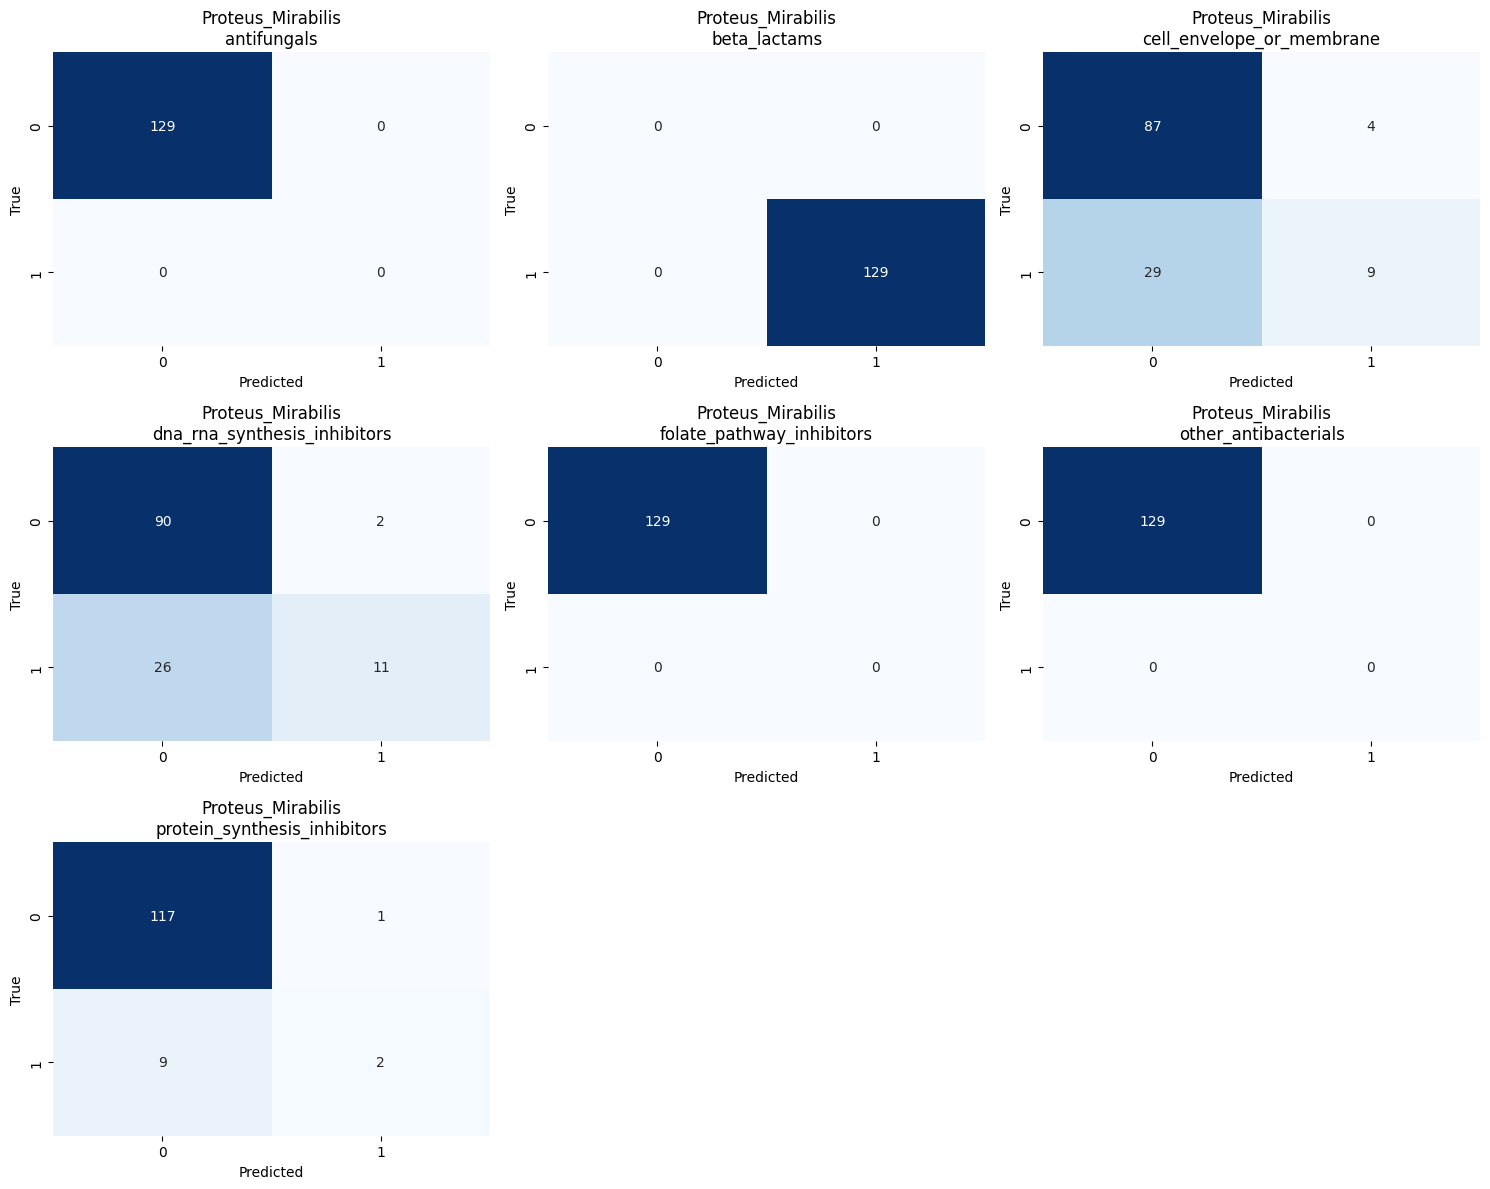


===== Escherichia_Coli =====


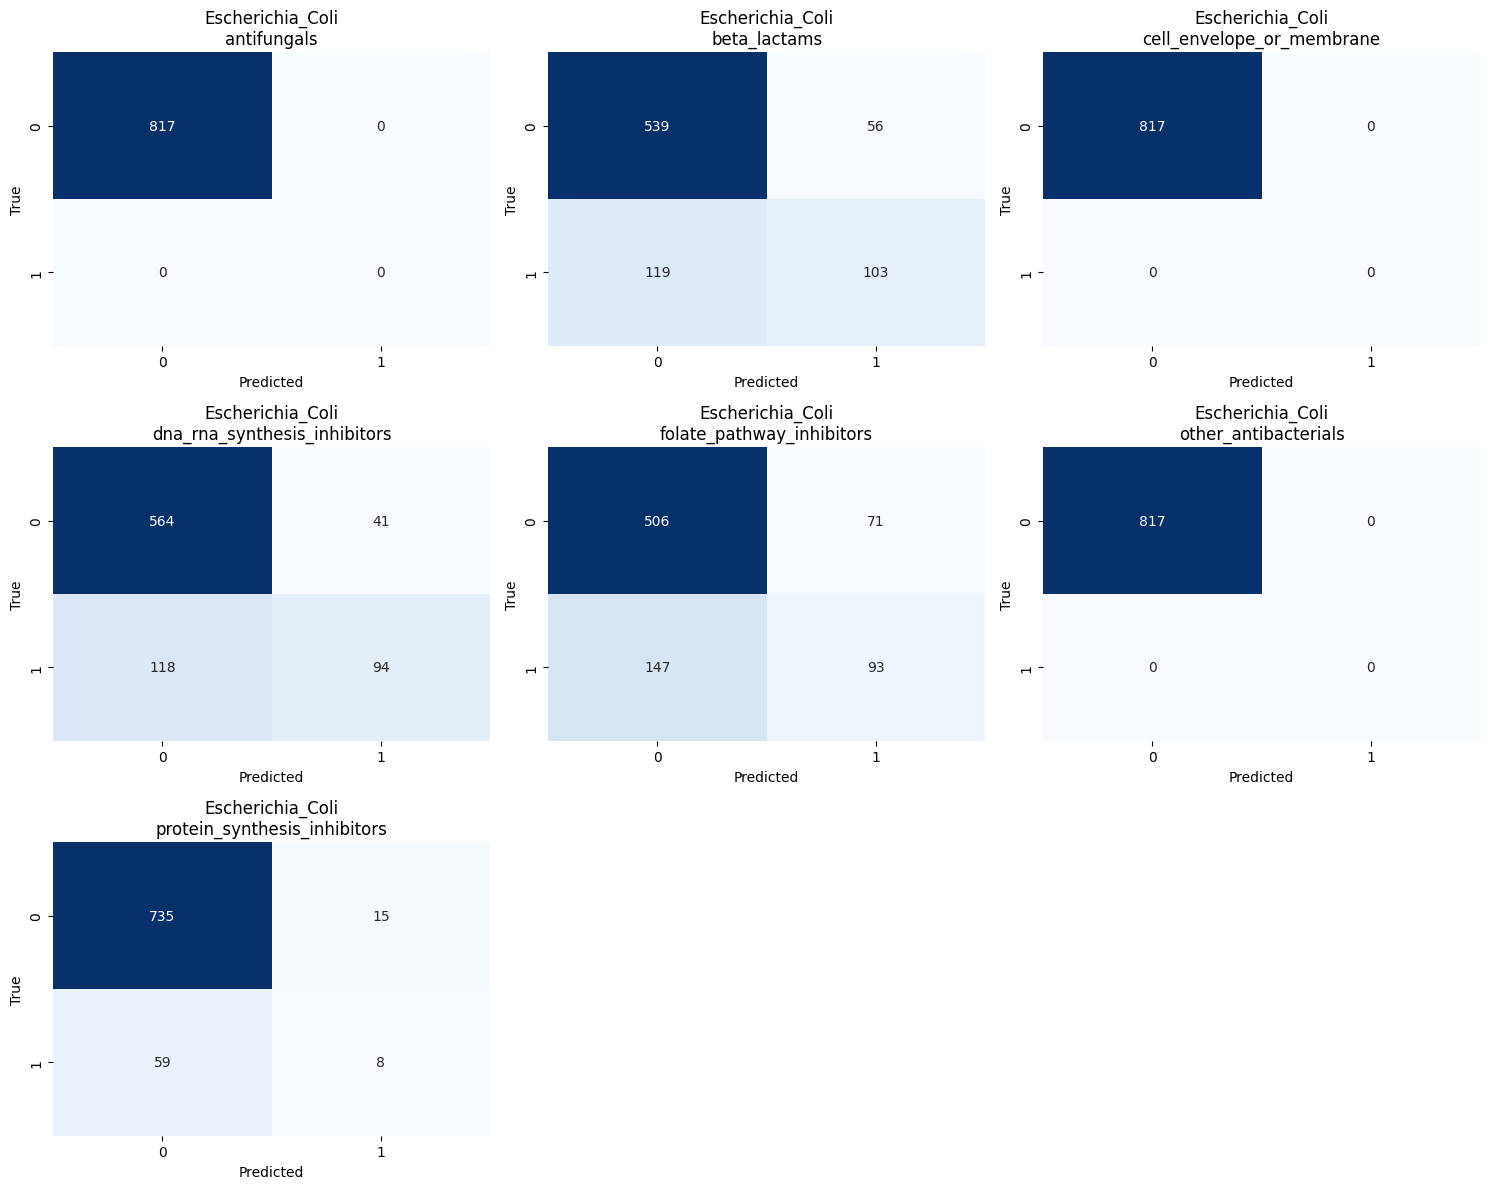


===== Klebsiella_Pneumoniae =====


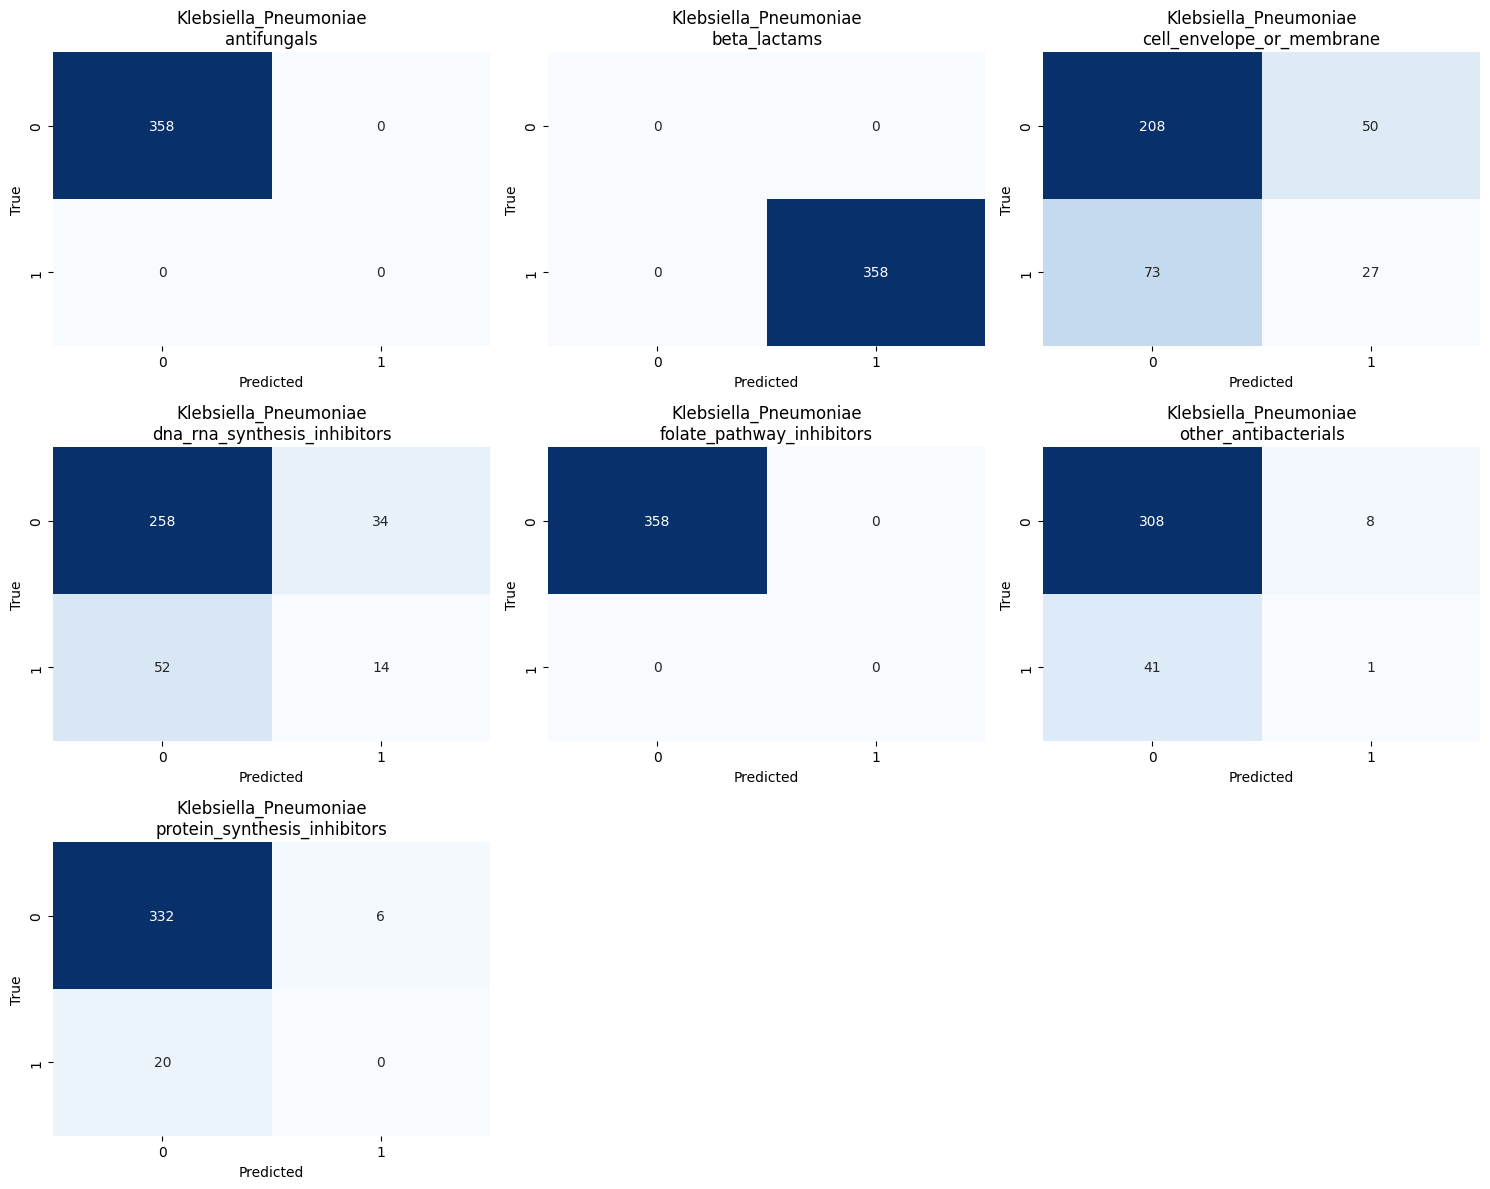


===== Staphylococcus_Epidermidis =====


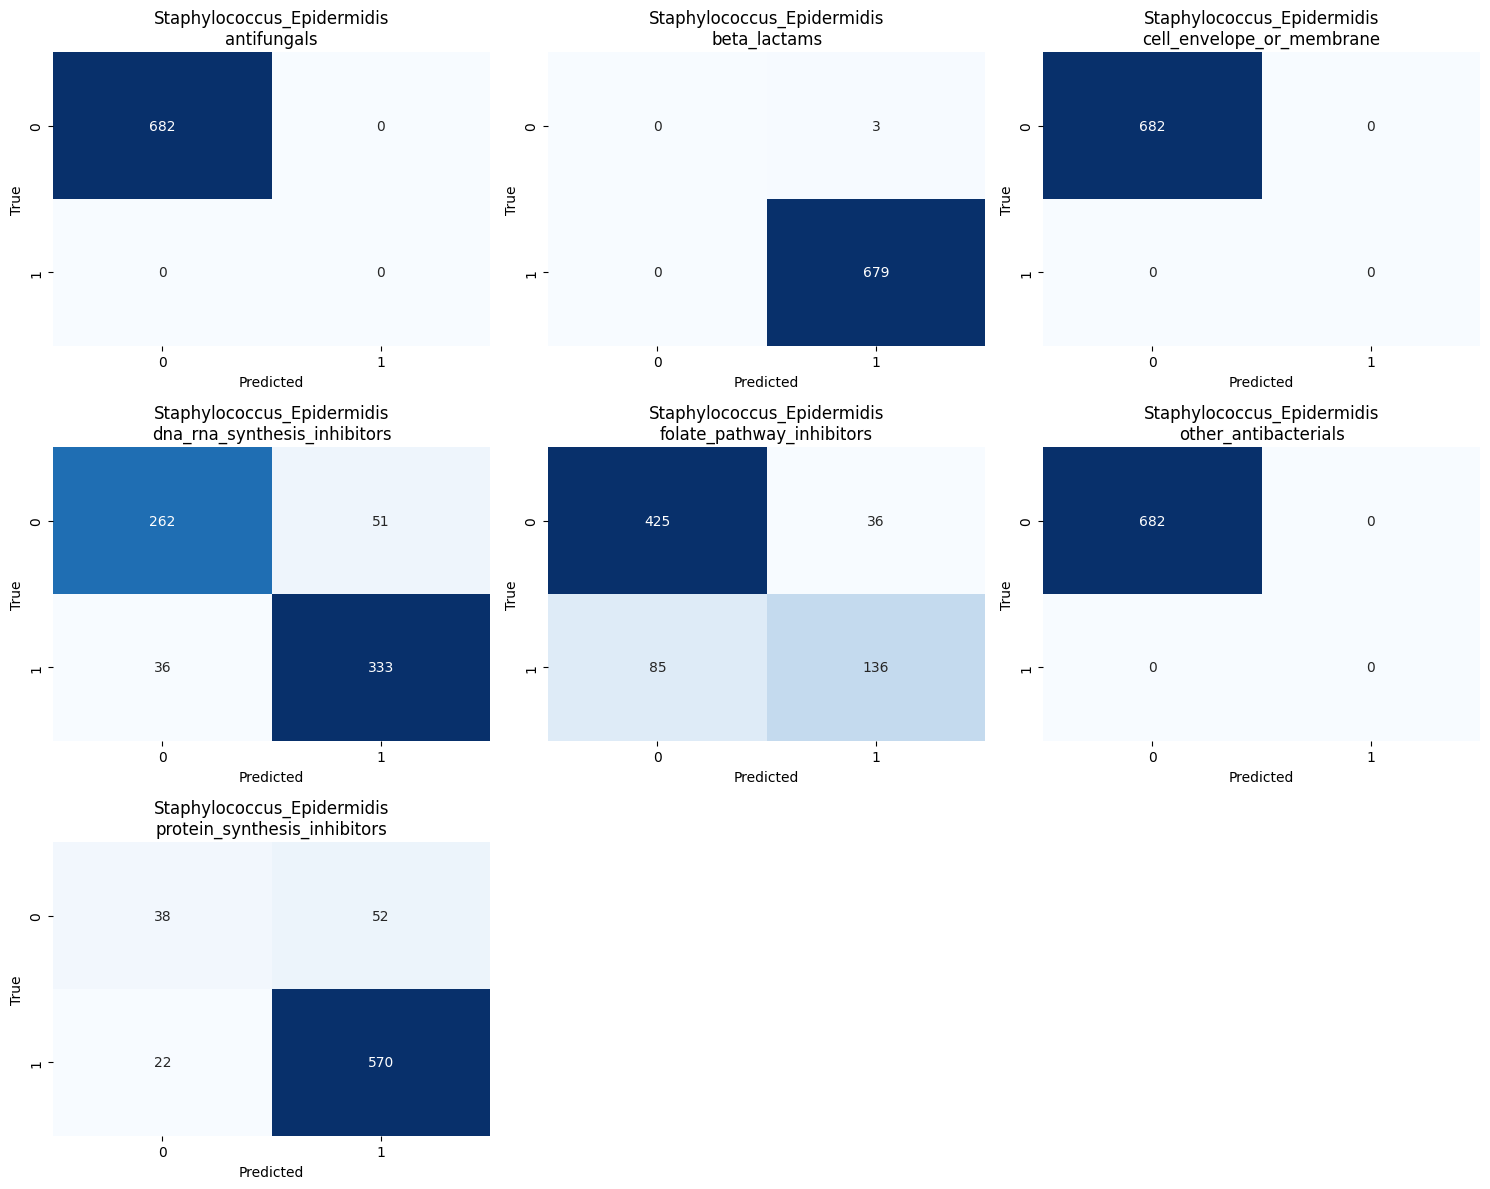


===== Enterococcus_Faecium =====


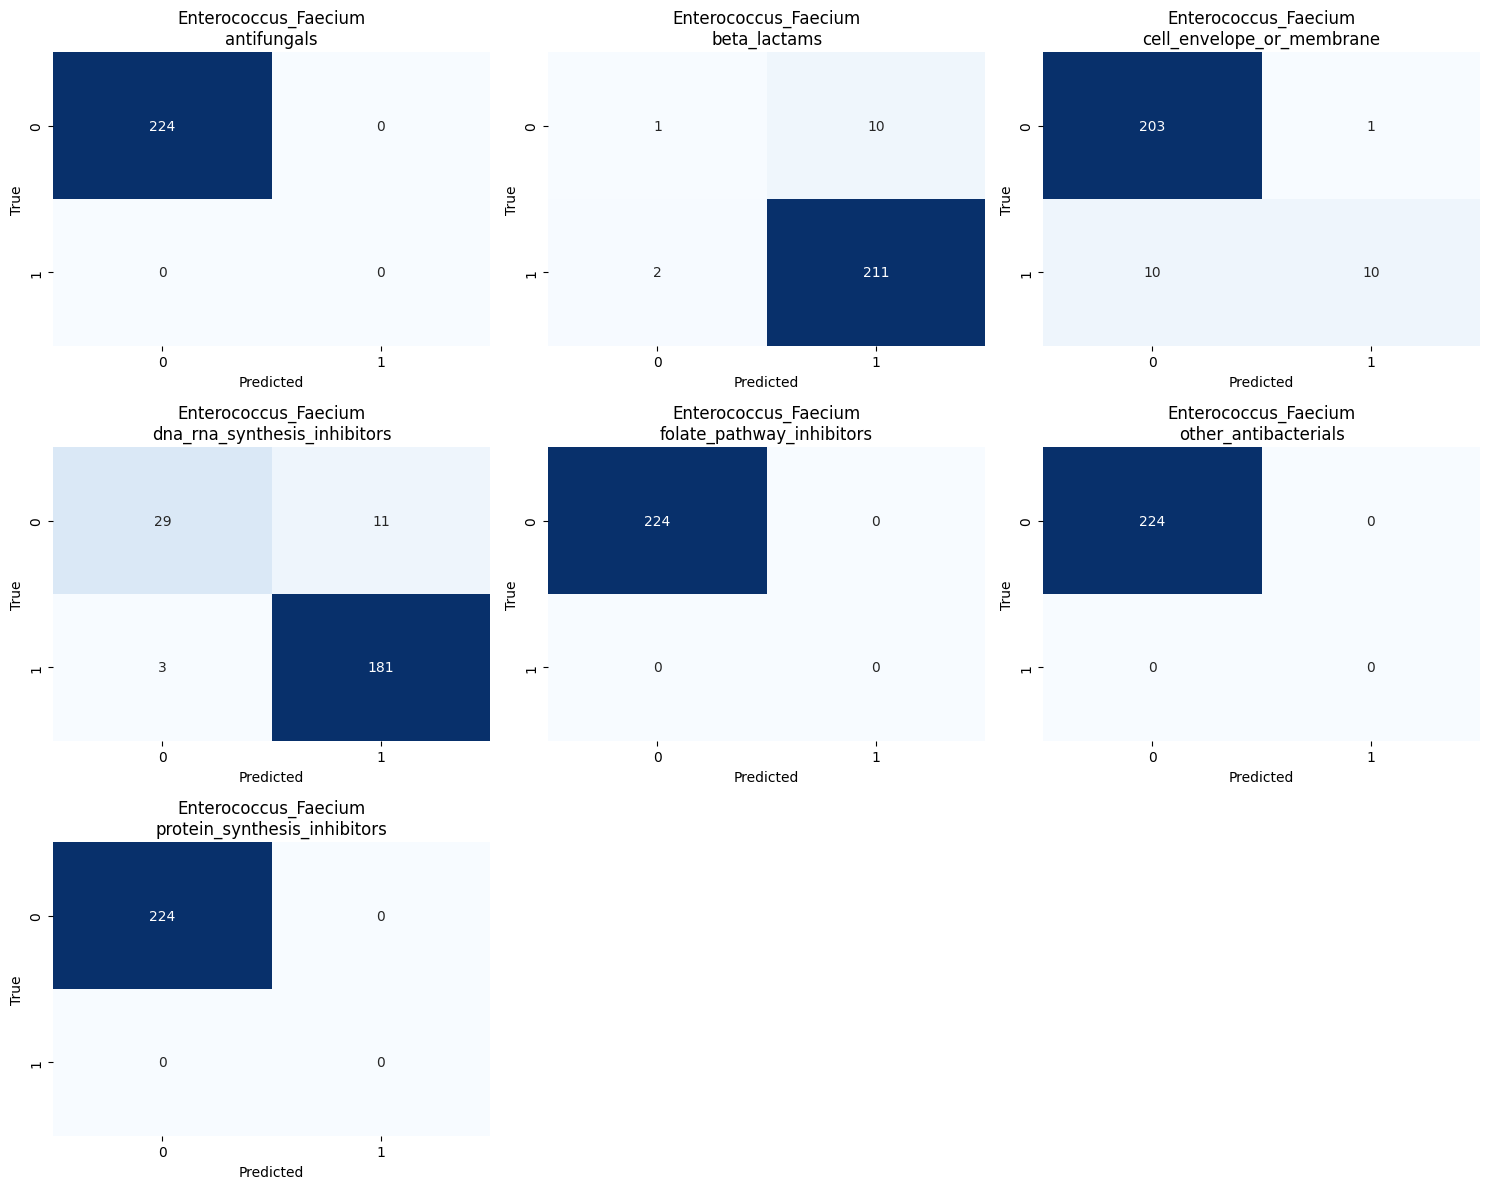


===== Pseudomonas_Aeruginosa =====


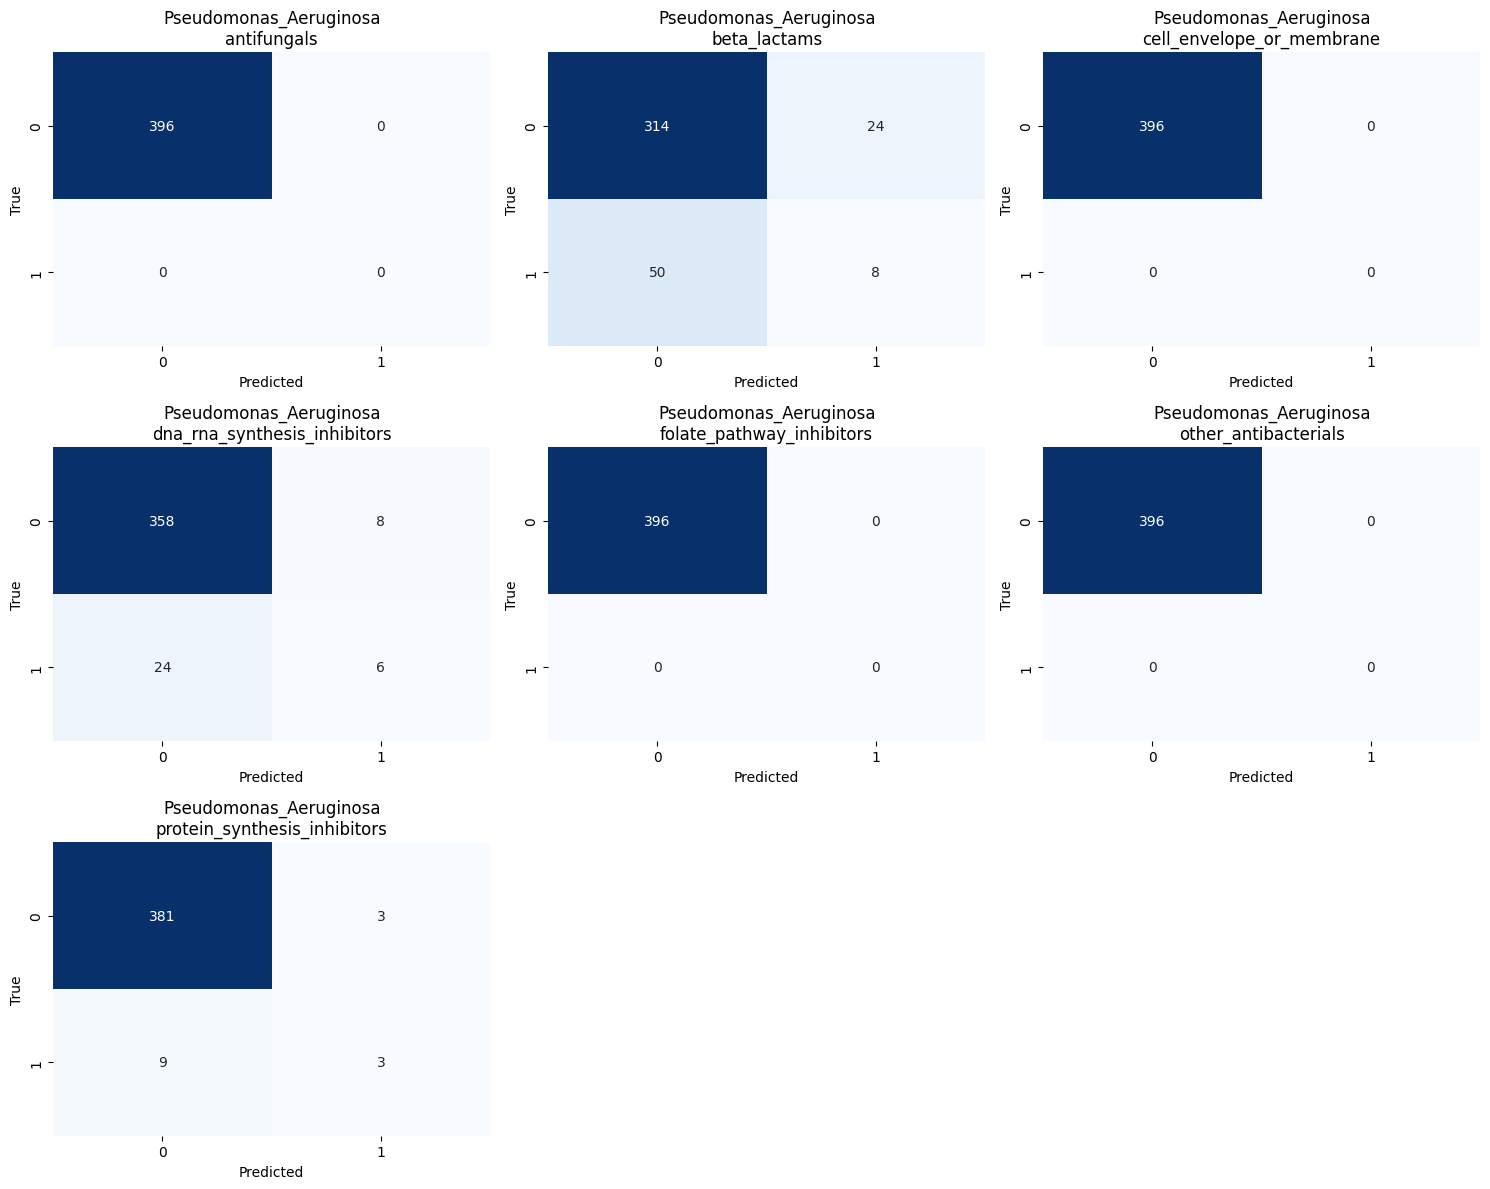


===== Staphylococcus_Aureus =====


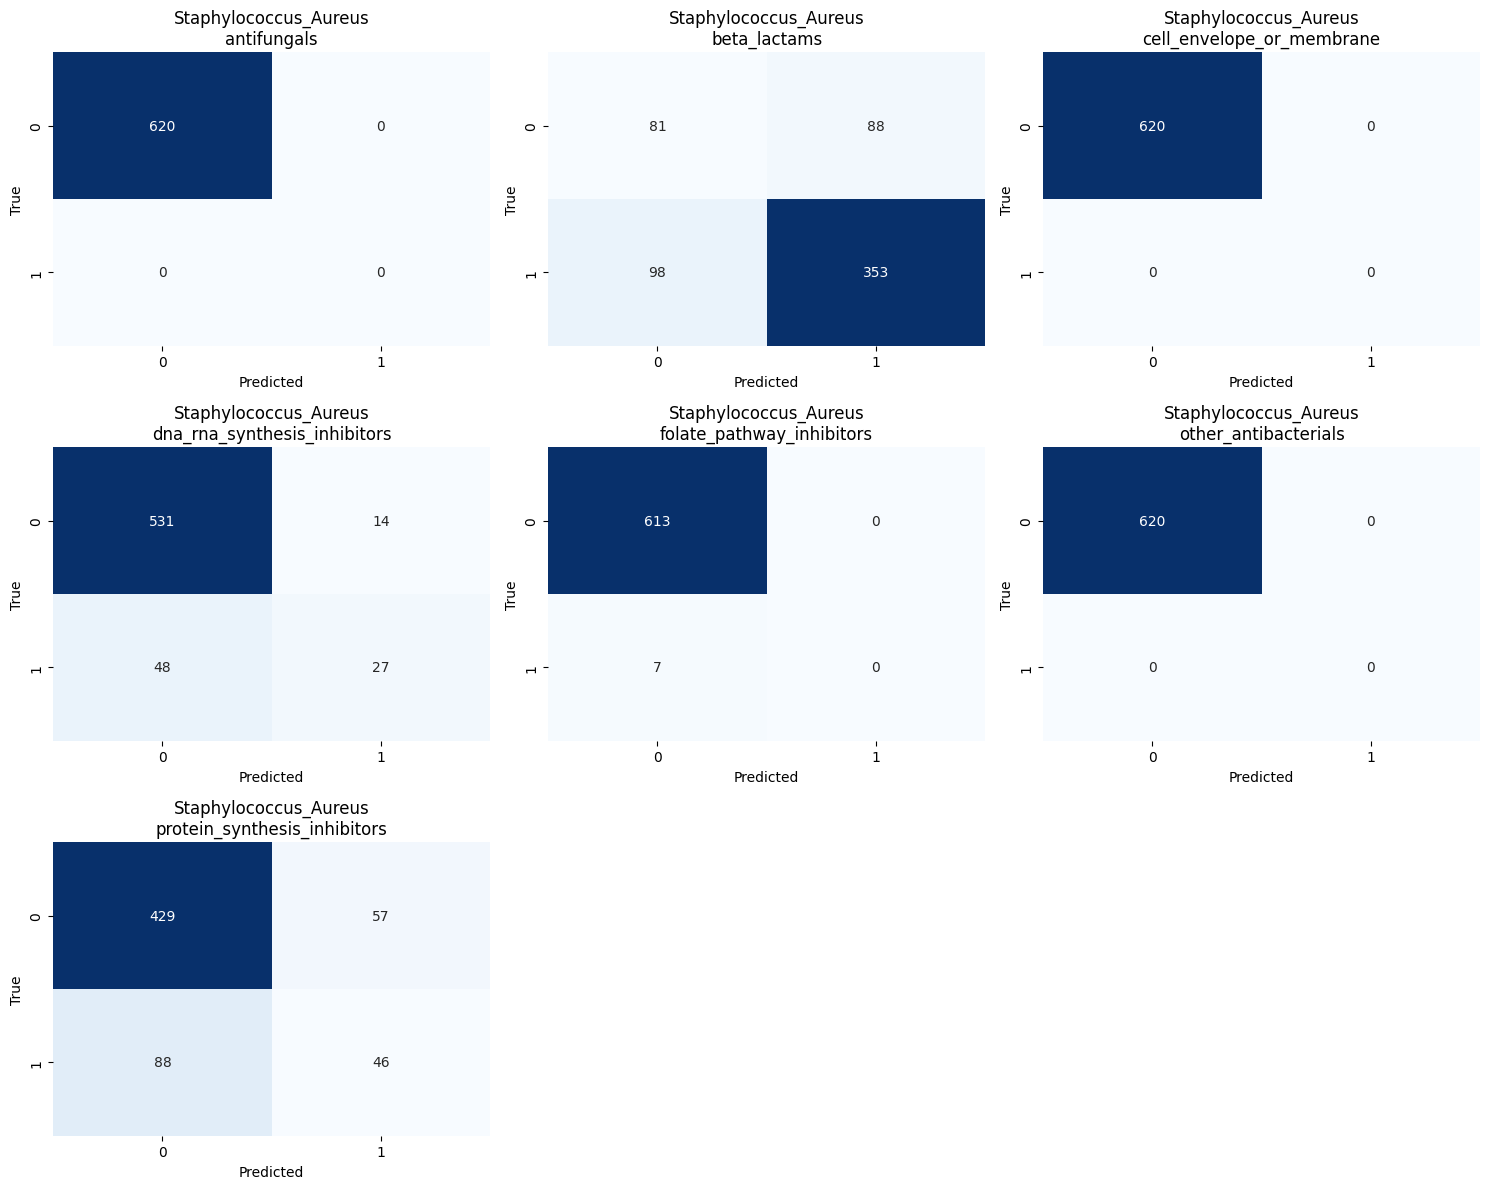

In [26]:
species_list = [d.name for d in RUN_DIR.iterdir() if d.is_dir()]

for species in species_list:

    print(f"\n===== {species} =====")

    try:
        _, df = load_species_data(RUN_DIR, species)

        y_true_fam, y_pred_fam = convert_to_family_level(
            df,
            antibiotic_to_family
        )

        plot_family_confusions(y_true_fam, y_pred_fam, species)

    except Exception as e:
        print(f" Error en {species}: {e}")

# Subfamily Analysis — Beta-lactams

## Objetivo

Analizar el rendimiento del modelo dentro de **beta-lactámicos**, separando por subfamilias:

- penicillins
- penicillins_inhibitor
- cephalosporins
- cephalosporins_inhibitor
- carbapenems
- carbapenems_inhibitor
- monobactams


## Idea clave

Antes:

antibiotic → familia global

Ahora:

antibiotic → subfamilia dentro de beta-lactams



## Regla de agregación (igual que antes)

Para cada paciente y subfamilia:

$$
y_{subfamily} = 1 \quad \text{si ANY antibiótico de esa subfamilia = 1}
$$


## Qué obtenemos

- matrices de confusión por subfamilia
- análisis fino dentro de beta-lactámicos

In [27]:
def build_beta_lactam_subfamily_mapping(organized_antibiotics):
    """
    Devuelve:
        antibiotic → subfamily (solo para beta-lactams)
    """
    mapping = {}

    beta_dict = organized_antibiotics["beta_lactams"]

    for subfamily, antibiotics in beta_dict.items():
        for ab in antibiotics:
            mapping[ab] = subfamily

    return mapping


beta_subfamily_map = build_beta_lactam_subfamily_mapping(organized_antibiotics)

print("Antibióticos en beta-lactams:", len(beta_subfamily_map))

Antibióticos en beta-lactams: 35


In [28]:
def convert_to_beta_subfamily_level(df, beta_subfamily_map):
    """
    Convierte a nivel subfamilia beta-lactams
    """

    subfamilies = sorted(set(beta_subfamily_map.values()))

    y_true_sub = {fam: [] for fam in subfamilies}
    y_pred_sub = {fam: [] for fam in subfamilies}

    for _, row in df.iterrows():

        sub_true = {fam: 0 for fam in subfamilies}
        sub_pred = {fam: 0 for fam in subfamilies}

        for col in df.columns:

            if not col.endswith("_true"):
                continue

            ab = col.replace("_true", "")

            if ab not in beta_subfamily_map:
                continue  # 🔥 solo beta-lactams

            fam = beta_subfamily_map[ab]

            pred_col = f"{ab}_pred"
            if pred_col not in df.columns:
                continue

            if row[col] == 1:
                sub_true[fam] = 1

            if row[pred_col] == 1:
                sub_pred[fam] = 1

        for fam in subfamilies:
            y_true_sub[fam].append(sub_true[fam])
            y_pred_sub[fam].append(sub_pred[fam])

    for fam in subfamilies:
        y_true_sub[fam] = np.array(y_true_sub[fam])
        y_pred_sub[fam] = np.array(y_pred_sub[fam])

    return y_true_sub, y_pred_sub

In [29]:
def plot_beta_subfamily_confusions(y_true_sub, y_pred_sub, species):

    subfamilies = list(y_true_sub.keys())

    n = len(subfamilies)
    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(5 * cols, 4 * rows))

    for i, fam in enumerate(subfamilies):

        cm = confusion_matrix(
            y_true_sub[fam],
            y_pred_sub[fam],
            labels=[0, 1]
        )

        plt.subplot(rows, cols, i + 1)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Reds",
            cbar=False
        )

        plt.title(f"{species}\n{fam}")
        plt.xlabel("Predicted")
        plt.ylabel("True")

    plt.tight_layout()
    plt.show()


===== Proteus_Mirabilis (beta-lactams) =====


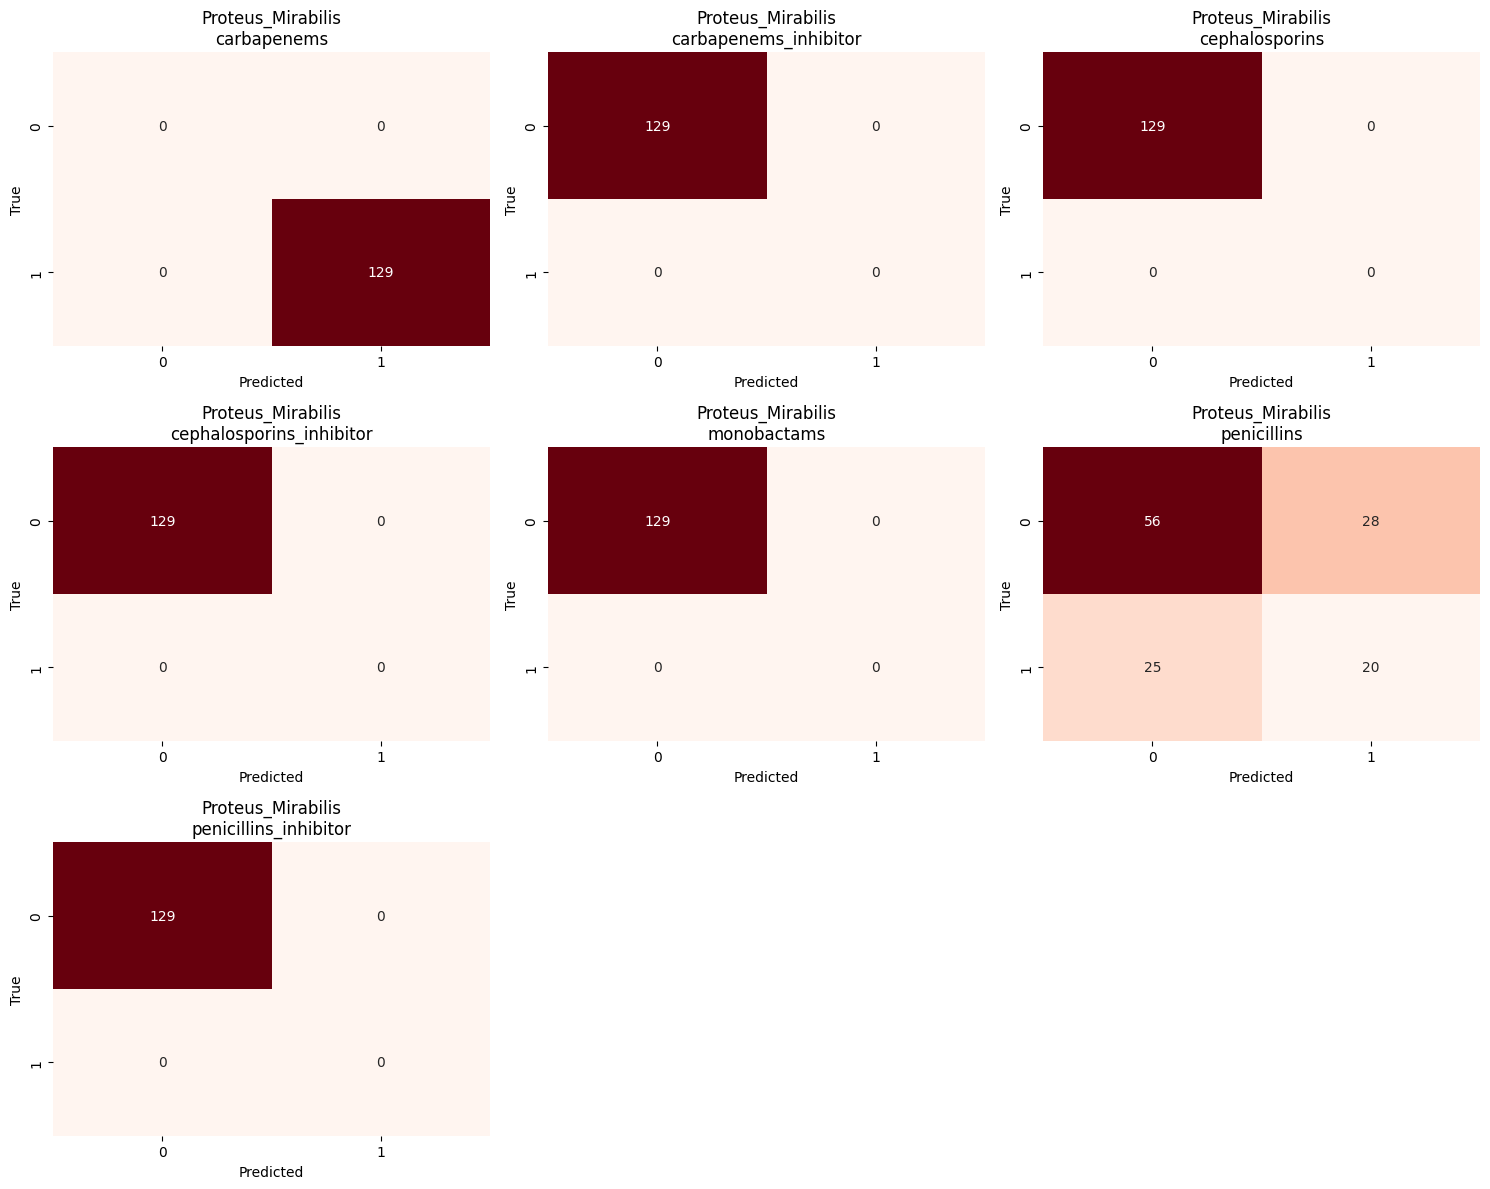


===== Escherichia_Coli (beta-lactams) =====


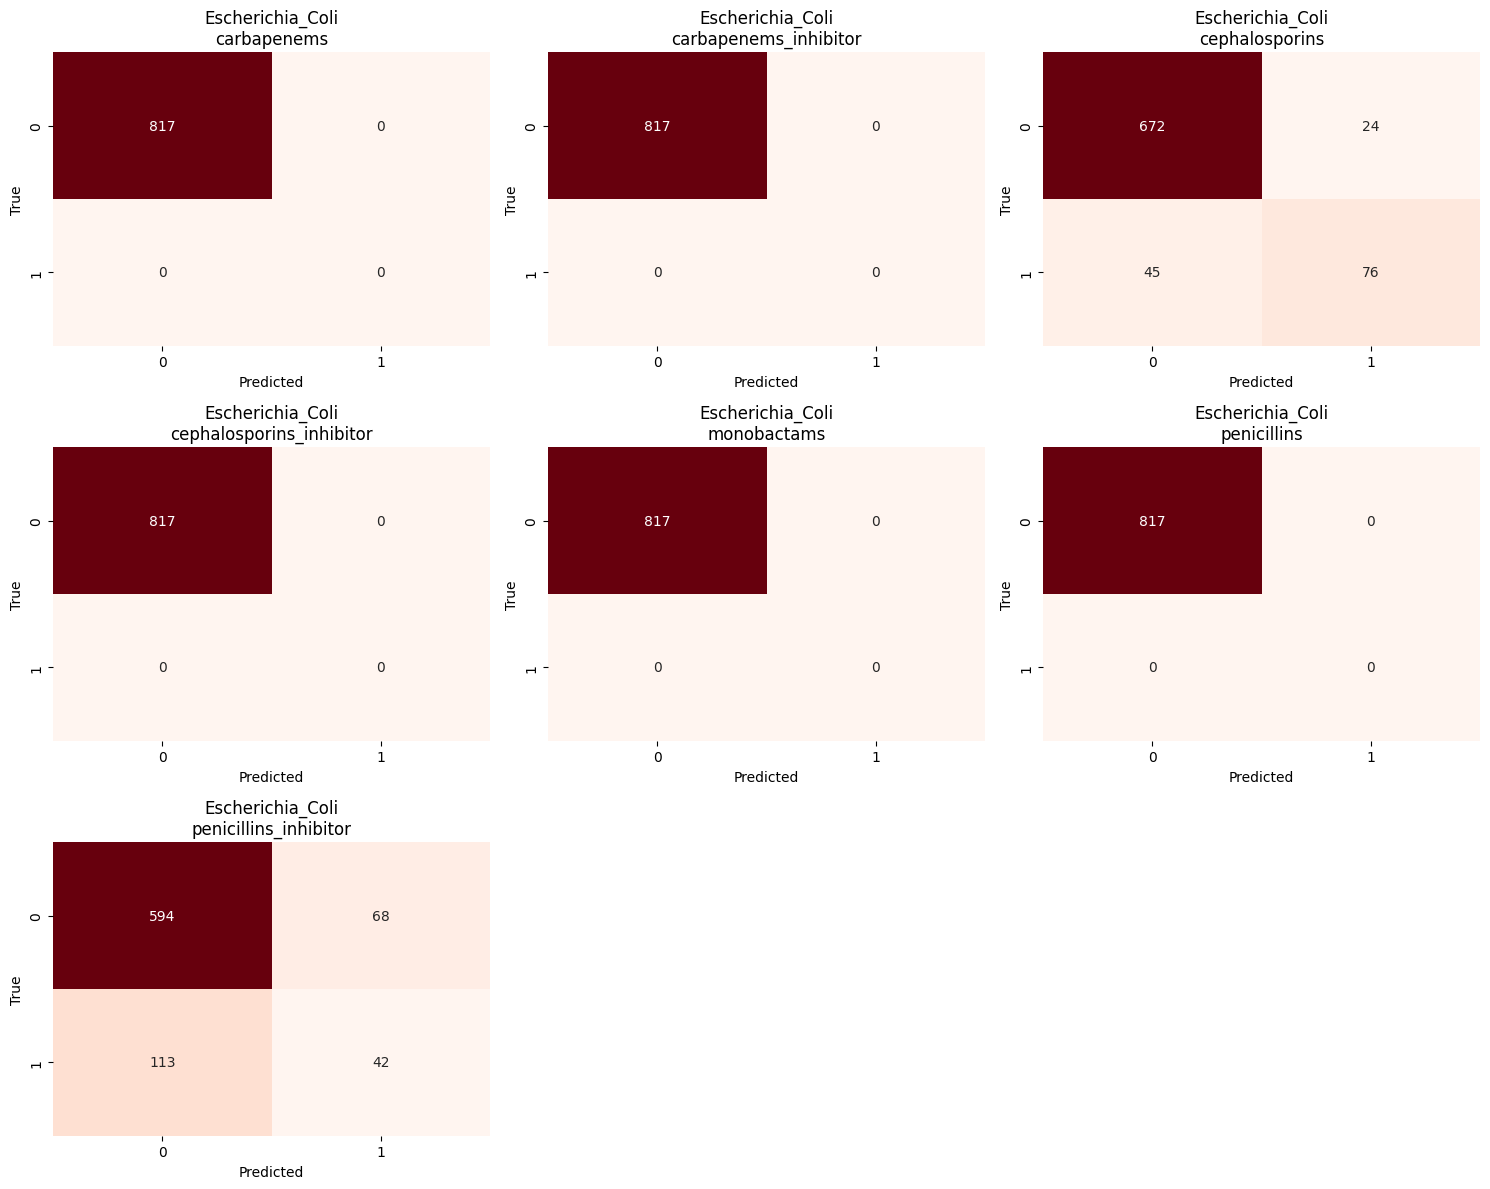


===== Klebsiella_Pneumoniae (beta-lactams) =====


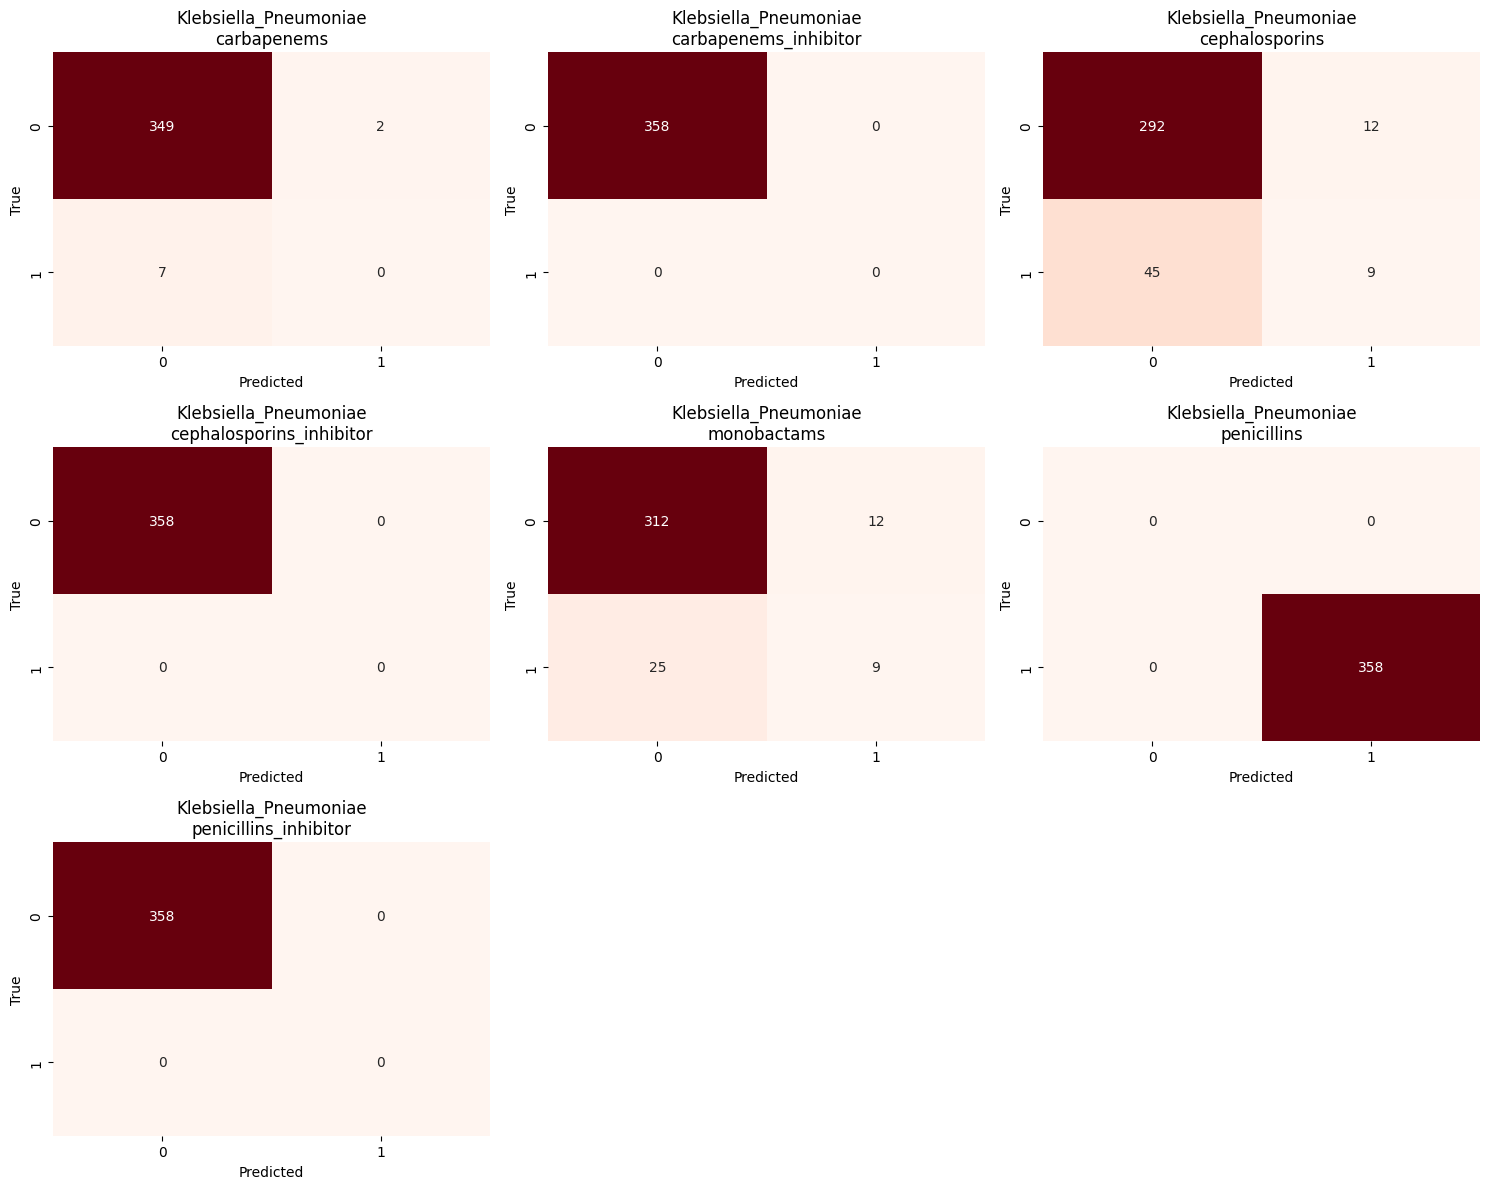


===== Staphylococcus_Epidermidis (beta-lactams) =====


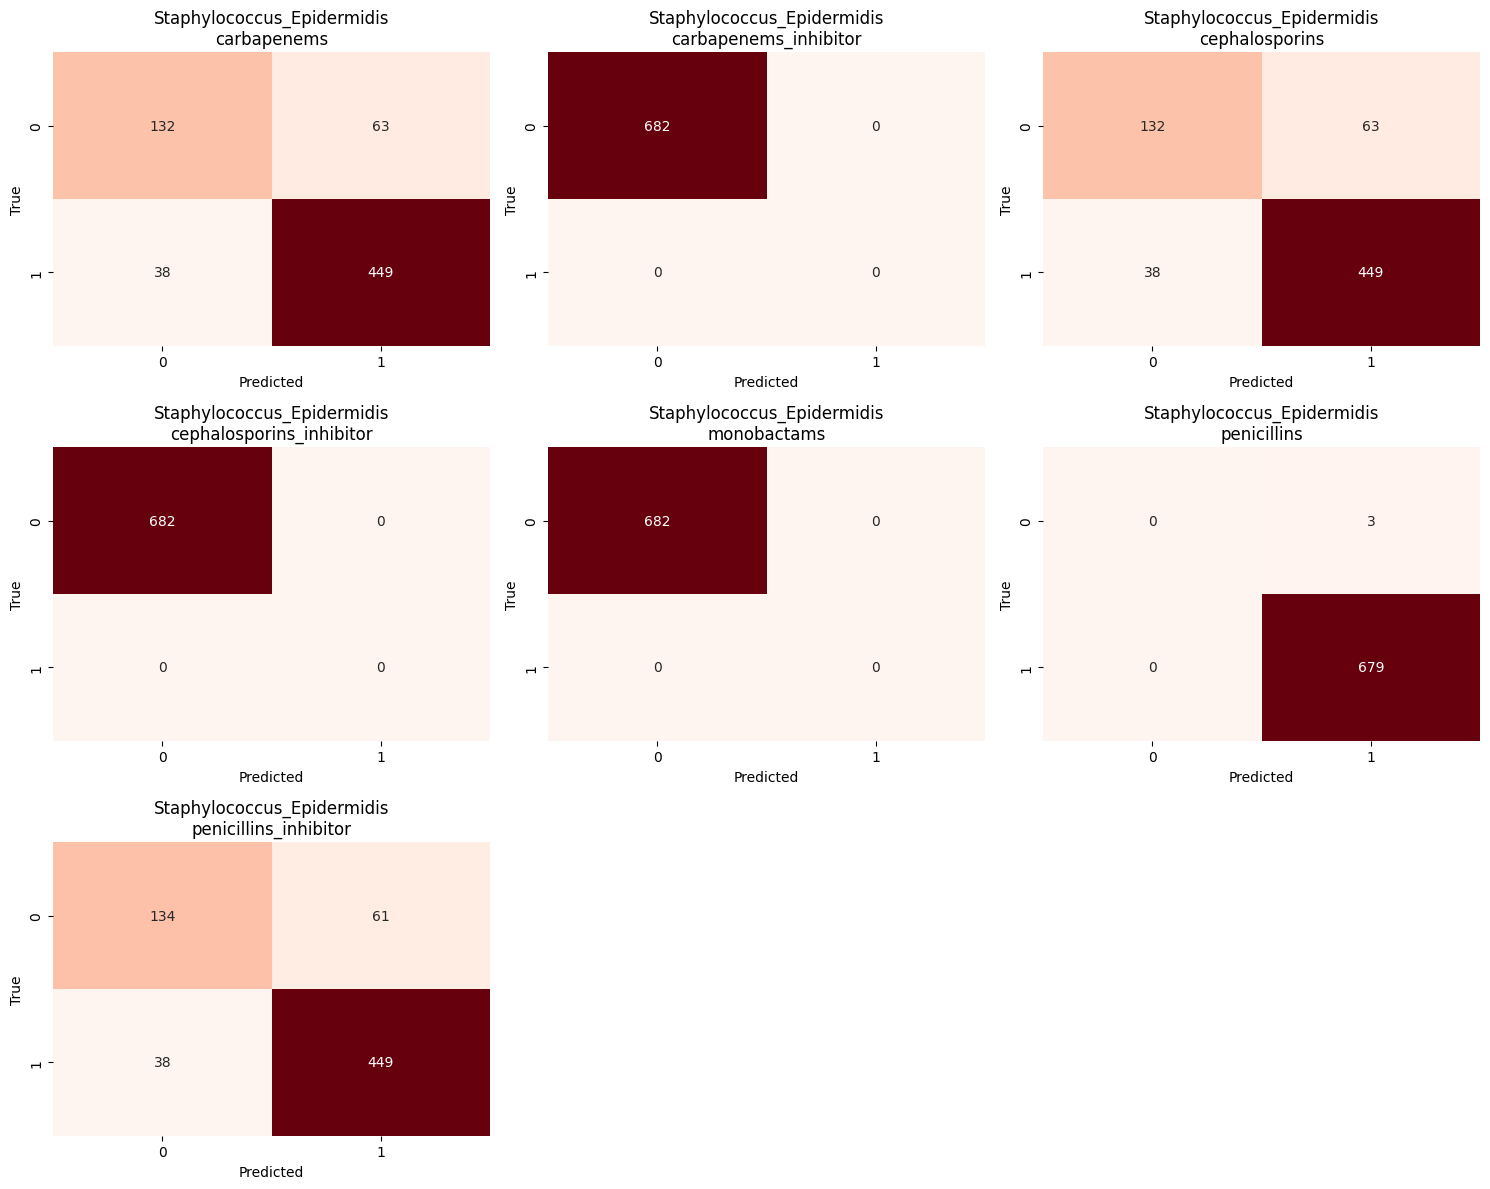


===== Enterococcus_Faecium (beta-lactams) =====


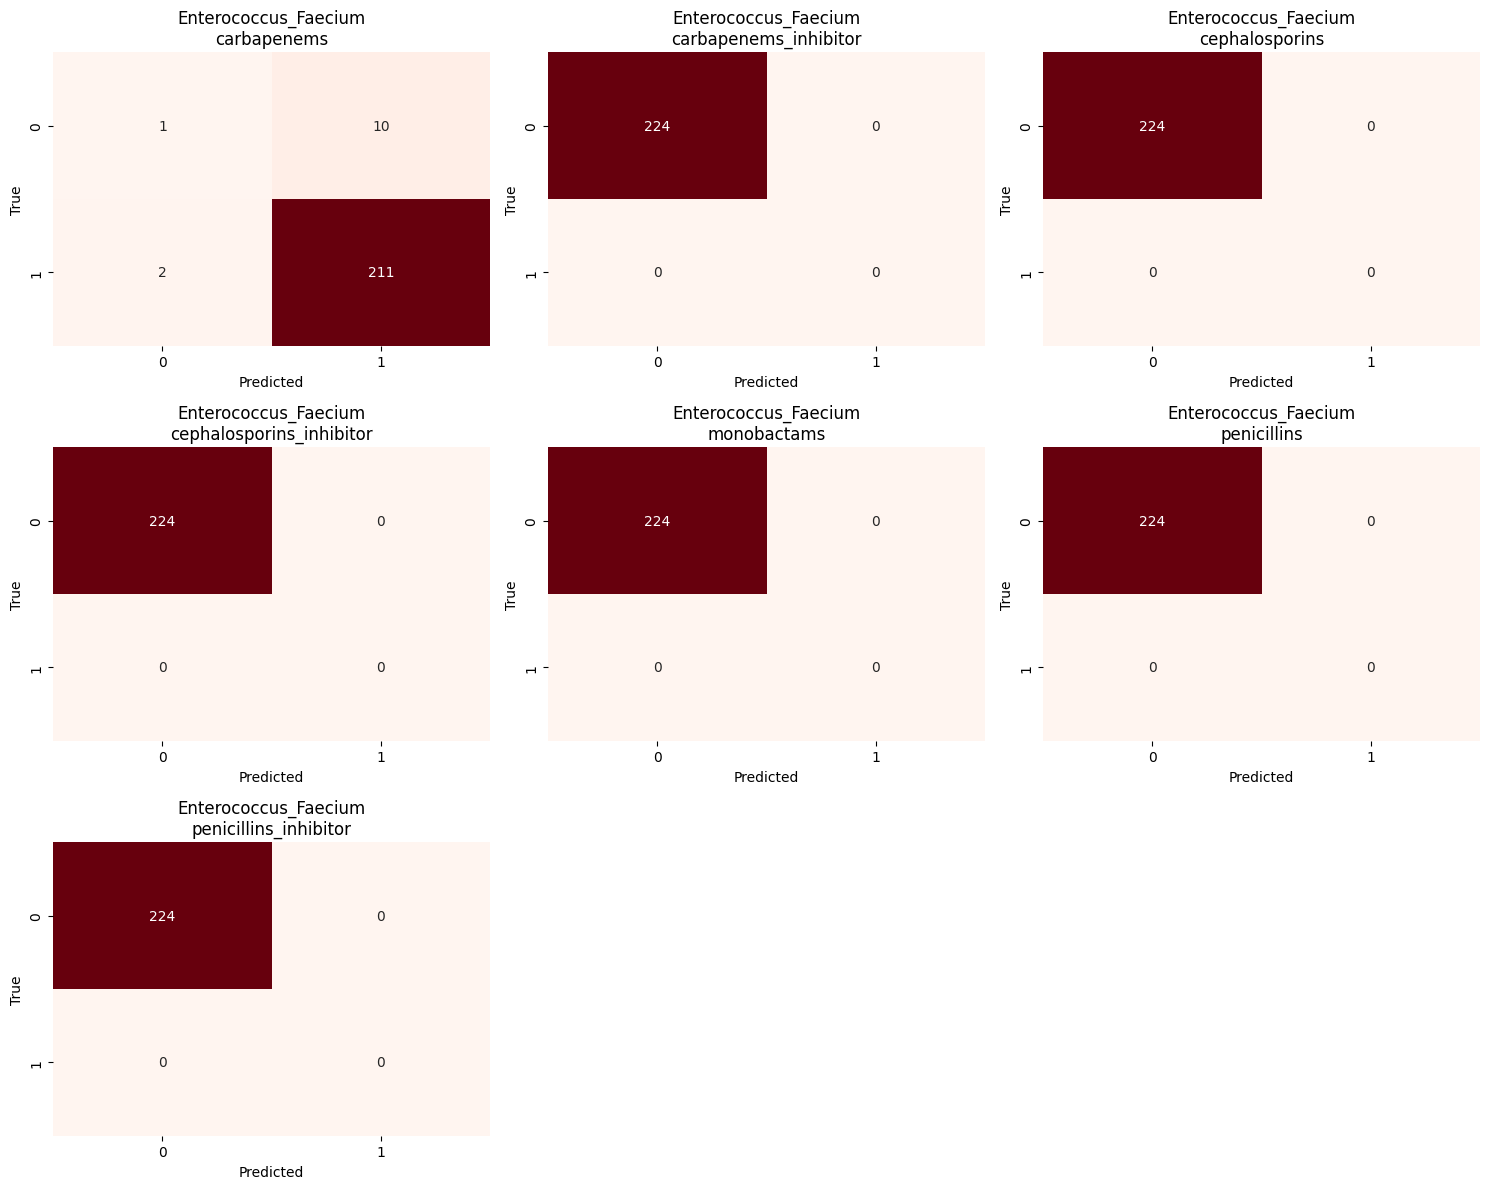


===== Pseudomonas_Aeruginosa (beta-lactams) =====


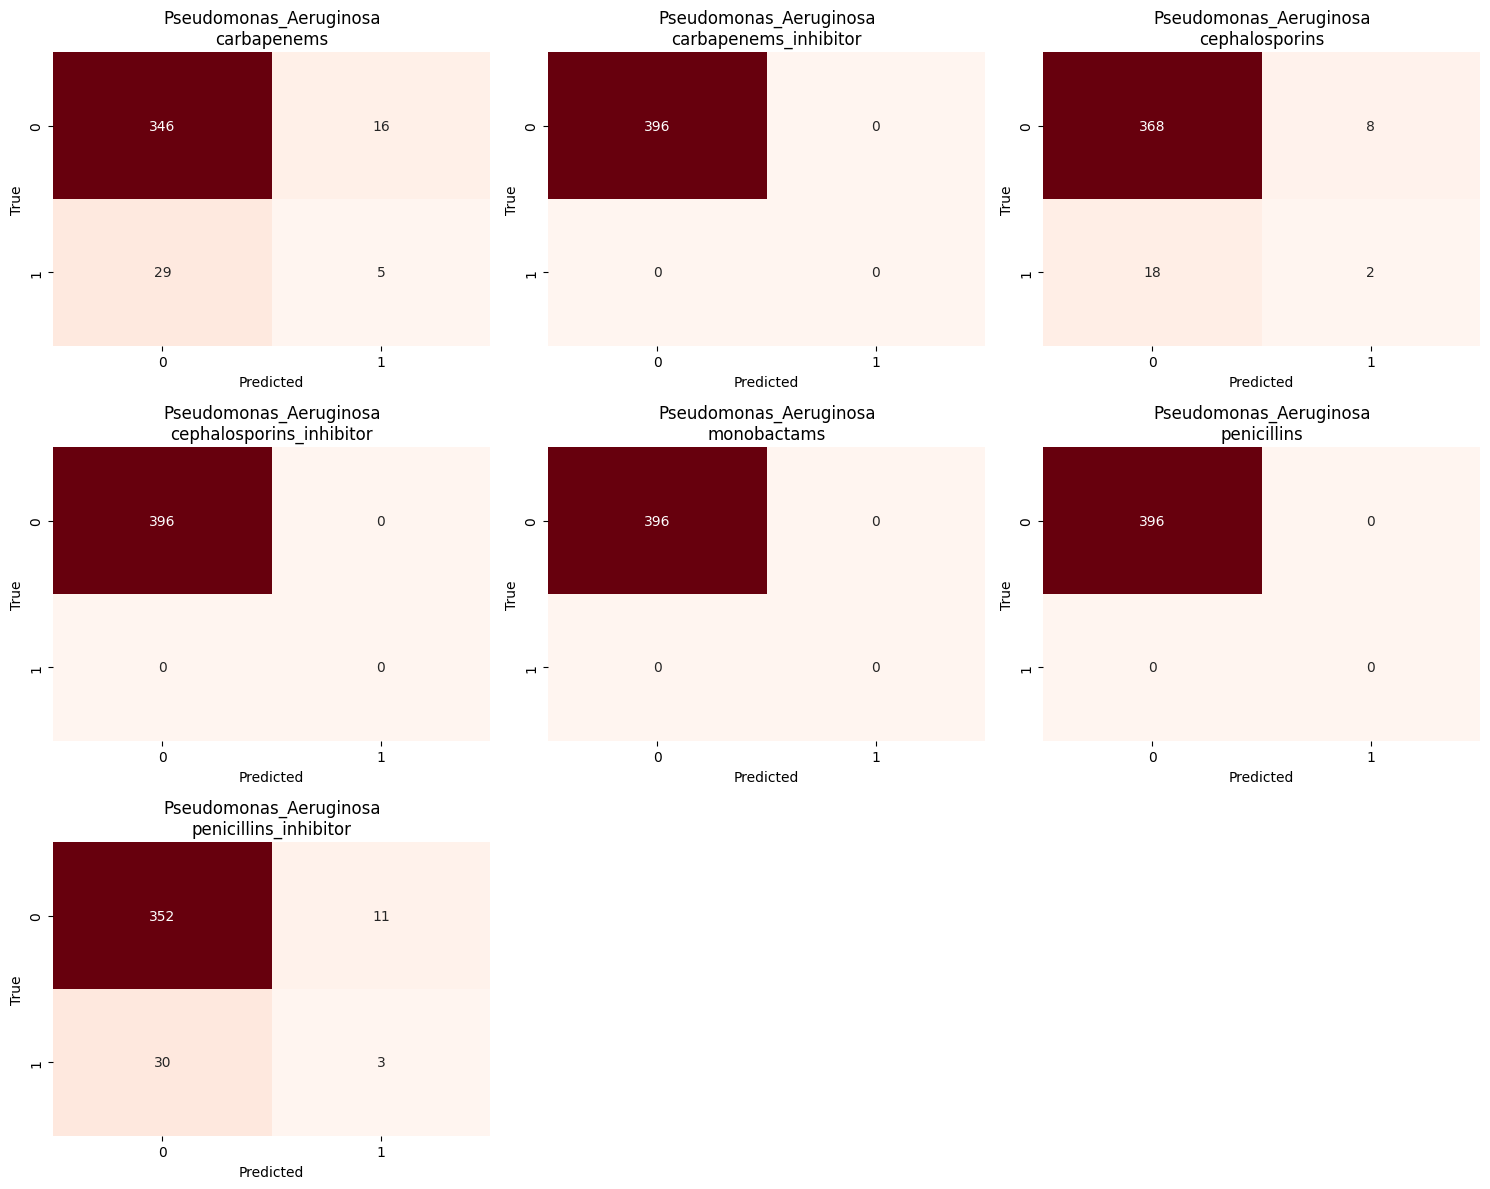


===== Staphylococcus_Aureus (beta-lactams) =====


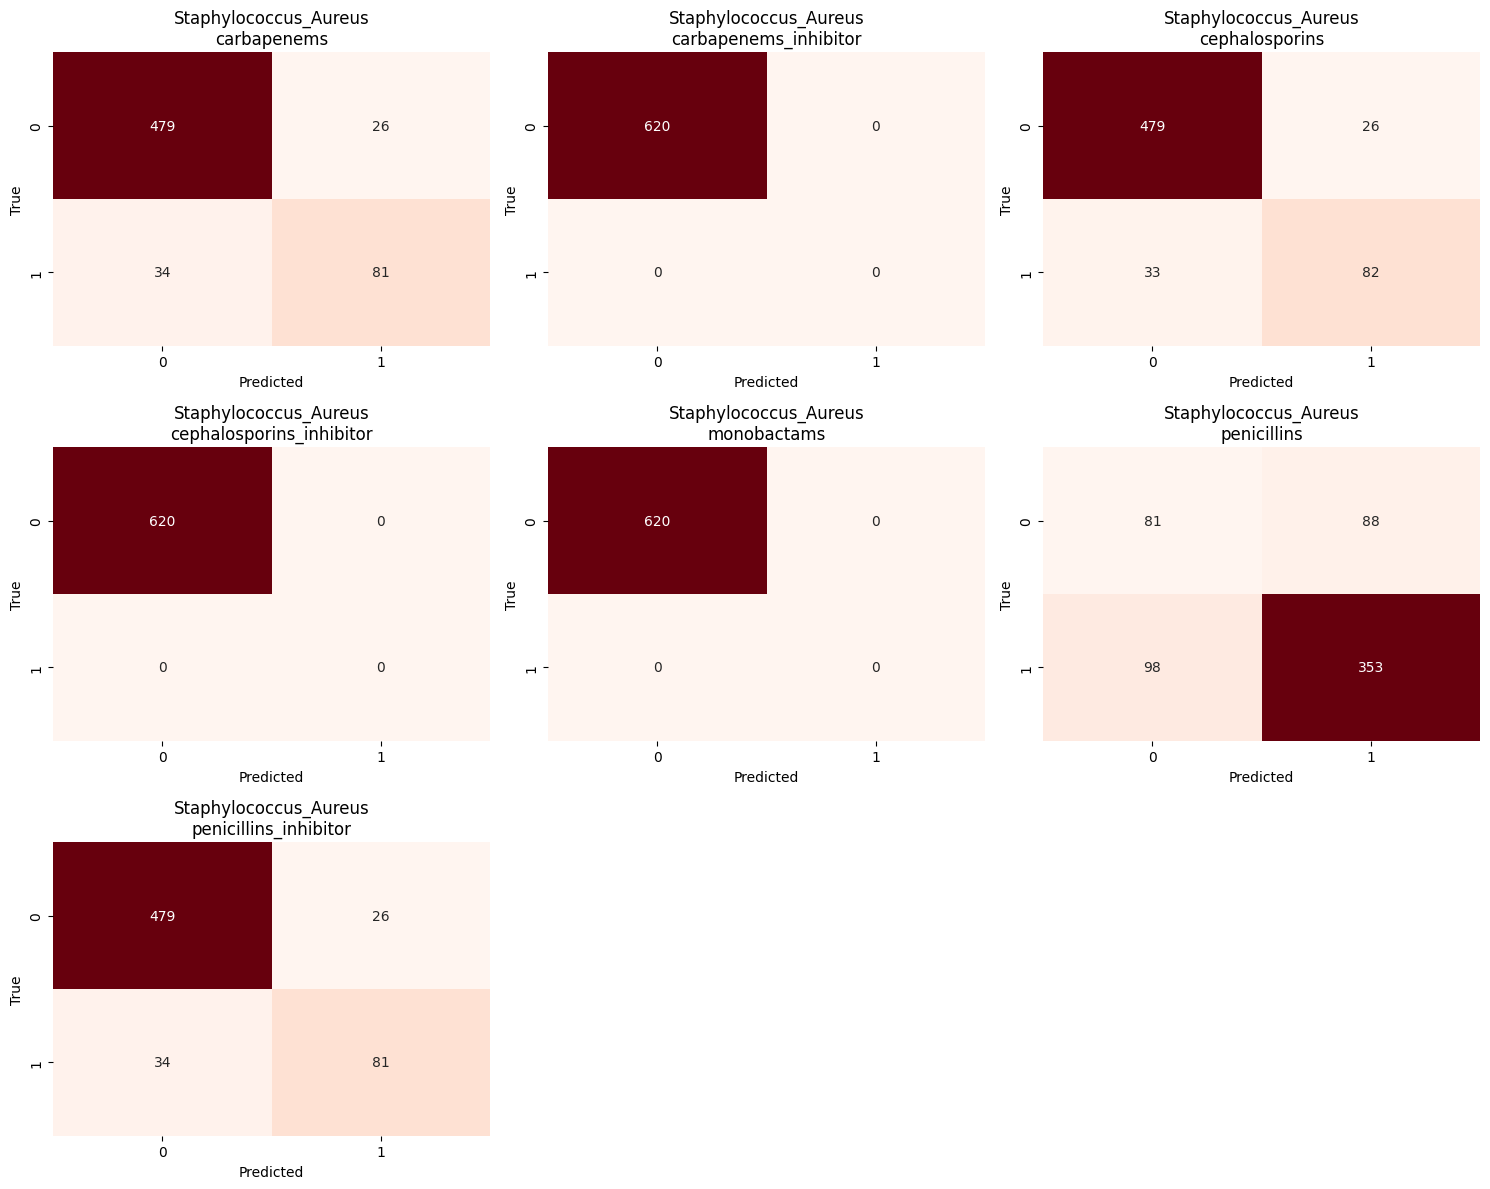

In [30]:
for species in species_list:

    print(f"\n===== {species} (beta-lactams) =====")

    try:
        _, df = load_species_data(RUN_DIR, species)

        y_true_sub, y_pred_sub = convert_to_beta_subfamily_level(
            df,
            beta_subfamily_map
        )

        plot_beta_subfamily_confusions(y_true_sub, y_pred_sub, species)

    except Exception as e:
        print(f" Error en {species}: {e}")

# Resistance Phenotypes Analysis

## Objetivo

Clasificar cada paciente según su perfil de resistencia a nivel de familias:

### Definiciones

Para cada paciente:

- **Susceptible (S)**  
  → no resistente a ninguna familia

- **Uniresistant (UR)**  
  → resistente a EXACTAMENTE 1 familia

- **Multiresistant (MR)**  
  → resistente a ≥2 familias

## Cómo se calcula

Primero convertimos a nivel familia

Luego contamos:

$$
n_{\text{families resistant}} = \sum_{families} y_{family}
$$

Y clasificamos:

- 0 → susceptible  
- 1 → uniresistant  
- ≥2 → multiresistant  


## Qué vamos a evaluar

1. Confusion matrix global (S / UR / MR)
2. Uniresistance por familia
3. Sensibilidad global (detección de resistencia)


In [31]:
def family_dicts_to_matrix(y_true_fam, y_pred_fam):
    """
    Convierte dicts {family: array} → matrices (n_samples, n_families)
    """
    families = sorted(y_true_fam.keys())

    Y_true = np.vstack([y_true_fam[f] for f in families]).T
    Y_pred = np.vstack([y_pred_fam[f] for f in families]).T

    return families, Y_true, Y_pred

In [32]:
def classify_resistance(Y):
    """
    Clasifica cada paciente en:
    0 → susceptible
    1 → uniresistant
    2 → multiresistant
    """
    n_res = Y.sum(axis=1)

    labels = np.zeros(len(Y), dtype=int)

    labels[n_res == 1] = 1
    labels[n_res >= 2] = 2

    return labels

In [33]:
def plot_global_resistance_cm(Y_true, Y_pred, species):

    y_true_cls = classify_resistance(Y_true)
    y_pred_cls = classify_resistance(Y_pred)

    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=[0,1,2])

    labels = ["S", "UR", "MR"]

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=labels,
                yticklabels=labels)

    plt.title(f"{species} — Resistance profile")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [34]:
def compute_uniresistance_distribution(Y, families):
    """
    Devuelve distribución de familias en pacientes uniresistentes
    """
    n_res = Y.sum(axis=1)

    uni_mask = (n_res == 1)

    counts = {fam: 0 for fam in families}

    for i in range(len(Y)):
        if not uni_mask[i]:
            continue

        fam_idx = np.where(Y[i] == 1)[0]

        if len(fam_idx) == 1:
            fam = families[fam_idx[0]]
            counts[fam] += 1

    return counts

In [35]:
def plot_uniresistance(counts, species, title="Uniresistance"):

    df = pd.DataFrame({
        "family": list(counts.keys()),
        "count": list(counts.values())
    }).sort_values("count", ascending=False)

    plt.figure(figsize=(8,4))
    sns.barplot(data=df, x="family", y="count")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{species} — {title}")
    plt.tight_layout()
    plt.show()

In [36]:
def compute_global_sensitivity(Y_true, Y_pred):
    """
    Detecta si el modelo identifica correctamente pacientes resistentes
    (al menos una familia)
    """

    true_resistant = (Y_true.sum(axis=1) > 0)
    pred_resistant = (Y_pred.sum(axis=1) > 0)

    tp = np.sum((true_resistant == 1) & (pred_resistant == 1))
    fn = np.sum((true_resistant == 1) & (pred_resistant == 0))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    return sensitivity

In [37]:
def run_resistance_analysis(species):

    print(f"\n===== {species} =====")

    _, df = load_species_data(RUN_DIR, species)

    y_true_fam, y_pred_fam = convert_to_family_level(
        df,
        antibiotic_to_family
    )

    families, Y_true, Y_pred = family_dicts_to_matrix(
        y_true_fam,
        y_pred_fam
    )

    # 1. CM global
    plot_global_resistance_cm(Y_true, Y_pred, species)

    # 2. Uniresistance
    counts = compute_uniresistance_distribution(Y_true, families)
    plot_uniresistance(counts, species)

    # 3. Sensibilidad
    sens = compute_global_sensitivity(Y_true, Y_pred)
    print(f"Sensitivity (detect any resistance): {sens:.3f}")


===== Proteus_Mirabilis =====


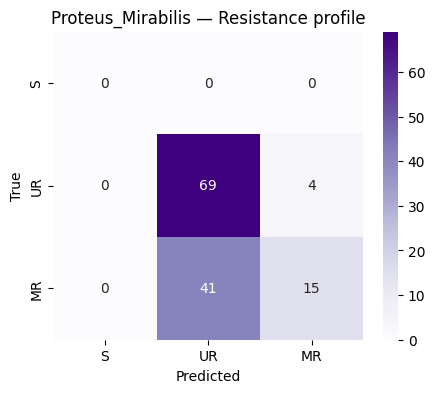

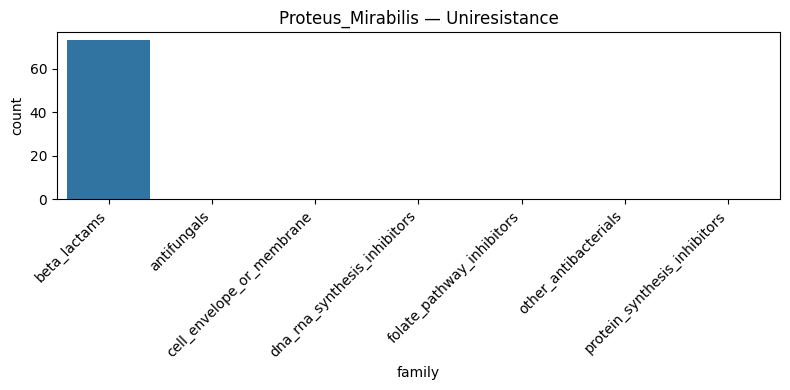

Sensitivity (detect any resistance): 1.000

===== Escherichia_Coli =====


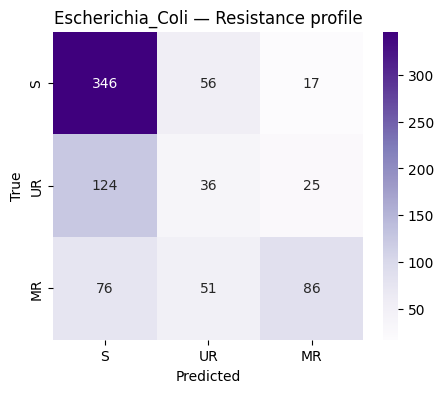

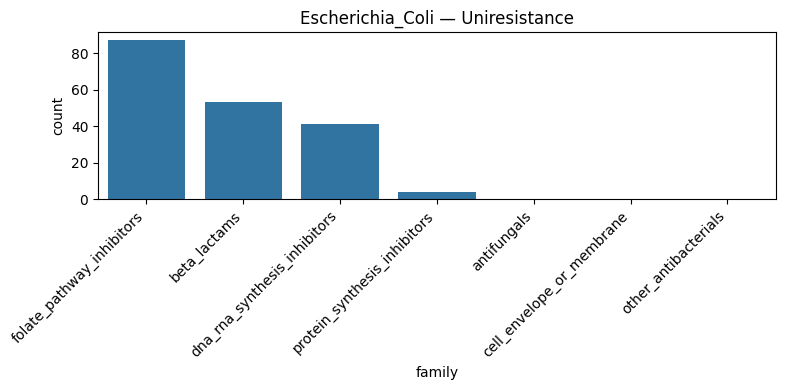

Sensitivity (detect any resistance): 0.497

===== Klebsiella_Pneumoniae =====


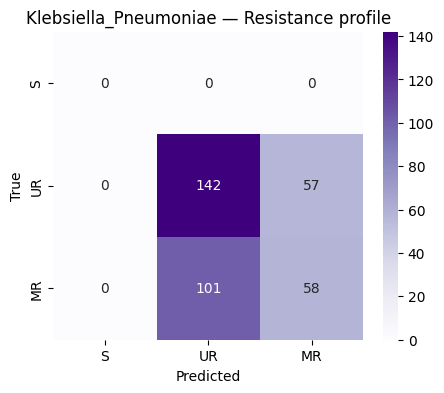

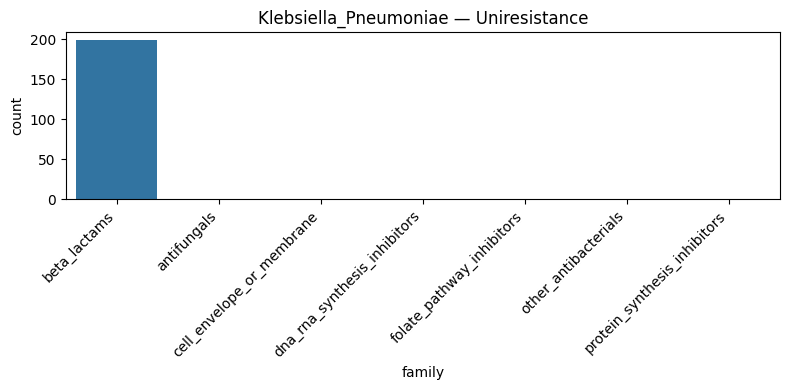

Sensitivity (detect any resistance): 1.000

===== Staphylococcus_Epidermidis =====


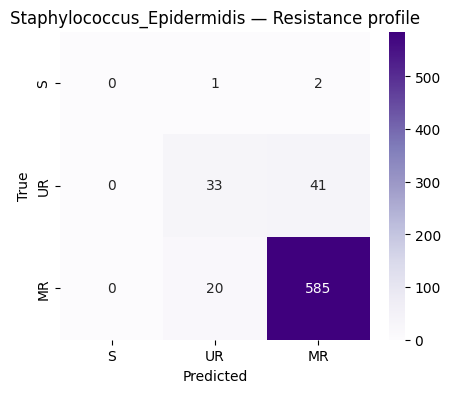

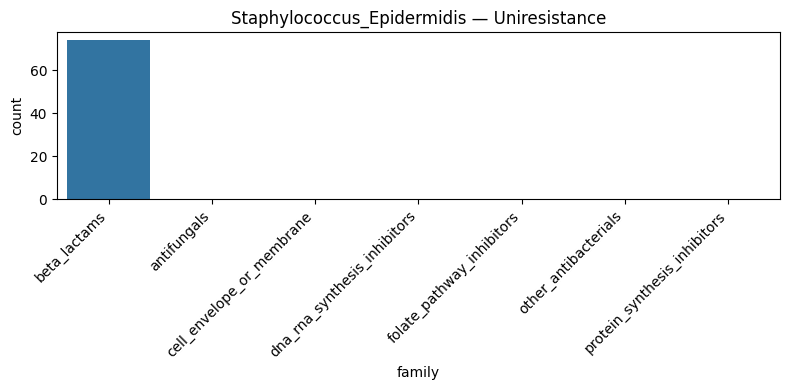

Sensitivity (detect any resistance): 1.000

===== Enterococcus_Faecium =====


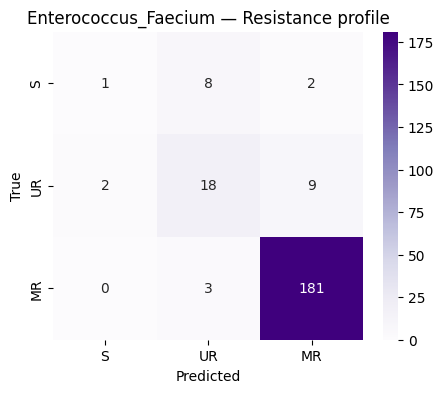

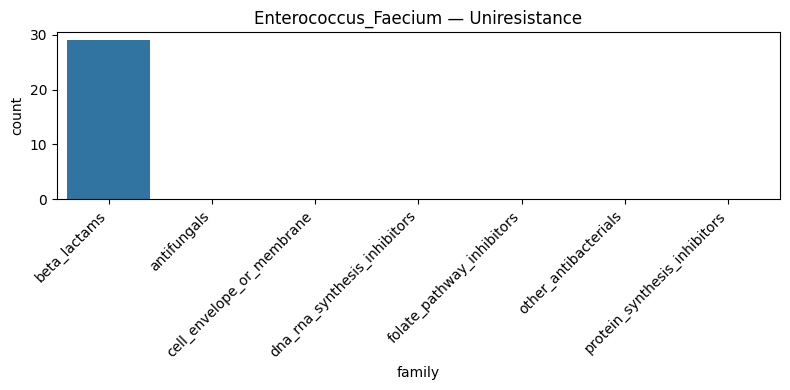

Sensitivity (detect any resistance): 0.991

===== Pseudomonas_Aeruginosa =====


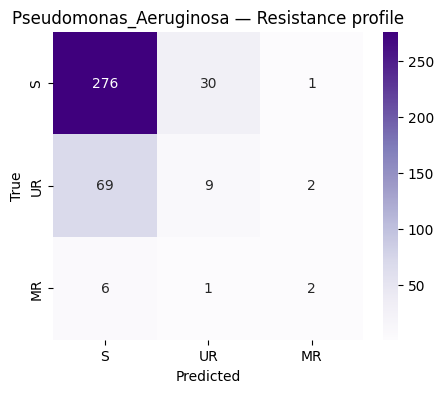

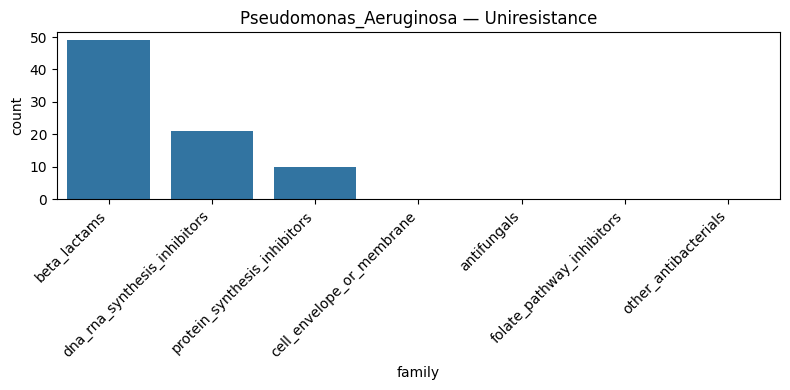

Sensitivity (detect any resistance): 0.157

===== Staphylococcus_Aureus =====


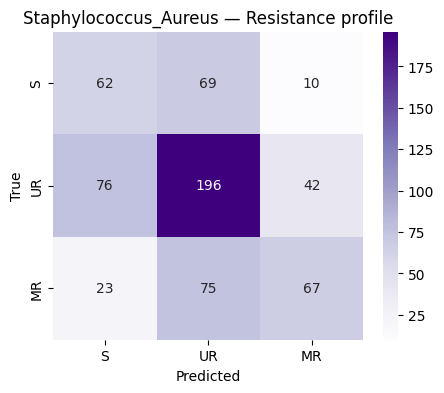

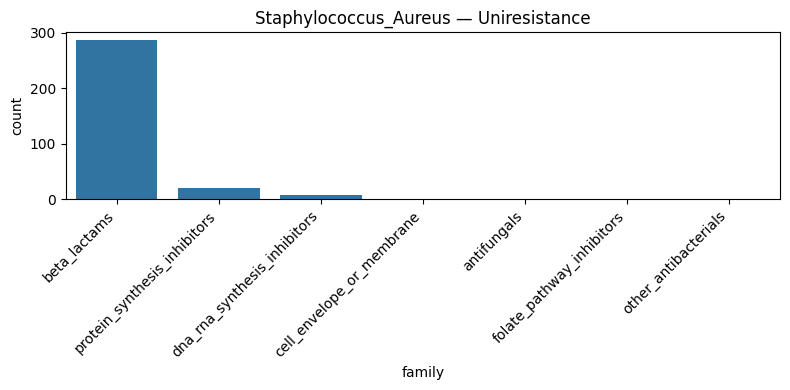

Sensitivity (detect any resistance): 0.793


In [38]:
for species in species_list:
    try:
        run_resistance_analysis(species)
    except Exception as e:
        print(f"Error en {species}: {e}")

# Family vs Family Confusion Matrix (ALL patients)

## Objetivo

Construir una matriz de confusión entre familias usando TODOS los pacientes.


## Idea clave (IMPORTANTE)

Para cada paciente:

- puede tener múltiples familias resistentes
- y múltiples predicciones

entonces NO es 1 label → 1 label



## Cómo resolvemos esto

Generamos pares (true_family, predicted_family)

### Para cada paciente:

Si:
- TRUE = {A, B}
- PRED = {A, C}

Generamos:

(A → A)  
(A → C)  
(B → A)  
(B → C)



## Interpretación

Esto mide:
 “Si la familia real es X, ¿qué familias predice el modelo?”

Incluye:
- errores cruzados
- confusión estructural
- patrones de co-predicción


## Nota importante

- excluimos pacientes sin resistencia (todo 0)

In [39]:
def extract_family_pairs(Y_true, Y_pred, families):
    """
    Genera pares (true_family, pred_family) para TODOS los pacientes
    """

    true_labels = []
    pred_labels = []

    for i in range(len(Y_true)):

        true_idx = np.where(Y_true[i] == 1)[0]
        pred_idx = np.where(Y_pred[i] == 1)[0]

        # ignorar pacientes sin resistencia real
        if len(true_idx) == 0:
            continue

        # si el modelo no predice nada → opcional:
        if len(pred_idx) == 0:
            continue

        for t in true_idx:
            for p in pred_idx:
                true_labels.append(families[t])
                pred_labels.append(families[p])

    return true_labels, pred_labels

In [40]:
from sklearn.metrics import confusion_matrix

def compute_family_confusion_matrix(true_labels, pred_labels, families):

    cm = confusion_matrix(
        true_labels,
        pred_labels,
        labels=families
    )

    return cm

In [41]:
def plot_family_vs_family_cm(cm, families, species):

    fig, axes = plt.subplots(1, 2, figsize=(14,6))

    # --- RAW ---
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        xticklabels=families,
        yticklabels=families,
        ax=axes[0]
    )

    axes[0].set_title(f"{species} — Raw counts")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    # --- NORMALIZADO ---
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=families,
        yticklabels=families,
        ax=axes[1]
    )

    axes[1].set_title(f"{species} — Row-normalized")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()

In [42]:
def run_family_confusion_all(species):

    print(f"\n===== {species} =====")

    _, df = load_species_data(RUN_DIR, species)

    y_true_fam, y_pred_fam = convert_to_family_level(
        df,
        antibiotic_to_family
    )

    families, Y_true, Y_pred = family_dicts_to_matrix(
        y_true_fam,
        y_pred_fam
    )

    true_labels, pred_labels = extract_family_pairs(
        Y_true,
        Y_pred,
        families
    )

    if len(true_labels) == 0:
        print(" No hay datos suficientes")
        return

    cm = compute_family_confusion_matrix(
        true_labels,
        pred_labels,
        families
    )

    plot_family_vs_family_cm(cm, families, species)


===== Proteus_Mirabilis =====


/tmp/ipykernel_18232/2758235331.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


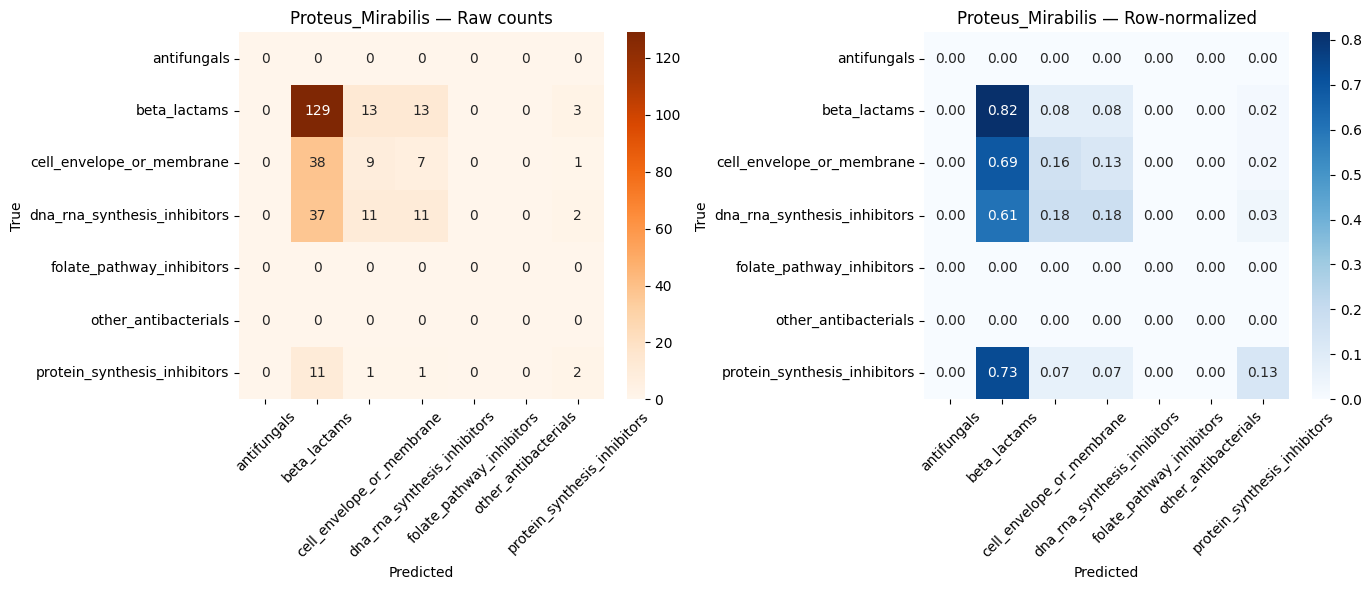


===== Escherichia_Coli =====


/tmp/ipykernel_18232/2758235331.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


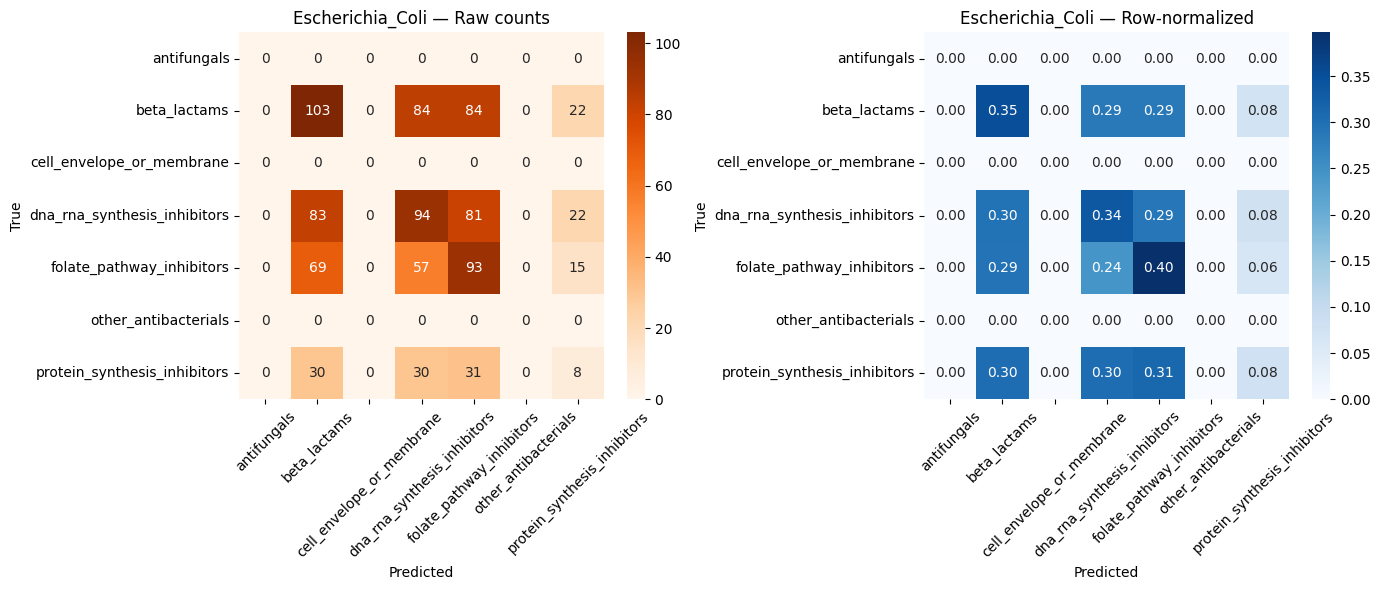


===== Klebsiella_Pneumoniae =====


/tmp/ipykernel_18232/2758235331.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


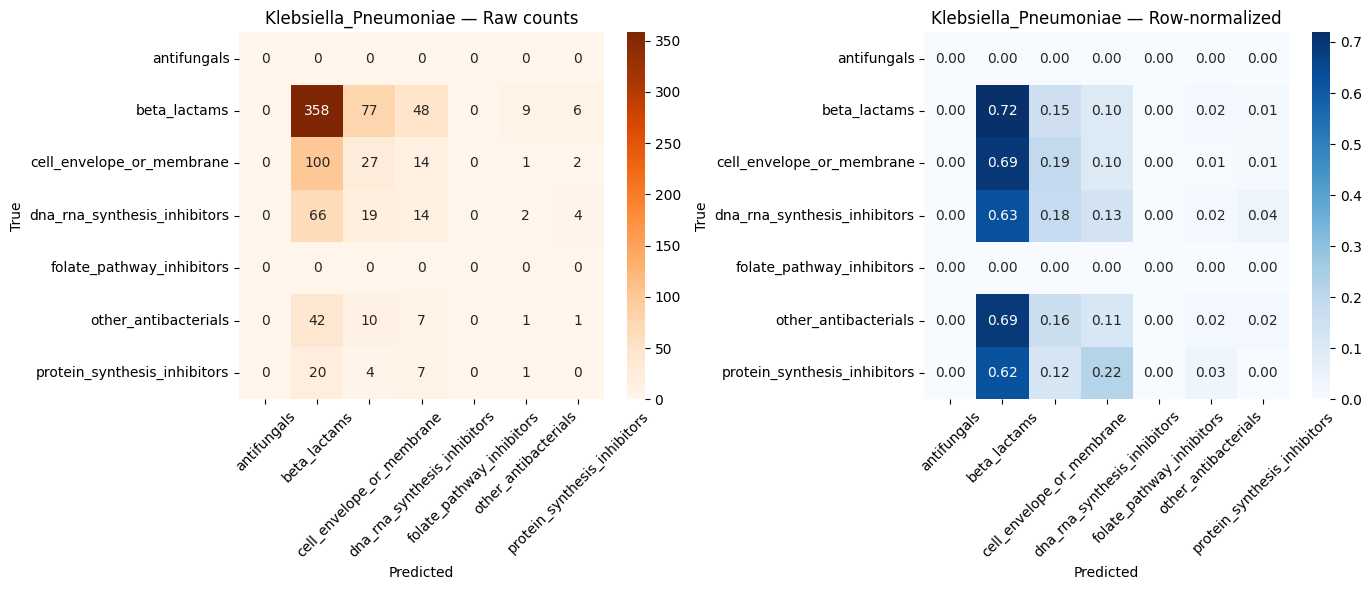


===== Staphylococcus_Epidermidis =====


/tmp/ipykernel_18232/2758235331.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


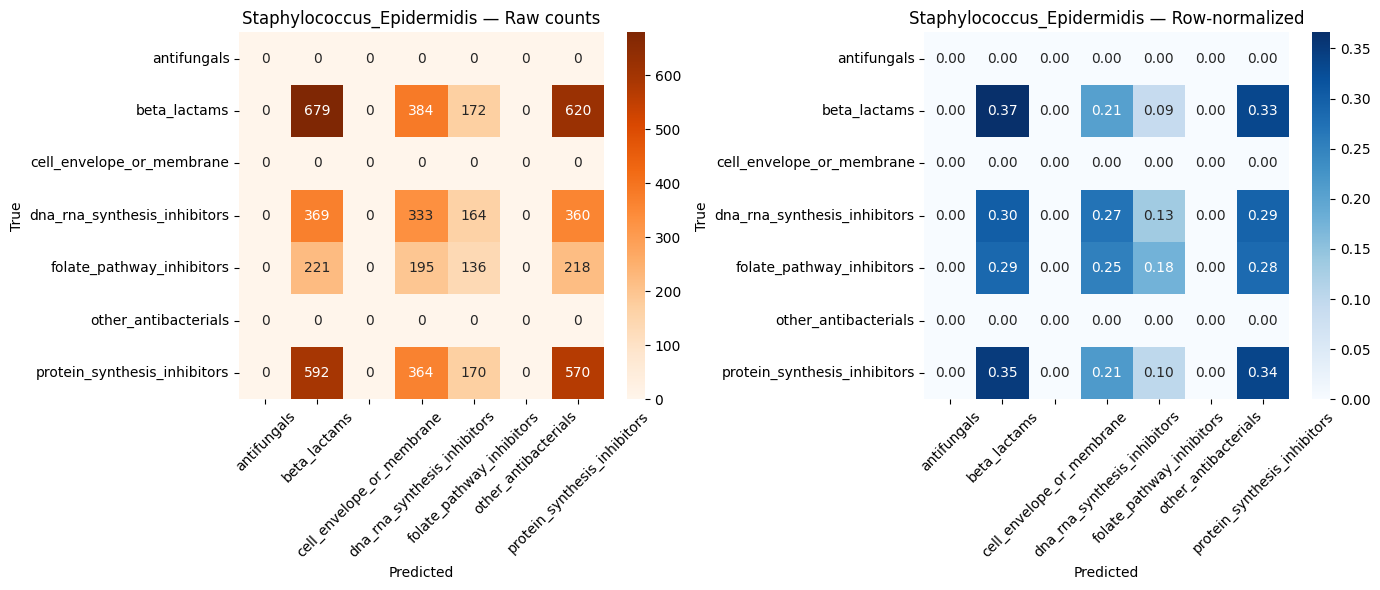


===== Enterococcus_Faecium =====


/tmp/ipykernel_18232/2758235331.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


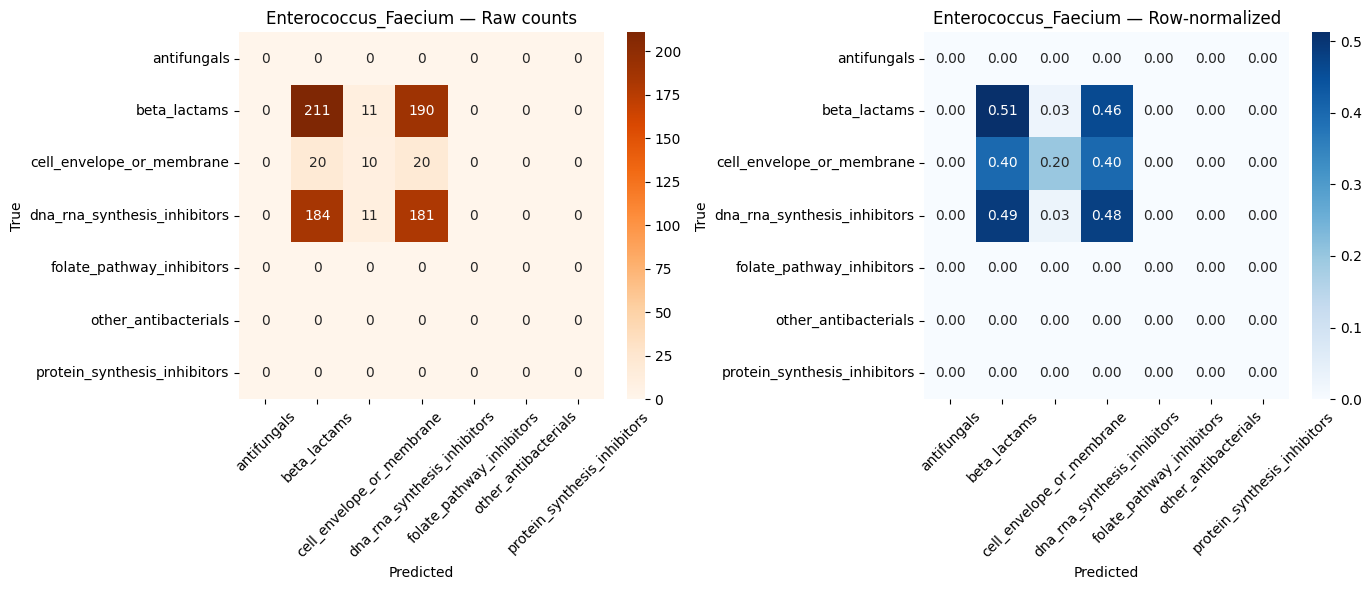


===== Pseudomonas_Aeruginosa =====


/tmp/ipykernel_18232/2758235331.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


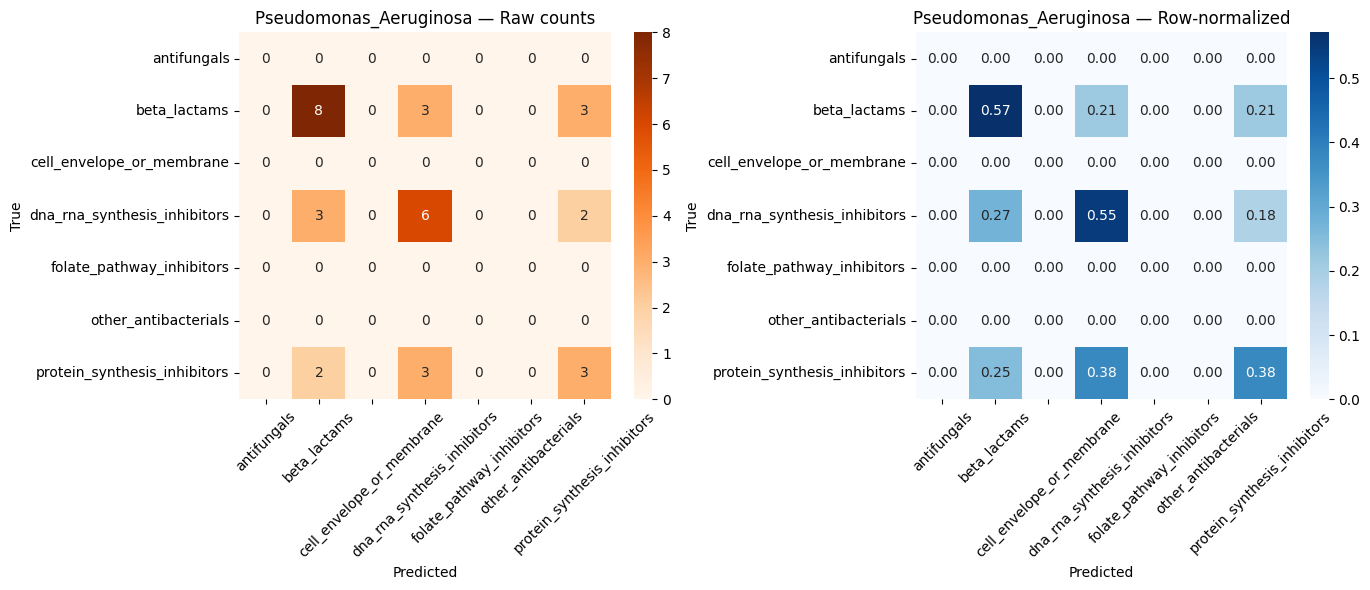


===== Staphylococcus_Aureus =====


/tmp/ipykernel_18232/2758235331.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


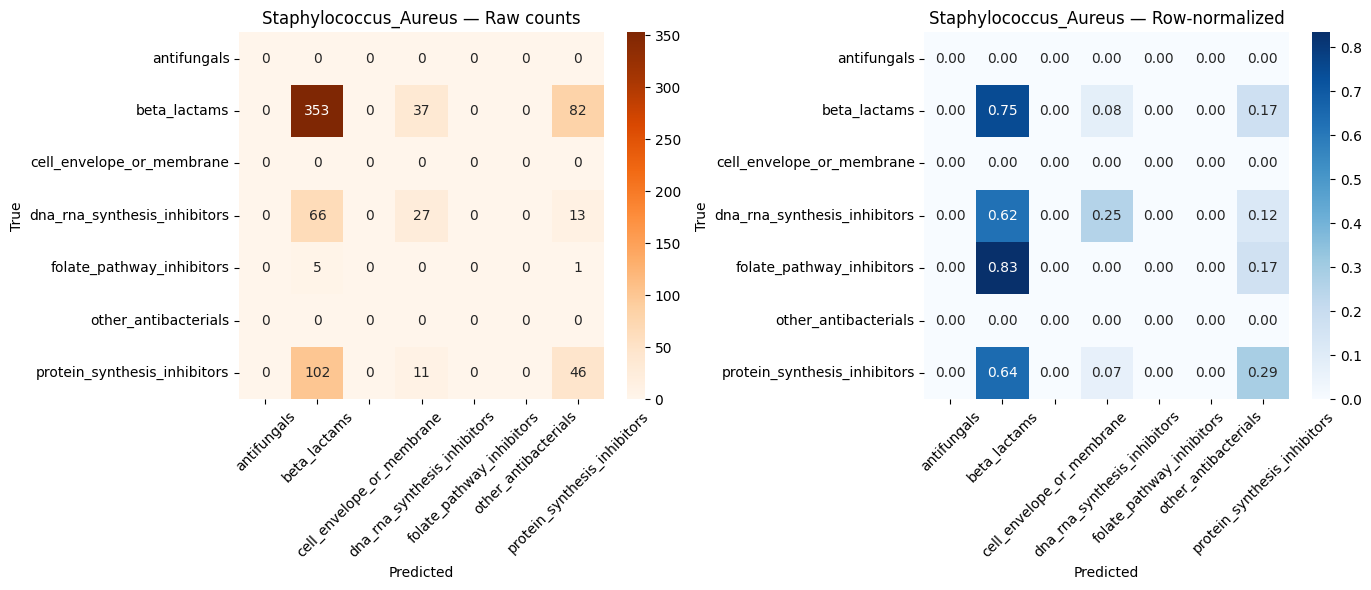

In [43]:
species_list = [d.name for d in RUN_DIR.iterdir() if d.is_dir()]

for species in species_list:
    try:
        run_family_confusion_all(species)
    except Exception as e:
        print(f" Error en {species}: {e}")

In [44]:
def extract_family_pairs_with_susceptible(Y_true, Y_pred, families):
    """
    Genera pares incluyendo clase 'S' (susceptible)
    """

    true_labels = []
    pred_labels = []

    for i in range(len(Y_true)):

        true_idx = np.where(Y_true[i] == 1)[0]
        pred_idx = np.where(Y_pred[i] == 1)[0]

        # --- TRUE ---
        if len(true_idx) == 0:
            true_set = ["S"]
        else:
            true_set = [families[t] for t in true_idx]

        # --- PRED ---
        if len(pred_idx) == 0:
            pred_set = ["S"]
        else:
            pred_set = [families[p] for p in pred_idx]

        # generar todos los pares
        for t in true_set:
            for p in pred_set:
                true_labels.append(t)
                pred_labels.append(p)

    return true_labels, pred_labels

In [45]:
from sklearn.metrics import confusion_matrix

def compute_family_confusion_matrix_with_S(true_labels, pred_labels, families):

    labels = families + ["S"]

    cm = confusion_matrix(
        true_labels,
        pred_labels,
        labels=labels
    )

    return cm, labels

In [46]:
def plot_family_vs_family_cm_with_S(cm, labels, species):

    fig, axes = plt.subplots(1, 2, figsize=(16,6))

    # --- RAW ---
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[0]
    )

    axes[0].set_title(f"{species} — Raw counts (with S)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    # --- NORMALIZADO ---
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[1]
    )

    axes[1].set_title(f"{species} — Row-normalized (with S)")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()

In [47]:
def run_family_confusion_all_with_S(species):

    print(f"\n===== {species} =====")

    _, df = load_species_data(RUN_DIR, species)

    y_true_fam, y_pred_fam = convert_to_family_level(
        df,
        antibiotic_to_family
    )

    families, Y_true, Y_pred = family_dicts_to_matrix(
        y_true_fam,
        y_pred_fam
    )

    true_labels, pred_labels = extract_family_pairs_with_susceptible(
        Y_true,
        Y_pred,
        families
    )

    if len(true_labels) == 0:
        print(" No hay datos suficientes")
        return

    cm, labels = compute_family_confusion_matrix_with_S(
        true_labels,
        pred_labels,
        families
    )

    plot_family_vs_family_cm_with_S(cm, labels, species)


===== Proteus_Mirabilis =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


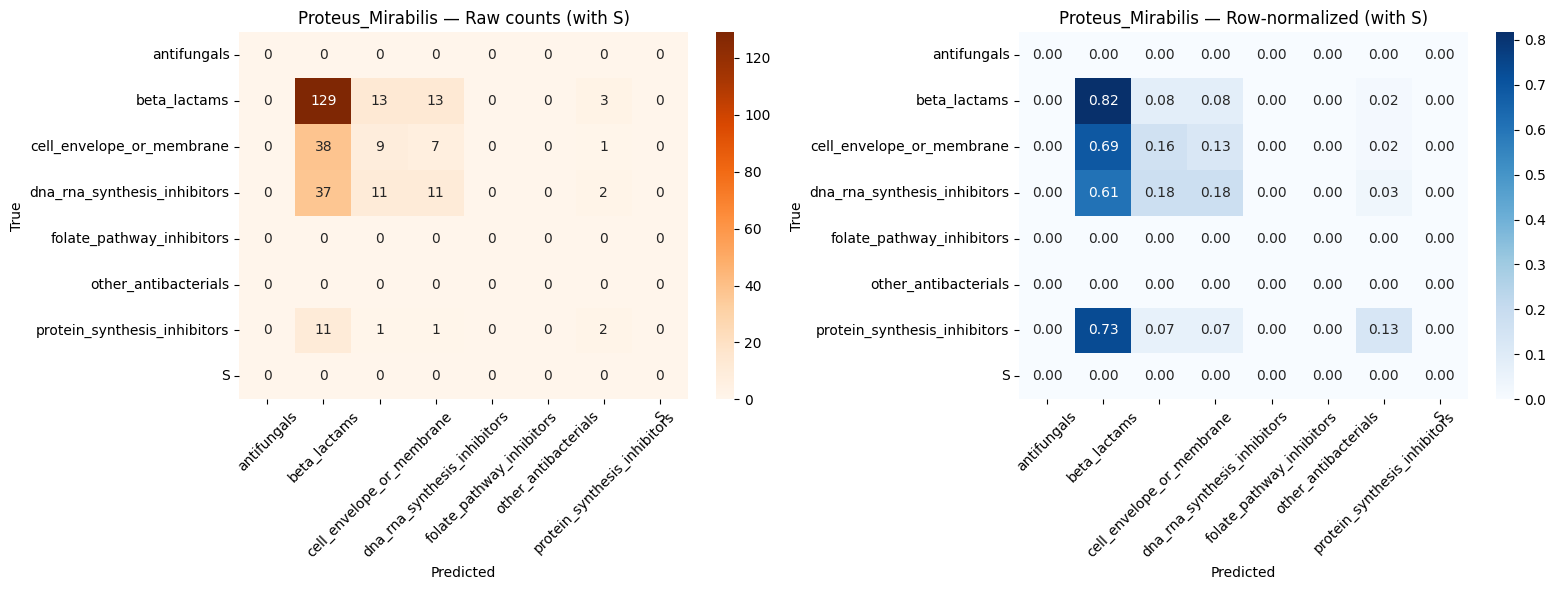


===== Escherichia_Coli =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


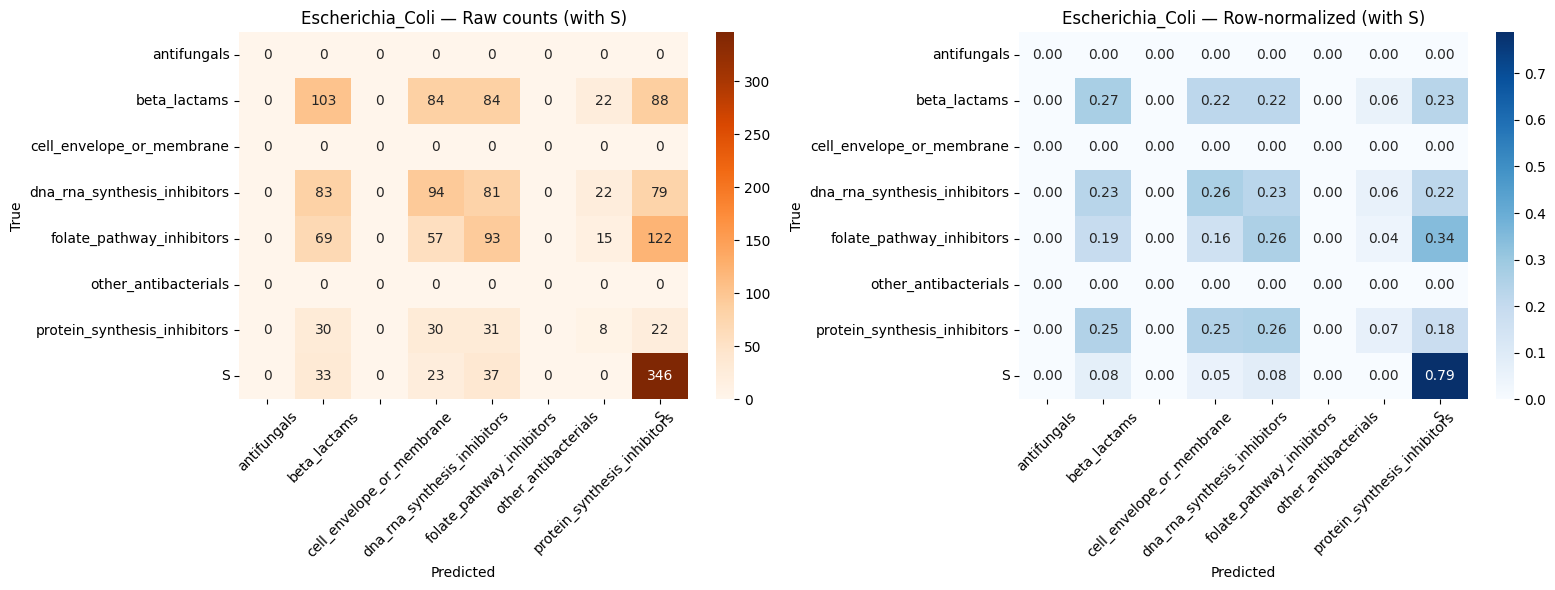


===== Klebsiella_Pneumoniae =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


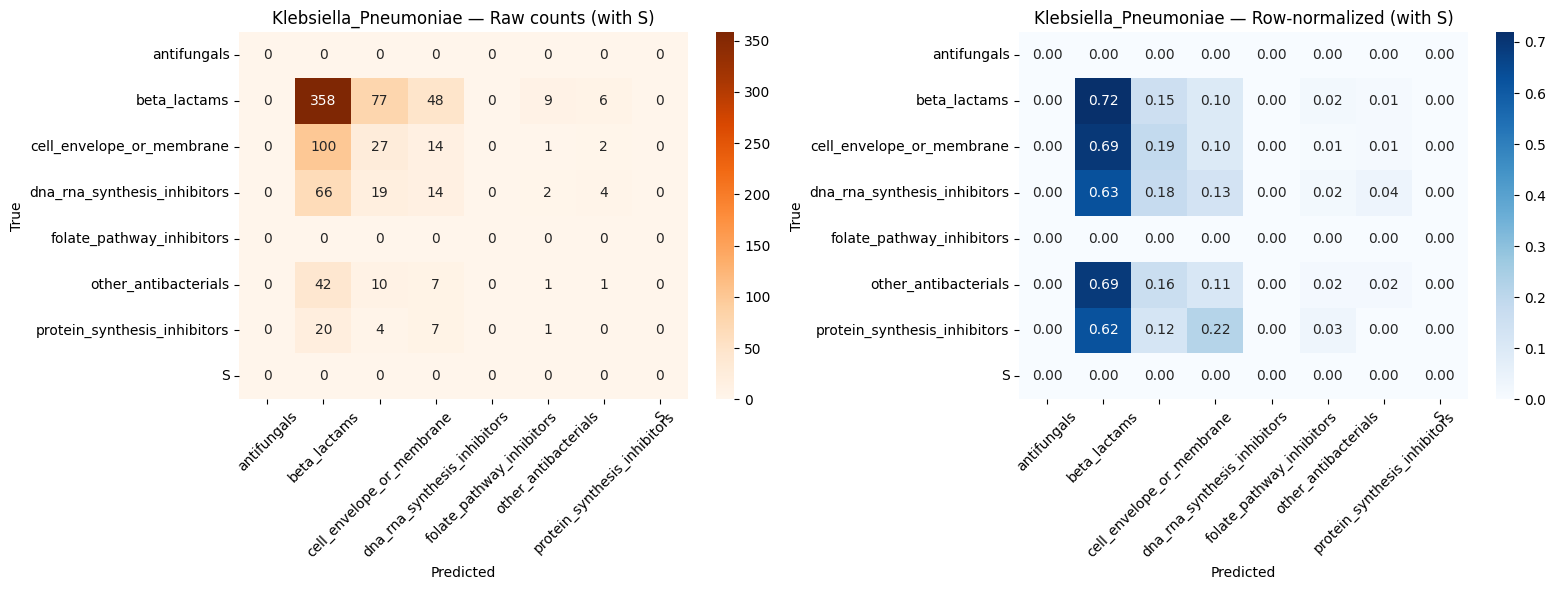


===== Staphylococcus_Epidermidis =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


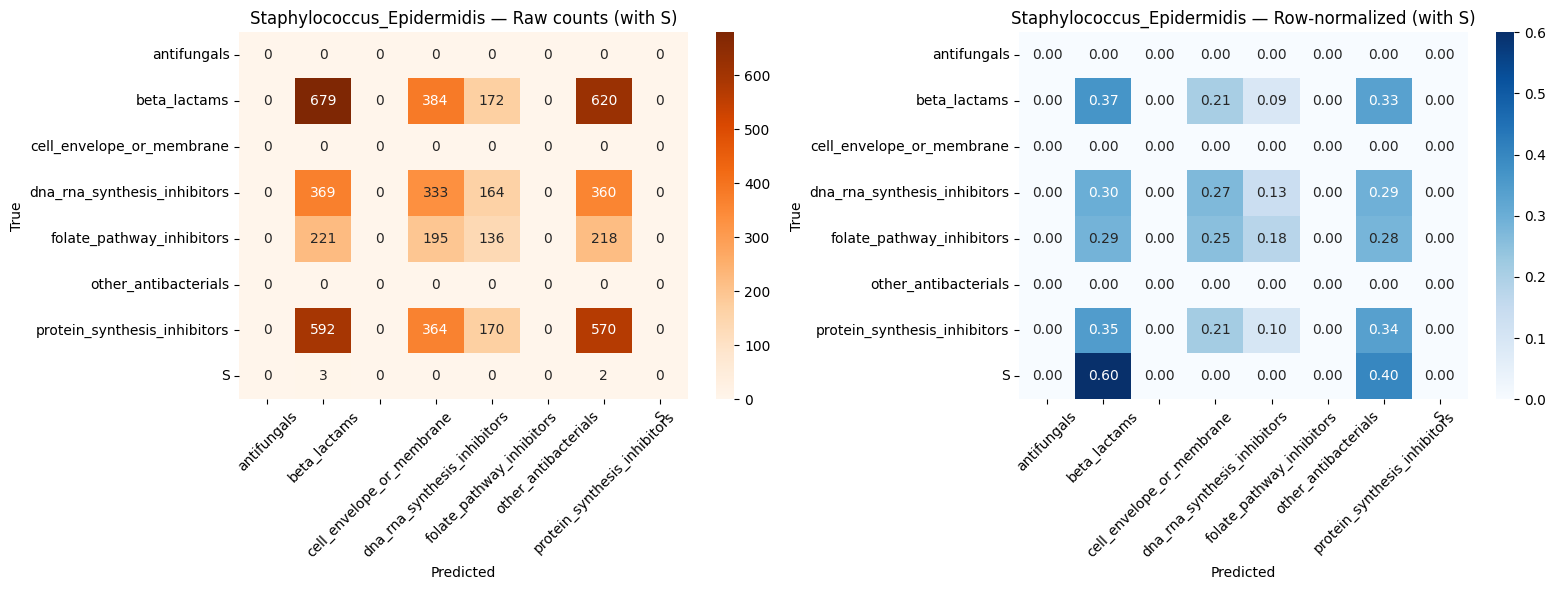


===== Enterococcus_Faecium =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


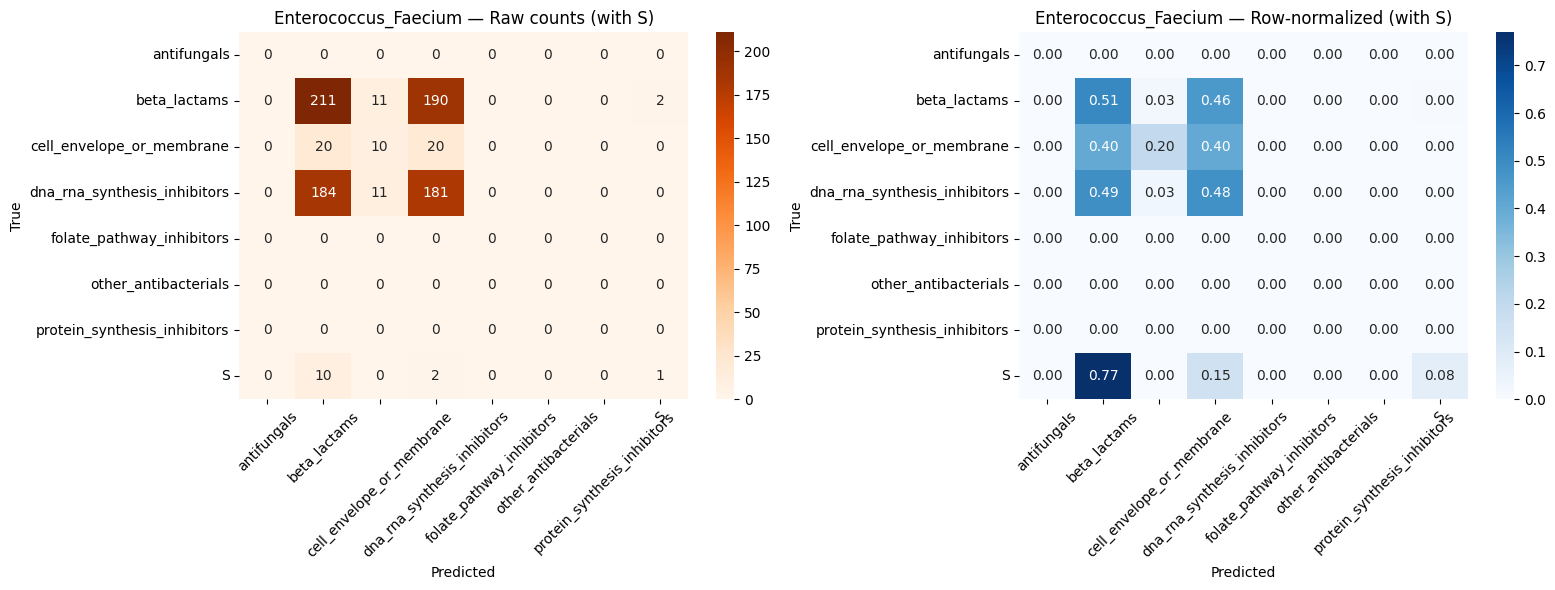


===== Pseudomonas_Aeruginosa =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


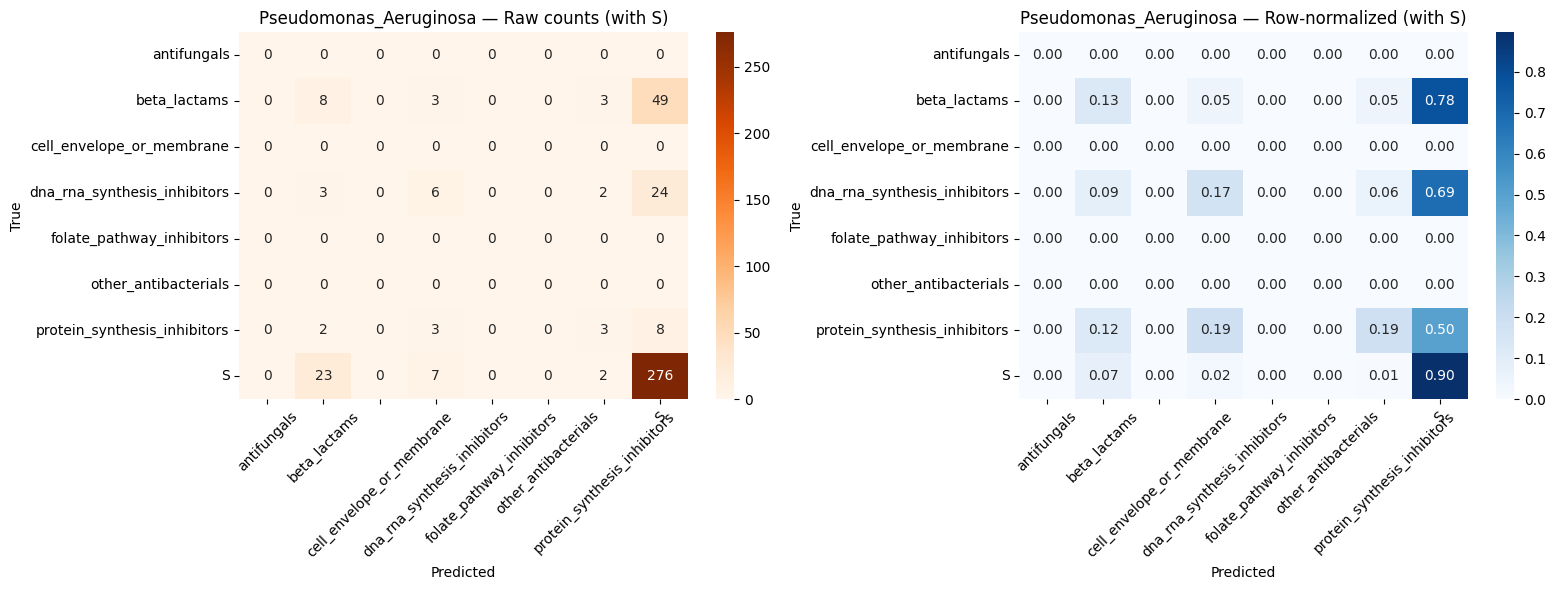


===== Staphylococcus_Aureus =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


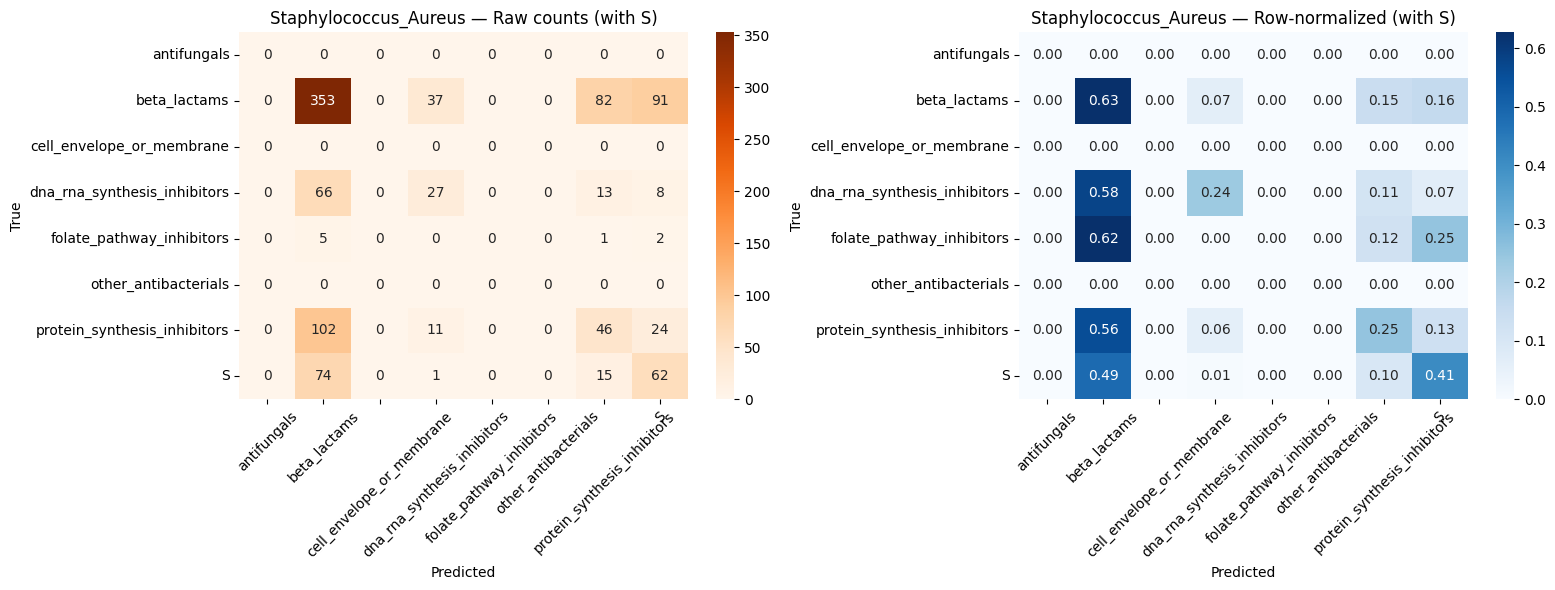

In [48]:
for species in species_list:
    try:
        run_family_confusion_all_with_S(species)
    except Exception as e:
        print(f" Error en {species}: {e}")


===== Staphylococcus_Lugdunensis =====
 Error en Staphylococcus_Lugdunensis: Faltan archivos en Staphylococcus_Lugdunensis

===== Staphylococcus_Haemolyticus =====
 Error en Staphylococcus_Haemolyticus: Faltan archivos en Staphylococcus_Haemolyticus

===== Haemophilus_Influenzae =====
 Error en Haemophilus_Influenzae: Faltan archivos en Haemophilus_Influenzae

===== Campylobacter_Jejuni =====
 Error en Campylobacter_Jejuni: Faltan archivos en Campylobacter_Jejuni

===== Serratia_Marcescens =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


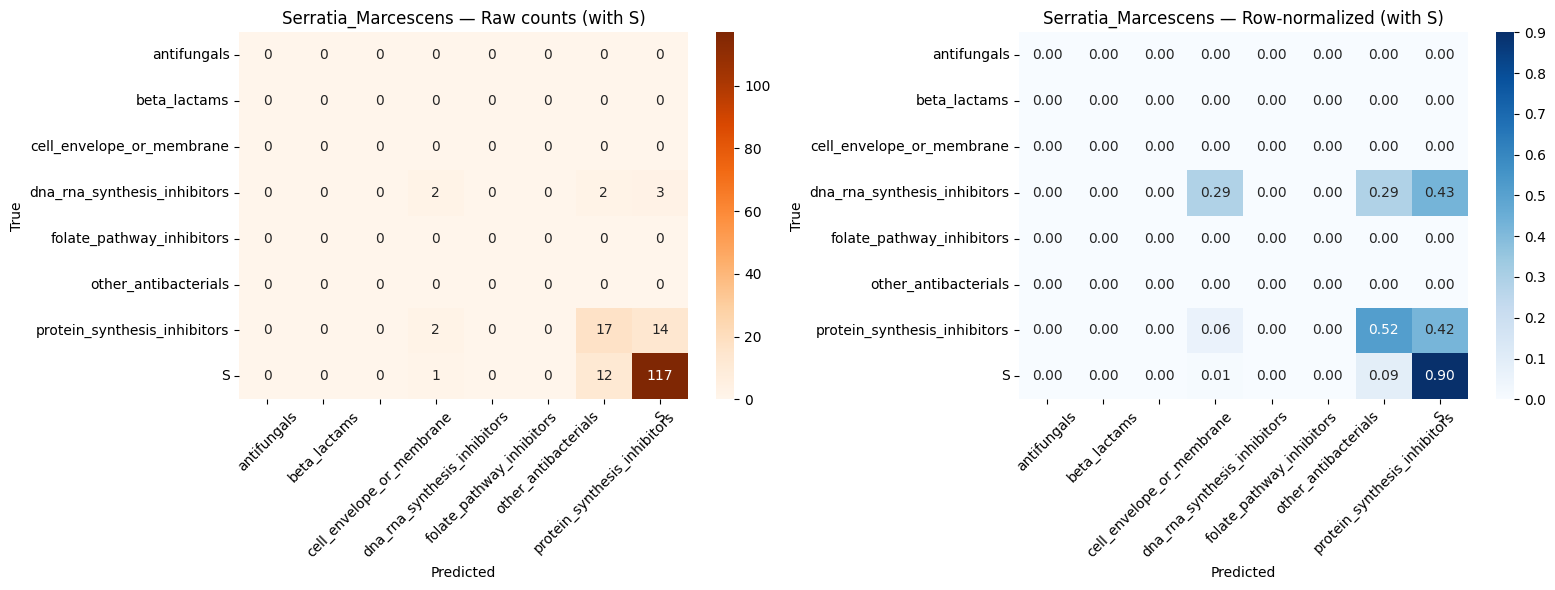


===== Staphylococcus_Capitis =====
 Error en Staphylococcus_Capitis: Faltan archivos en Staphylococcus_Capitis

===== Klebsiella_Variicola =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


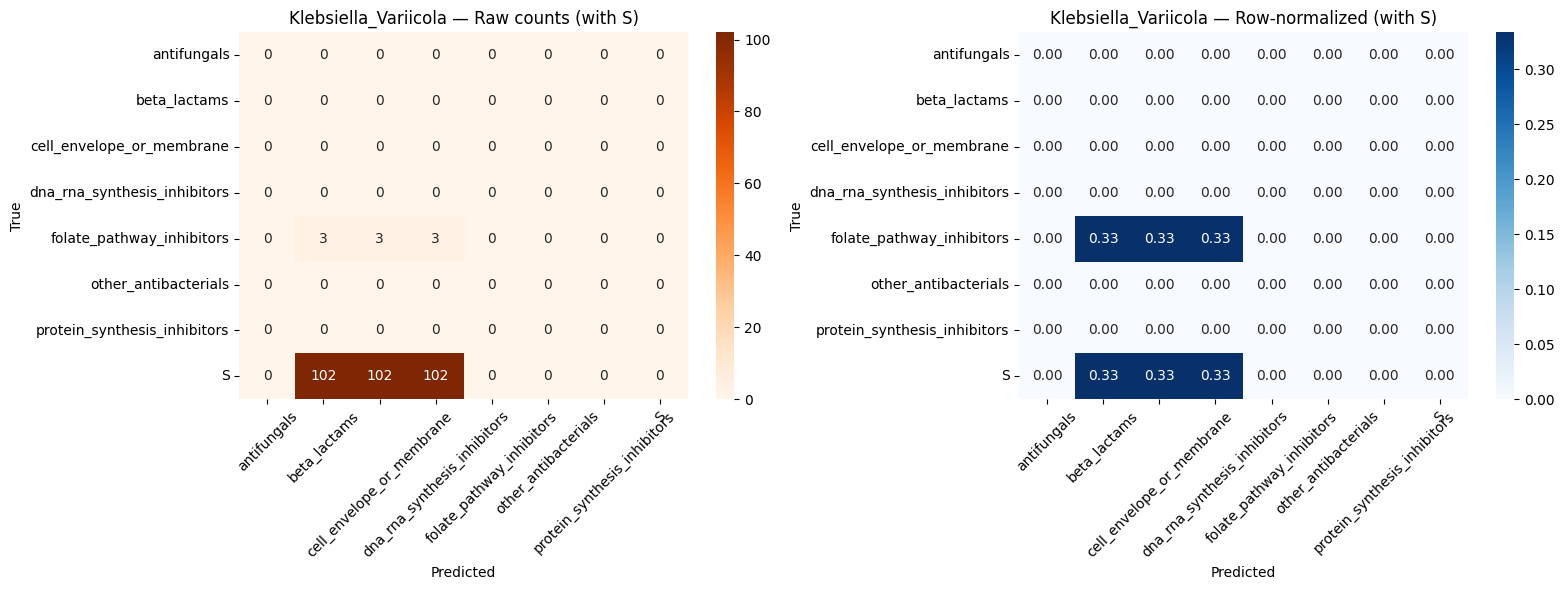


===== Enterobacter_Cloacae =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


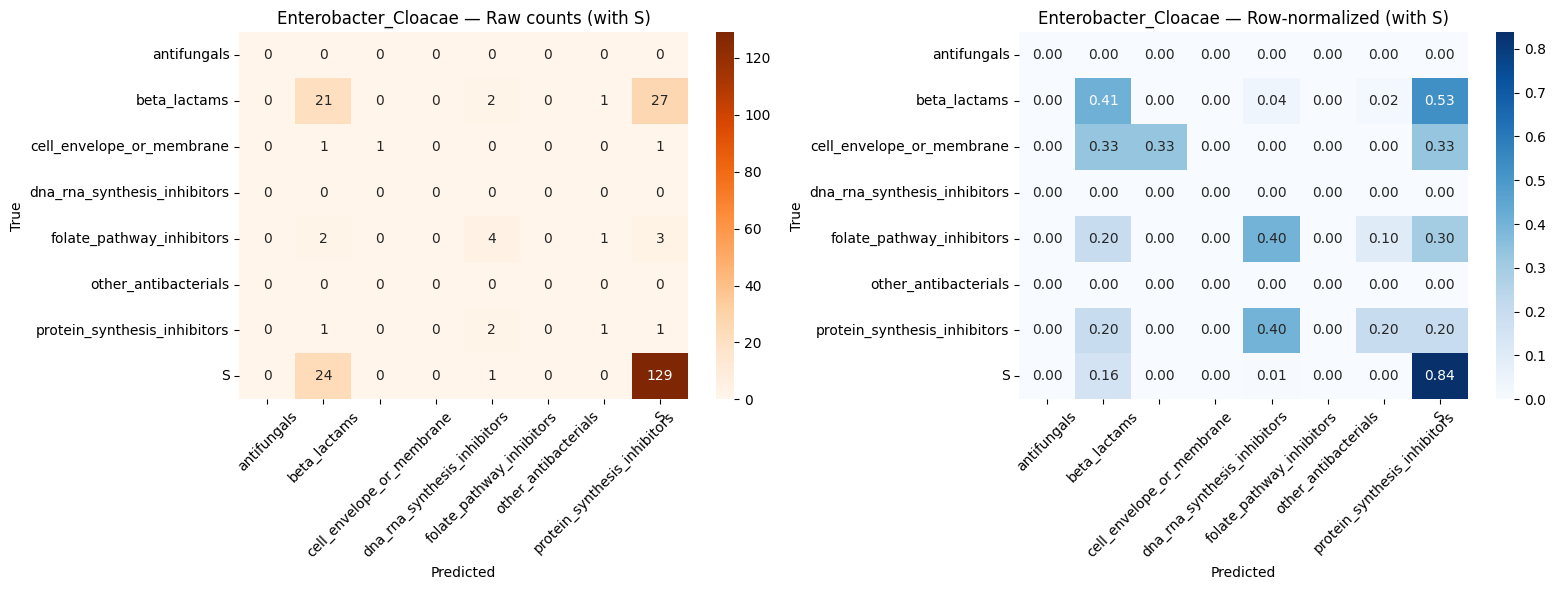


===== Proteus_Vulgaris =====
 Error en Proteus_Vulgaris: Faltan archivos en Proteus_Vulgaris

===== Citrobacter_Freundii =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


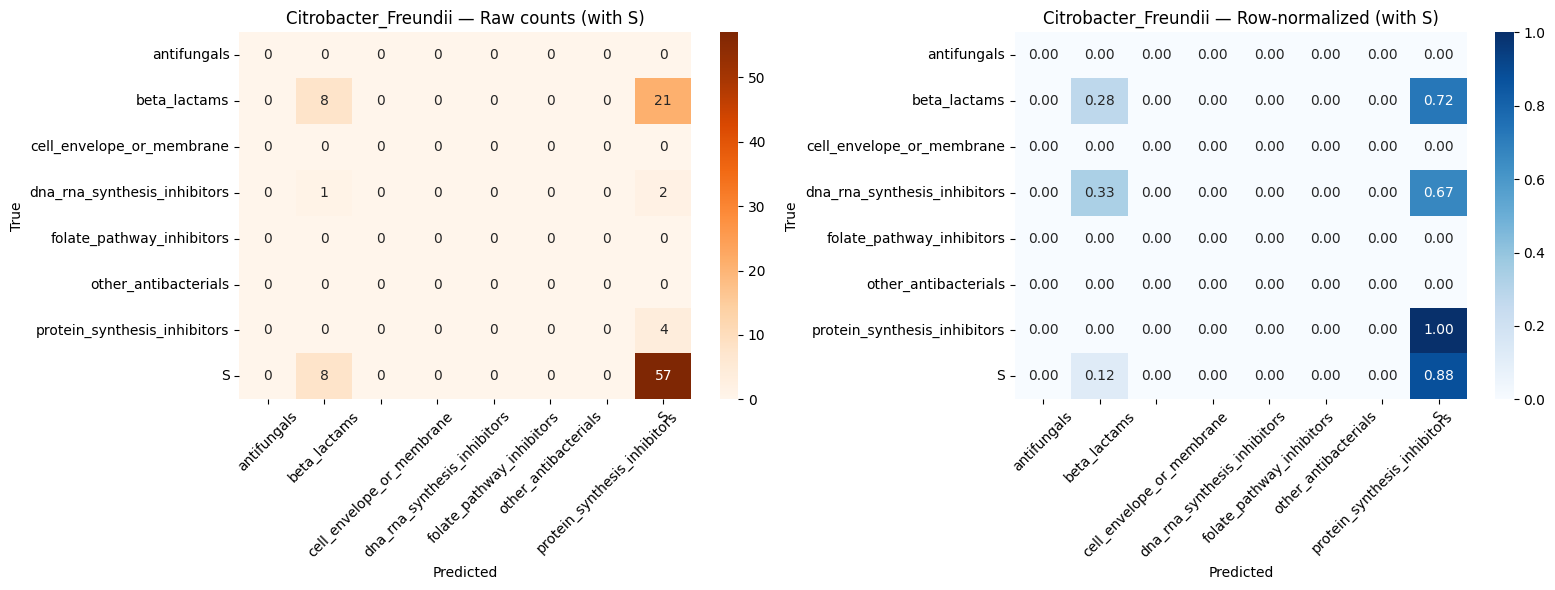


===== Streptococcus_Pneumoniae =====
 Error en Streptococcus_Pneumoniae: Faltan archivos en Streptococcus_Pneumoniae

===== Stenotrophomonas_Maltophilia =====
 Error en Stenotrophomonas_Maltophilia: Faltan archivos en Stenotrophomonas_Maltophilia

===== Morganella_Morganii =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


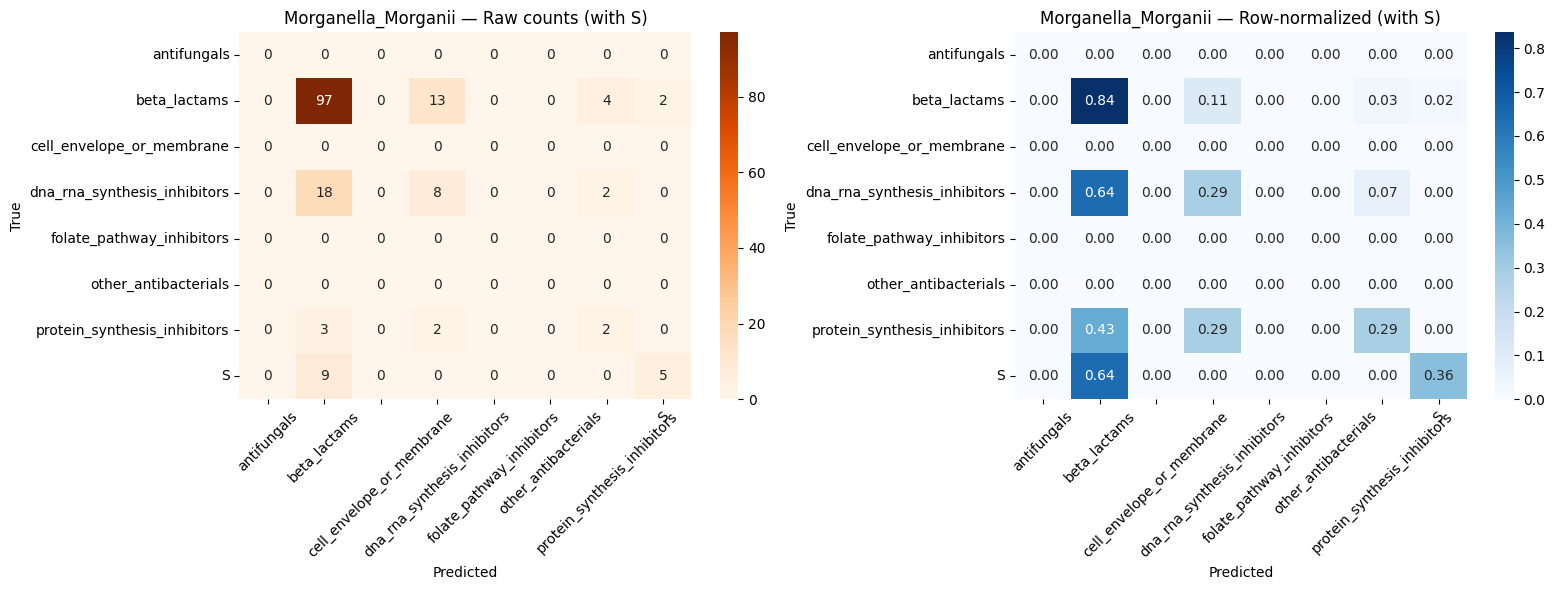


===== Klebsiella_Oxytoca =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


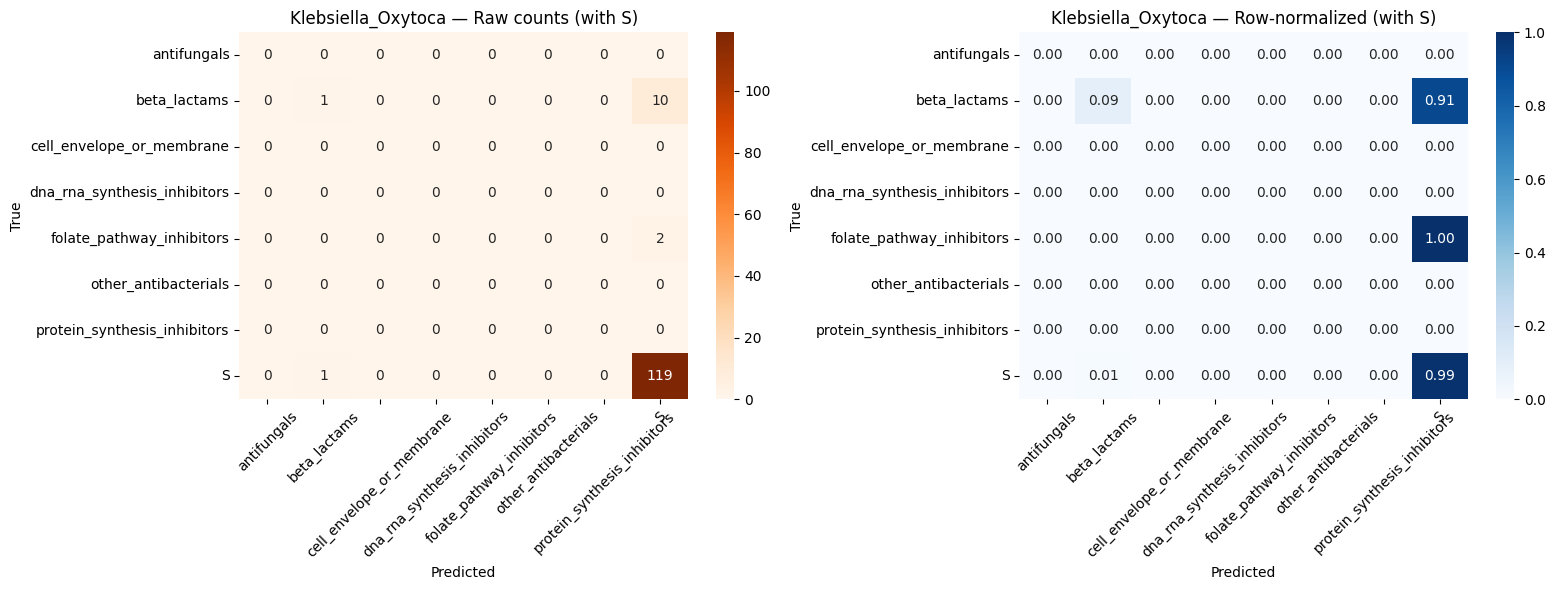


===== Citrobacter_Koseri =====


/tmp/ipykernel_18232/2360590559.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)


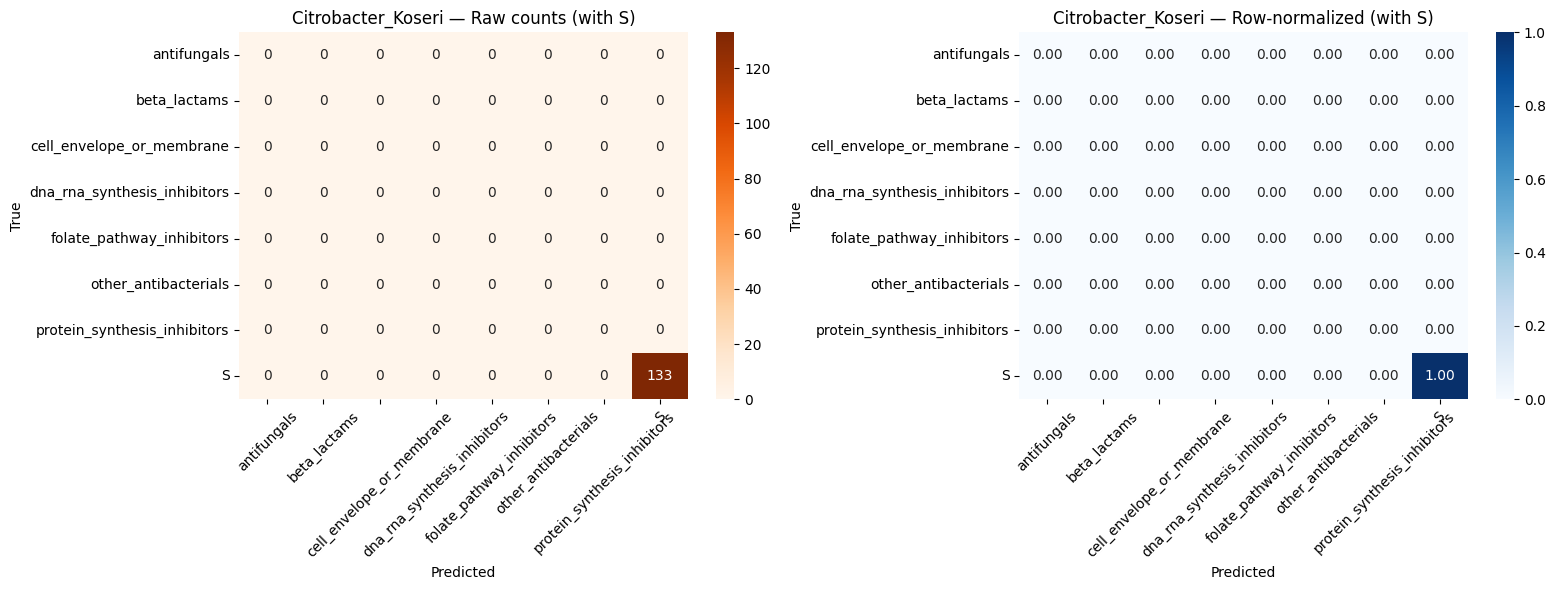


===== Staphylococcus_Hominis =====
 Error en Staphylococcus_Hominis: Faltan archivos en Staphylococcus_Hominis

===== Candida_Albicans =====
 Error en Candida_Albicans: Faltan archivos en Candida_Albicans


In [58]:
RUN_DIRS = [
    BASE_DIR / "benchmark_mlp_20260314_200946",
    BASE_DIR / "benchmark_mlp_20260316_112641",
]
RUN_DIR = BASE_DIR / "benchmark_mlp_20260314_200946"

species_list = [d.name for d in RUN_DIR.iterdir() if d.is_dir()]
for species in species_list:
    try:
        run_family_confusion_all_with_S(species)
    except Exception as e:
        print(f" Error en {species}: {e}")